In [1]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== CASE STUDY 4 IMPROVED: DỰ BÁO THỜI TIẾT 7 NGÀY VỚI CẢI TIẾN ====
# Cell 1: Import thư viện và thiết lập
# CẢI TIẾN: Dự báo 7 ngày chính xác hơn với model architecture tốt hơn

import os, re, math, warnings
import numpy as np
import pandas as pd
from datetime import timedelta
warnings.filterwarnings("ignore")

# Matplotlib cho visualization
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'  # Hỗ trợ tiếng Việt

# TensorFlow cho RNN/LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_OK = True
except Exception as e:
    TF_OK = False
    TF_ERR = e

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set random seeds
np.random.seed(42)
if TF_OK:
    tf.random.set_seed(42)

print("✓ Đã import tất cả thư viện cần thiết")
if TF_OK:
    print(f"✓ TensorFlow version: {tf.__version__}")
else:
    print(f"⚠️ TensorFlow chưa sẵn sàng: {TF_ERR}")

print("\n" + "="*60)
print("HƯỚNG DẪN CHẠY")
print("="*60)
print("""
📌 NẾU ĐÃ CHẠY CÁC CELL TRƯỚC ĐÓ:
   - Bạn chỉ cần chạy lại từ Cell 2 (Load data) trở đi
   - Không cần chạy lại Cell 0 và Cell 1
   
📌 NẾU CHẠY LẦN ĐẦU:
   - Chạy tuần tự từ Cell 0 đến hết
   
📌 LƯU Ý:
   - Code sẽ tự động phát hiện TẤT CẢ tỉnh/thành có trong dữ liệu
   - TARGET_CITIES = None → lấy tất cả tỉnh/thành
   - Thời gian train sẽ tăng theo số lượng tỉnh/thành
""")


✓ Đã import tất cả thư viện cần thiết
✓ TensorFlow version: 2.20.0

HƯỚNG DẪN CHẠY

📌 NẾU ĐÃ CHẠY CÁC CELL TRƯỚC ĐÓ:
   - Bạn chỉ cần chạy lại từ Cell 2 (Load data) trở đi
   - Không cần chạy lại Cell 0 và Cell 1

📌 NẾU CHẠY LẦN ĐẦU:
   - Chạy tuần tự từ Cell 0 đến hết

📌 LƯU Ý:
   - Code sẽ tự động phát hiện TẤT CẢ tỉnh/thành có trong dữ liệu
   - TARGET_CITIES = None → lấy tất cả tỉnh/thành
   - Thời gian train sẽ tăng theo số lượng tỉnh/thành



In [2]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 2: Định nghĩa hàm chuẩn hóa và load data ====

# Schema chuẩn
CANON_COLS = ["date","city","tavg","tmin","tmax","rain_mm","humidity","wind_kmh"]

# Mapping tên cột
ALIASES = {
    "date": ["date","ngay","day","time","timestamp"],
    "city": ["city","location","province","station","municipality","place","location.name","location_name"],
    "tavg": ["tavg","temp","temperature","avg_temp","temp_avg","nhietdo_tb","day.avgtemp_c","avgtemp_c","avg_temp_c"],
    "tmin": ["tmin","min_temp","temp_min","nhietdo_min","t_min","day.mintemp_c","mintemp_c","min","min_temp_c"],
    "tmax": ["tmax","max_temp","temp_max","nhietdo_max","t_max","day.maxtemp_c","maxtemp_c","max","max_temp_c"],
    "rain_mm": ["rain_mm","rain","precip","precipitation","rainfall","rainfall_mm","mm_rain","day.totalprecip_mm","totalprecip_mm"],
    "humidity": ["humidity","humid","doam","rh","rel_humidity","day.avghumidity","avghumidity","humidi"],
    "wind_kmh": ["wind_kmh","wind","wind_speed","wind_speed_kmh","gio_km_h","gio","wind_ms","day.maxwind_kph","maxwind_kph","wind"]
}

# 63 TỈNH/THÀNH CHÍNH CỦA VIỆT NAM
VIETNAM_63_PROVINCES = [
    "An Giang", "Bà Rịa-Vũng Tàu", "Bạc Liêu", "Bắc Giang", "Bắc Kạn", "Bắc Ninh",
    "Bến Tre", "Bình Định", "Bình Dương", "Bình Phước", "Bình Thuận", "Cà Mau",
    "Cao Bằng", "Cần Thơ", "Đà Nẵng", "Đắk Lắk", "Đắk Nông", "Điện Biên",
    "Đồng Nai", "Đồng Tháp", "Gia Lai", "Hà Giang", "Hà Nam", "Hà Nội",
    "Hà Tĩnh", "Hải Dương", "Hải Phòng", "Hậu Giang", "Hòa Bình", "Hưng Yên",
    "Khánh Hòa", "Kiên Giang", "Kon Tum", "Lai Châu", "Lâm Đồng", "Lạng Sơn",
    "Lào Cai", "Long An", "Nam Định", "Nghệ An", "Ninh Bình", "Ninh Thuận",
    "Phú Thọ", "Phú Yên", "Quảng Bình", "Quảng Nam", "Quảng Ngãi", "Quảng Ninh",
    "Quảng Trị", "Sóc Trăng", "Sơn La", "Tây Ninh", "Thái Bình", "Thái Nguyên",
    "Thanh Hóa", "Thừa Thiên-Huế", "Tiền Giang", "Trà Vinh", "Tuyên Quang",
    "Vĩnh Long", "Vĩnh Phúc", "Yên Bái", "Ho Chi Minh City"
]

# MAPPING: Chuẩn hóa các thành phố nhỏ về 63 tỉnh/thành chính
# Ví dụ: Uong Bi, Cam Pha, Hong Gai → Quảng Ninh
CITY_TO_PROVINCE_MAPPING = {
    # Quảng Ninh
    "Uong Bi": "Quảng Ninh", "uong bi": "Quảng Ninh", "uongbi": "Quảng Ninh",
    "Cam Pha": "Quảng Ninh", "cam pha": "Quảng Ninh", "campa": "Quảng Ninh",
    "Hong Gai": "Quảng Ninh", "hong gai": "Quảng Ninh", "honggai": "Quảng Ninh",
    "Ha Long": "Quảng Ninh", "ha long": "Quảng Ninh", "halong": "Quảng Ninh",
    
    # Đồng Nai
    "Bien Hoa": "Đồng Nai", "bien hoa": "Đồng Nai", "bienhoa": "Đồng Nai",
    
    # An Giang
    "Long Xuyen": "An Giang", "long xuyen": "An Giang", "longxuyen": "An Giang",
    "Chau Doc": "An Giang", "chau doc": "An Giang", "chaudoc": "An Giang",
    
    # Tiền Giang
    "My Tho": "Tiền Giang", "my tho": "Tiền Giang", "mytho": "Tiền Giang",
    "Tan An": "Long An", "tan an": "Long An", "tanan": "Long An",
    
    # Bà Rịa-Vũng Tàu
    "Vung Tau": "Bà Rịa-Vũng Tàu", "vung tau": "Bà Rịa-Vũng Tàu", "vungtau": "Bà Rịa-Vũng Tàu",
    
    # Khánh Hòa
    "Nha Trang": "Khánh Hòa", "nha trang": "Khánh Hòa", "nhatrang": "Khánh Hòa",
    "Cam Ranh": "Khánh Hòa", "cam ranh": "Khánh Hòa", "camranh": "Khánh Hòa",
    
    # Bình Định
    "Qui Nhon": "Bình Định", "qui nhon": "Bình Định", "quinhon": "Bình Định",
    
    # Quảng Nam
    "Tam Ky": "Quảng Nam", "tam ky": "Quảng Nam", "tamky": "Quảng Nam",
    
    # Quảng Ngãi
    "Quang Ngai": "Quảng Ngãi", "quang ngai": "Quảng Ngãi",
    
    # Phú Yên
    "Tuy Hoa": "Phú Yên", "tuy hoa": "Phú Yên", "tuyhoa": "Phú Yên",
    
    # Ninh Thuận
    "Phan Rang": "Ninh Thuận", "phan rang": "Ninh Thuận", "phanrang": "Ninh Thuận",
    
    # Bình Thuận
    "Phan Thiet": "Bình Thuận", "phan thiet": "Bình Thuận", "phanthiet": "Bình Thuận",
    
    # Kiên Giang
    "Rach Gia": "Kiên Giang", "rach gia": "Kiên Giang", "rachgia": "Kiên Giang",
    
    # Cà Mau
    "Ca Mau": "Cà Mau", "ca mau": "Cà Mau", "camau": "Cà Mau",
    
    # Bạc Liêu
    "Bac Lieu": "Bạc Liêu", "bac lieu": "Bạc Liêu", "baclieu": "Bạc Liêu",
    
    # Sóc Trăng
    "Soc Trang": "Sóc Trăng", "soc trang": "Sóc Trăng", "soctrang": "Sóc Trăng",
    
    # Trà Vinh
    "Tra Vinh": "Trà Vinh", "tra vinh": "Trà Vinh", "travinh": "Trà Vinh",
    
    # Vĩnh Long
    "Vinh Long": "Vĩnh Long", "vinh long": "Vĩnh Long", "vinhlong": "Vĩnh Long",
    
    # Đồng Tháp
    "Dong Thap": "Đồng Tháp", "dong thap": "Đồng Tháp", "dongthap": "Đồng Tháp",
    
    # Thừa Thiên-Huế
    "Hue": "Thừa Thiên-Huế", "hue": "Thừa Thiên-Huế",
    "Thua Thien-Hue": "Thừa Thiên-Huế", "thua thien-hue": "Thừa Thiên-Huế",
    
    # Quảng Trị
    "Quang Tri": "Quảng Trị", "quang tri": "Quảng Trị", "quangtri": "Quảng Trị",
    
    # Quảng Bình
    "Quang Binh": "Quảng Bình", "quang binh": "Quảng Bình", "quangbinh": "Quảng Bình",
    
    # Hà Tĩnh
    "Ha Tinh": "Hà Tĩnh", "ha tinh": "Hà Tĩnh", "hatinh": "Hà Tĩnh",
    
    # Nghệ An
    "Nghe An": "Nghệ An", "nghe an": "Nghệ An", "nghean": "Nghệ An",
    "Vinh": "Nghệ An", "vinh": "Nghệ An",
    
    # Thanh Hóa
    "Thanh Hoa": "Thanh Hóa", "thanh hoa": "Thanh Hóa", "thanhhoa": "Thanh Hóa",
    
    # Phú Thọ
    "Phu Tho": "Phú Thọ", "phu tho": "Phú Thọ", "phutho": "Phú Thọ",
    "Viet Tri": "Phú Thọ", "viet tri": "Phú Thọ", "viettri": "Phú Thọ",
    
    # Lâm Đồng
    "Da Lat": "Lâm Đồng", "da lat": "Lâm Đồng", "dalat": "Lâm Đồng",
    
    # Đắk Lắk
    "Buon Me Thuot": "Đắk Lắk", "buon me thuot": "Đắk Lắk", "buonmethuot": "Đắk Lắk",
    
    # Gia Lai
    "Gia Lai": "Gia Lai", "gia lai": "Gia Lai", "gialai": "Gia Lai",
    "Play Cu": "Gia Lai", "play cu": "Gia Lai", "playcu": "Gia Lai",
    
    # Cần Thơ
    "Can Tho": "Cần Thơ", "can tho": "Cần Thơ", "cantho": "Cần Thơ",
    
    # Hà Nội
    "Ha Noi": "Hà Nội", "ha noi": "Hà Nội", "hanoi": "Hà Nội", "hn": "Hà Nội",
    
    # TP. Hồ Chí Minh
    "Ho Chi Minh City": "Ho Chi Minh City", "ho chi minh": "Ho Chi Minh City",
    "tp.hcm": "Ho Chi Minh City", "tphcm": "Ho Chi Minh City",
    "tp ho chi minh": "Ho Chi Minh City", "ho chi minh city": "Ho Chi Minh City",
    "hcm": "Ho Chi Minh City", "TP. Hồ Chí Minh": "Ho Chi Minh City",
    
    # Đà Nẵng
    "Da Nang": "Đà Nẵng", "da nang": "Đà Nẵng", "danang": "Đà Nẵng",
    
    # Hải Phòng
    "Hai Phong": "Hải Phòng", "hai phong": "Hải Phòng", "haiphong": "Hải Phòng",
    
    # Các tỉnh khác giữ nguyên tên
    "An Giang": "An Giang", "Ba Ria-Vung Tau": "Bà Rịa-Vũng Tàu",
    "Bac Lieu": "Bạc Liêu", "Bac Giang": "Bắc Giang", "Bac Kan": "Bắc Kạn",
    "Bac Ninh": "Bắc Ninh", "Ben Tre": "Bến Tre", "Binh Dinh": "Bình Định",
    "Binh Duong": "Bình Dương", "Binh Phuoc": "Bình Phước", "Binh Thuan": "Bình Thuận",
    "Cao Bang": "Cao Bằng", "Dak Lak": "Đắk Lắk", "Dak Nong": "Đắk Nông",
    "Dien Bien": "Điện Biên", "Dong Nai": "Đồng Nai", "Dong Thap": "Đồng Tháp",
    "Ha Giang": "Hà Giang", "Ha Nam": "Hà Nam", "Ha Tinh": "Hà Tĩnh",
    "Hai Duong": "Hải Dương", "Hau Giang": "Hậu Giang", "Hoa Binh": "Hòa Bình",
    "Hung Yen": "Hưng Yên", "Khanh Hoa": "Khánh Hòa", "Kien Giang": "Kiên Giang",
    "Kon Tum": "Kon Tum", "Lai Chau": "Lai Châu", "Lam Dong": "Lâm Đồng",
    "Lang Son": "Lạng Sơn", "Lao Cai": "Lào Cai", "Long An": "Long An",
    "Nam Dinh": "Nam Định", "Ninh Binh": "Ninh Bình", "Ninh Thuan": "Ninh Thuận",
    "Phu Yen": "Phú Yên", "Quang Nam": "Quảng Nam", "Quang Ninh": "Quảng Ninh",
    "Soc Trang": "Sóc Trăng", "Son La": "Sơn La", "Tay Ninh": "Tây Ninh",
    "Thai Binh": "Thái Bình", "Thai Nguyen": "Thái Nguyên", "Tien Giang": "Tiền Giang",
    "Tuyen Quang": "Tuyên Quang", "Vinh Phuc": "Vĩnh Phúc", "Yen Bai": "Yên Bái"
}

# Chuẩn hóa tên thành phố - mở rộng cho tất cả tỉnh/thành
CITY_SYNONYMS = {
    "ha noi": "Ha Noi", "hanoi": "Ha Noi", "hn": "Ha Noi",
    "ho chi minh": "Ho Chi Minh City", "ho-chi-minh": "Ho Chi Minh City",
    "tp.hcm": "Ho Chi Minh City", "tphcm": "Ho Chi Minh City",
    "tp ho chi minh": "Ho Chi Minh City", "ho chi minh city": "Ho Chi Minh City",
    "hcm": "Ho Chi Minh City",
    # Thêm các tỉnh/thành khác nếu cần
    "da nang": "Da Nang", "danang": "Da Nang",
    "can tho": "Can Tho", "cantho": "Can Tho",
    "hai phong": "Hai Phong", "haiphong": "Hai Phong",
    "an giang": "An Giang", "angiang": "An Giang",
    "ba ria-vung tau": "Ba Ria-Vung Tau", "baria-vungtau": "Ba Ria-Vung Tau",
    "bac lieu": "Bac Lieu", "baclieu": "Bac Lieu",
    "bac kan": "Bac Kan", "backan": "Bac Kan",
    "bac giang": "Bac Giang", "bacgiang": "Bac Giang",
    "bac ninh": "Bac Ninh", "bacninh": "Bac Ninh",
    "ben tre": "Ben Tre", "bentre": "Ben Tre",
    "binh dinh": "Binh Dinh", "binhdinh": "Binh Dinh",
    "binh duong": "Binh Duong", "binhduong": "Binh Duong",
    "binh phuoc": "Binh Phuoc", "binhphuoc": "Binh Phuoc",
    "binh thuan": "Binh Thuan", "binhthuan": "Binh Thuan",
    "ca mau": "Ca Mau", "camau": "Ca Mau",
    "cao bang": "Cao Bang", "caobang": "Cao Bang",
    "dak lak": "Dak Lak", "daklak": "Dak Lak",
    "dak nong": "Dak Nong", "daknong": "Dak Nong",
    "dien bien": "Dien Bien", "dienbien": "Dien Bien",
    "dong nai": "Dong Nai", "dongnai": "Dong Nai",
    "dong thap": "Dong Thap", "dongthap": "Dong Thap",
    "gia lai": "Gia Lai", "gialai": "Gia Lai",
    "ha giang": "Ha Giang", "hagiang": "Ha Giang",
    "ha nam": "Ha Nam", "hanam": "Ha Nam",
    "ha tinh": "Ha Tinh", "hatinh": "Ha Tinh",
    "hai duong": "Hai Duong", "haiduong": "Hai Duong",
    "hau giang": "Hau Giang", "haugiang": "Hau Giang",
    "hoa binh": "Hoa Binh", "hoabinh": "Hoa Binh",
    "hung yen": "Hung Yen", "hungyen": "Hung Yen",
    "khanh hoa": "Khanh Hoa", "khanhhoa": "Khanh Hoa",
    "kien giang": "Kien Giang", "kiengiang": "Kien Giang",
    "kon tum": "Kon Tum", "kontum": "Kon Tum",
    "lai chau": "Lai Chau", "laichau": "Lai Chau",
    "lam dong": "Lam Dong", "lamdong": "Lam Dong",
    "lang son": "Lang Son", "langson": "Lang Son",
    "lao cai": "Lao Cai", "laocai": "Lao Cai",
    "long an": "Long An", "longan": "Long An",
    "nam dinh": "Nam Dinh", "namdinh": "Nam Dinh",
    "nghe an": "Nghe An", "nghean": "Nghe An",
    "ninh binh": "Ninh Binh", "ninhbinh": "Ninh Binh",
    "ninh thuan": "Ninh Thuan", "ninhthuan": "Ninh Thuan",
    "phu tho": "Phu Tho", "phutho": "Phu Tho",
    "phu yen": "Phu Yen", "phuyen": "Phu Yen",
    "quang binh": "Quang Binh", "quangbinh": "Quang Binh",
    "quang nam": "Quang Nam", "quangnam": "Quang Nam",
    "quang ngai": "Quang Ngai", "quangngai": "Quang Ngai",
    "quang ninh": "Quang Ninh", "quangninh": "Quang Ninh",
    "quang tri": "Quang Tri", "quangtri": "Quang Tri",
    "soc trang": "Soc Trang", "soctrang": "Soc Trang",
    "son la": "Son La", "sonla": "Son La",
    "tay ninh": "Tay Ninh", "tayninh": "Tay Ninh",
    "thai binh": "Thai Binh", "thaibinh": "Thai Binh",
    "thai nguyen": "Thai Nguyen", "thainguyen": "Thai Nguyen",
    "thanh hoa": "Thanh Hoa", "thanhhoa": "Thanh Hoa",
    "thua thien-hue": "Thua Thien-Hue", "thuathien-hue": "Thua Thien-Hue",
    "tien giang": "Tien Giang", "tiengiang": "Tien Giang",
    "tra vinh": "Tra Vinh", "travinh": "Tra Vinh",
    "tuyen quang": "Tuyen Quang", "tuyenquang": "Tuyen Quang",
    "vinh long": "Vinh Long", "vinhlong": "Vinh Long",
    "vinh phuc": "Vinh Phuc", "vinhphuc": "Vinh Phuc",
    "yen bai": "Yen Bai", "yenbai": "Yen Bai"
}

# Không giới hạn TARGET_CITIES - sẽ lấy tất cả tỉnh/thành có trong dữ liệu
TARGET_CITIES = None  # None = lấy tất cả

def normalize_colnames(df):
    df = df.copy()
    df.columns = [c.strip().lower().replace(" ","_") for c in df.columns]
    return df

def smart_parse_date(s):
    return pd.to_datetime(s, errors="coerce", infer_datetime_format=True)

def map_to_canonical_cols(df):
    col_map, used = {}, set()
    for canon, cands in ALIASES.items():
        for c in cands:
            if c in df.columns and c not in used:
                col_map[canon] = c
                used.add(c)
                break
    return col_map

def standardize_city(x):
    """Chuẩn hóa tên thành phố về tên chuẩn"""
    if pd.isna(x): return np.nan
    s = str(x).strip()
    s_lower = s.lower()
    s_lower = re.sub(r"\s+"," ",s_lower)
    
    # Thử tìm trong CITY_SYNONYMS trước
    if s_lower in CITY_SYNONYMS:
        return CITY_SYNONYMS[s_lower]
    
    # Thử tìm trong CITY_TO_PROVINCE_MAPPING
    if s in CITY_TO_PROVINCE_MAPPING:
        return CITY_TO_PROVINCE_MAPPING[s]
    if s_lower in CITY_TO_PROVINCE_MAPPING:
        return CITY_TO_PROVINCE_MAPPING[s_lower]
    
    # Nếu không tìm thấy, trả về tên gốc
    return s

def normalize_to_63_provinces(df):
    """
    CẢI TIẾN: Chuẩn hóa về 63 tỉnh/thành chính
    Gộp các thành phố nhỏ về tỉnh/thành chính
    Nếu có nhiều thành phố trong cùng tỉnh, lấy dữ liệu nhiều hơn
    """
    df = df.copy()
    
    # Áp dụng mapping để chuẩn hóa tên thành phố về 63 tỉnh/thành chính
    df["city"] = df["city"].map(standardize_city)
    
    # Gộp dữ liệu: nếu có nhiều thành phố cùng map về 1 tỉnh, gộp lại
    # Loại bỏ trùng lặp theo (city, date), giữ lại dữ liệu đầu tiên
    df_normalized = df.drop_duplicates(subset=["city", "date"], keep="first")
    
    # Chỉ giữ lại 63 tỉnh/thành chính
    df_normalized = df_normalized[df_normalized["city"].isin(VIETNAM_63_PROVINCES)].copy()
    
    # Nếu có nhiều dòng cho cùng (city, date), lấy trung bình
    df_normalized = df_normalized.groupby(["city", "date"], as_index=False).agg({
        "tavg": "mean",
        "tmin": "mean",
        "tmax": "mean",
        "rain_mm": "mean",
        "humidity": "mean",
        "wind_kmh": "mean"
    })
    
    # Sắp xếp lại theo city và date
    df_normalized = df_normalized.sort_values(["city", "date"]).reset_index(drop=True)
    
    return df_normalized

def load_and_harmonize(path):
    last_err = None
    for enc in [None, "utf-8", "utf-8-sig", "cp1258", "latin-1"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            break
        except Exception as e:
            last_err = e
            continue
    if 'df' not in locals():
        raise last_err
    
    df = normalize_colnames(df)
    col_map = map_to_canonical_cols(df)
    keep = {col_map[k]: k for k in col_map}
    df = df[list(keep.keys())].rename(columns=keep)

    if "date" in df:
        df["date"] = smart_parse_date(df["date"])
    if "city" in df:
        df["city"] = df["city"].map(standardize_city)

    # Chuyển đổi wind từ m/s sang km/h nếu cần
    if "wind_kmh" in df:
        m = df["wind_kmh"].median(skipna=True)
        if pd.notna(m) and m < 5:  # có thể là m/s
            df["wind_kmh"] = df["wind_kmh"] * 3.6

    # Chuyển đổi nhiệt độ từ Fahrenheit sang Celsius nếu cần (kiểm tra giá trị lớn)
    for temp_col in ["tavg", "tmin", "tmax"]:
        if temp_col in df:
            m = df[temp_col].median(skipna=True)
            if pd.notna(m) and m > 50:  # Nếu trung vị > 50, có thể là Fahrenheit
                df[temp_col] = (df[temp_col] - 32) * 5/9

    # Đảm bảo có đủ cột
    for c in CANON_COLS:
        if c not in df:
            df[c] = np.nan

    return df[CANON_COLS].dropna(subset=["date"]).sort_values(["city","date"])

print("✓ Đã định nghĩa các hàm chuẩn hóa và load data")


✓ Đã định nghĩa các hàm chuẩn hóa và load data


In [3]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 3: Load và xử lý 2 datasets chính từ Kaggle ====

# Đường dẫn đến 2 file CSV chính
# ✂️ Bỏ weather_1.csv vì dữ liệu không rõ ràng và không dùng cho train
paths = [
    r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy4\df_weather.csv",
    r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy4\weather.csv",
]

dfs = []
missing = []
for p in paths:
    if os.path.exists(p):
        try:
            dfs.append(load_and_harmonize(p))
            print(f"✓ Đã load: {os.path.basename(p)}")
        except Exception as e:
            print(f"⚠️ Lỗi khi load {p}: {e}")
    else:
        missing.append(p)

if missing:
    print(f"⚠️ Thiếu file: {missing}")

if not dfs:
    raise FileNotFoundError("Không đọc được CSV nào. Vui lòng kiểm tra đường dẫn.")

# Gộp tất cả datasets
df_all = pd.concat(dfs, ignore_index=True).drop_duplicates(subset=["city","date"])
df_all["city"] = df_all["city"].map(standardize_city)

# Loại bỏ các dòng có city là NaN hoặc rỗng
df_all = df_all[df_all["city"].notna()].copy()
df_all = df_all[df_all["city"].astype(str).str.strip() != ""].copy()

# CẢI TIẾN: Chuẩn hóa về 63 tỉnh/thành chính
print("\n" + "="*60)
print("CHUẨN HÓA VỀ 63 TỈNH/THÀNH CHÍNH")
print("="*60)
print(f"Trước khi chuẩn hóa: {df_all['city'].nunique()} tỉnh/thành")
print(f"Danh sách trước: {sorted(df_all['city'].unique())[:20]}...")

df_all = normalize_to_63_provinces(df_all)

print(f"\nSau khi chuẩn hóa: {df_all['city'].nunique()} tỉnh/thành")
print(f"Danh sách sau: {sorted(df_all['city'].unique())}")

# Kiểm tra số ngày dữ liệu cho mỗi tỉnh/thành
city_data_summary = df_all.groupby("city").agg({
    "date": ["min", "max", "count"]
}).round(0)
city_data_summary.columns = ["min_date", "max_date", "num_days"]
print("\n" + "="*60)
print("SỐ NGÀY DỮ LIỆU CHO MỖI TỈNH/THÀNH")
print("="*60)
print(city_data_summary.sort_values("num_days", ascending=False).head(20))

# KIỂM TRA CÁC TỈNH/THÀNH CÓ TRONG DỮ LIỆU
print("\n" + "="*60)
print("KIỂM TRA CÁC TỈNH/THÀNH CÓ TRONG DỮ LIỆU")
print("="*60)
unique_cities = df_all["city"].unique()
print(f"Các tỉnh/thành có trong dữ liệu: {sorted(unique_cities)}")
print(f"Tổng số: {len(unique_cities)} tỉnh/thành")

# Lọc theo TARGET_CITIES nếu được chỉ định, nếu không thì lấy tất cả
if TARGET_CITIES is not None:
    df_all = df_all[df_all["city"].isin(TARGET_CITIES)].copy()
    print(f"\n⚠️ LƯU Ý: Đang lọc theo TARGET_CITIES = {TARGET_CITIES}")
    print(f"   Chỉ các tỉnh/thành trong danh sách này mới được train.")
else:
    # Lấy tất cả các tỉnh/thành có trong dữ liệu
    print(f"\n✓ Đang xử lý TẤT CẢ các tỉnh/thành có trong dữ liệu")
    print(f"⚠️ LƯU Ý: Code sẽ chỉ train cho các tỉnh/thành có trong dữ liệu.")
    print(f"   Nếu dữ liệu chỉ có 2 thành phố, chỉ có 2 thành phố được train.")
    print(f"   Để có bản đồ đầy đủ, cần dữ liệu thời tiết cho nhiều tỉnh/thành hơn.")

# Gộp trùng ngày/city
df_all = (df_all.groupby(["city","date"], as_index=False)
          .agg({
              "tavg": "mean",
              "tmin": "mean",
              "tmax": "mean",
              "rain_mm": "mean",
              "humidity": "mean",
              "wind_kmh": "mean"
          }))

# Điền thiếu theo từng city
def impute_per_city(g):
    g = g.sort_values("date").copy()
    cols = ["tavg","tmin","tmax","rain_mm","humidity","wind_kmh"]
    g[cols] = g[cols].ffill().bfill()  # forward fill, backward fill
    for c in cols:
        if g[c].isna().any():
            g[c] = g[c].fillna(g[c].median())
    return g

df_all = df_all.groupby("city", group_keys=False).apply(impute_per_city)

# Nếu thiếu tavg nhưng có tmin/tmax → tính tavg
if df_all["tavg"].isna().any() and "tmin" in df_all and "tmax" in df_all:
    mask = df_all["tavg"].isna()
    df_all.loc[mask, "tavg"] = (df_all.loc[mask, "tmin"] + df_all.loc[mask, "tmax"]) / 2.0

print("\n" + "="*60)
print("TÓM TẮT DỮ LIỆU THEO THÀNH PHỐ")
print("="*60)
city_summary = df_all.groupby("city")["date"].agg(["min","max","count"])
print(city_summary)
print(f"\nTổng số dòng: {len(df_all)}")
print(f"Số tỉnh/thành: {df_all['city'].nunique()}")
print(f"\nDanh sách các tỉnh/thành:")
for city in sorted(df_all['city'].unique()):
    count = len(df_all[df_all['city'] == city])
    print(f"  - {city}: {count} ngày dữ liệu")


✓ Đã load: df_weather.csv
✓ Đã load: weather.csv

CHUẨN HÓA VỀ 63 TỈNH/THÀNH CHÍNH
Trước khi chuẩn hóa: 79 tỉnh/thành
Danh sách trước: ['An Giang', 'Bac Lieu', 'Ben Tre', 'Bà Rịa-Vũng Tàu', 'Bình Dương', 'Bình Phước', 'Bình Thuận', 'Bình Định', 'Bạc Liêu', 'Bắc Giang', 'Bắc Kạn', 'Bắc Ninh', 'Bến Tre', 'Ca Mau', 'Can Tho', 'Cao Bằng', 'Cà Mau', 'Cần Thơ', 'Gia Lai', 'Ha Noi']...

Sau khi chuẩn hóa: 63 tỉnh/thành
Danh sách sau: ['An Giang', 'Bà Rịa-Vũng Tàu', 'Bình Dương', 'Bình Phước', 'Bình Thuận', 'Bình Định', 'Bạc Liêu', 'Bắc Giang', 'Bắc Kạn', 'Bắc Ninh', 'Bến Tre', 'Cao Bằng', 'Cà Mau', 'Cần Thơ', 'Gia Lai', 'Ho Chi Minh City', 'Hà Giang', 'Hà Nam', 'Hà Nội', 'Hà Tĩnh', 'Hòa Bình', 'Hưng Yên', 'Hải Dương', 'Hải Phòng', 'Hậu Giang', 'Khánh Hòa', 'Kiên Giang', 'Kon Tum', 'Lai Châu', 'Long An', 'Lào Cai', 'Lâm Đồng', 'Lạng Sơn', 'Nam Định', 'Nghệ An', 'Ninh Bình', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên', 'Quảng Bình', 'Quảng Nam', 'Quảng Ngãi', 'Quảng Ninh', 'Quảng Trị', 'Sóc Trăng', 'Sơn

In [4]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 4: Tạo sequences và chuẩn hóa dữ liệu ====

FEATURES = ["tavg","tmin","tmax","rain_mm","humidity","wind_kmh"]
# CẢI TIẾN: CHỈ dự báo tavg (nhiệt độ trung bình)
TEMP_TARGETS = ["tavg"]  # CHỈ dự báo tavg
WINDOW, HORIZON = 30, 1  # 30 ngày để dự báo 1 ngày tiếp theo

def add_time_features(df):
    """CẢI TIẾN: Thêm features thời gian để cải thiện dự báo"""
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['day_of_year'] = df['date'].dt.dayofyear
    df['month'] = df['date'].dt.month
    df['day_of_month'] = df['date'].dt.day
    df['week_of_year'] = df['date'].dt.isocalendar().week
    # Chuẩn hóa về [0,1]
    df['day_of_year'] = df['day_of_year'] / 365.0
    df['month'] = df['month'] / 12.0
    df['day_of_month'] = df['day_of_month'] / 31.0
    df['week_of_year'] = df['week_of_year'] / 52.0
    return df

def choose_target(df):
    """CẢI TIẾN: CHỈ chọn target tavg (nhiệt độ trung bình)"""
    target = "tavg"
    if target in df.columns and df[target].notna().sum() >= 100:
        # Kiểm tra giá trị hợp lý (nhiệt độ Việt Nam: có thể từ 5-50°C)
        values = df[target].dropna()
        if len(values) > 0:
            median_val = values.median()
            min_val = values.min()
            max_val = values.max()
            # Nới lỏng điều kiện: cho phép nhiệt độ từ 5-50°C (bao gồm cả vùng núi và mùa đông)
            if 5 <= median_val <= 50:  # Đảm bảo là nhiệt độ, không phải mưa
                # Kiểm tra thêm: min và max cũng phải hợp lý
                if min_val >= -10 and max_val <= 55:  # Cho phép một số giá trị ngoại lai
                    return target
    return None

def build_sequences(X, y, window=30, horizon=1):
    """Tạo sequences từ dữ liệu time series"""
    seq_X, seq_y = [], []
    for i in range(window, len(X) - horizon + 1):
        seq_X.append(X[i-window:i, :])
        seq_y.append(y[i + horizon - 1])
    return np.array(seq_X, "float32"), np.array(seq_y, "float32")

def time_split(X, y, train_ratio=0.7, val_ratio=0.15):
    """Chia train/val/test theo thời gian"""
    n = len(X)
    i_tr = int(n * train_ratio)
    i_va = int(n * (train_ratio + val_ratio))
    return (X[:i_tr], y[:i_tr], 
            X[i_tr:i_va], y[i_tr:i_va], 
            X[i_va:], y[i_va:])

# Xử lý dữ liệu cho từng thành phố
CITY_DATA = {}
# CẢI TIẾN: Train cho TẤT CẢ 63 tỉnh/thành (hoặc các tỉnh có đủ dữ liệu)
all_cities = sorted(df_all['city'].unique().tolist())
print(f"\nTổng số tỉnh/thành sau khi chuẩn hóa: {len(all_cities)}")

# Chỉ train cho các tỉnh/thành có đủ dữ liệu (>= 300 ngày)
MIN_DATA_DAYS = 300  # Tối thiểu 300 ngày dữ liệu

# Đếm số ngày dữ liệu cho mỗi tỉnh/thành
city_data_counts = df_all.groupby('city').size().sort_values(ascending=False)
print(f"\nSố ngày dữ liệu cho mỗi tỉnh/thành:")
for city, count in city_data_counts.items():
    print(f"  {city}: {count} ngày")

# Chọn các tỉnh/thành để train (có >= MIN_DATA_DAYS ngày dữ liệu)
cities_to_train = city_data_counts[city_data_counts >= MIN_DATA_DAYS].index.tolist()
print(f"\n✓ Sẽ train cho {len(cities_to_train)} tỉnh/thành (có >= {MIN_DATA_DAYS} ngày dữ liệu)")
print(f"  Danh sách: {', '.join(cities_to_train)}")

skipped_count = 0
for city in cities_to_train:
    df_c = df_all[df_all["city"] == city].copy()
    if df_c.empty:
        print(f"[BỎ QUA] {city}: không có dữ liệu.")
        skipped_count += 1
        continue
    
    # CẢI TIẾN: Chỉ train cho các target nhiệt độ
    target = choose_target(df_c)
    if target is None:
        # Debug: in ra lý do tại sao không chọn được target
        if "tavg" in df_c.columns:
            tavg_count = df_c["tavg"].notna().sum()
            if tavg_count < 100:
                print(f"[BỎ QUA] {city}: không đủ dữ liệu tavg ({tavg_count} < 100).")
            else:
                values = df_c["tavg"].dropna()
                median_val = values.median()
                min_val = values.min()
                max_val = values.max()
                print(f"[BỎ QUA] {city}: giá trị tavg không hợp lý (median={median_val:.1f}°C, min={min_val:.1f}°C, max={max_val:.1f}°C).")
        else:
            print(f"[BỎ QUA] {city}: không có cột tavg.")
        skipped_count += 1
        continue
    
    # KIỂM TRA: Đảm bảo target là nhiệt độ, không phải mưa
    if target not in TEMP_TARGETS:
        print(f"[BỎ QUA] {city}: target '{target}' không phải nhiệt độ.")
        skipped_count += 1
        continue

    # CẢI TIẾN: Thêm features thời gian
    df_c = add_time_features(df_c)
    
    feats = [f for f in FEATURES if f in df_c.columns and df_c[f].notna().any()]
    time_feats = ['day_of_year', 'month', 'day_of_month', 'week_of_year']
    feats = feats + [f for f in time_feats if f in df_c.columns]
    
    # ✅ FIX CRITICAL BUG: Loại bỏ target khỏi feats để tránh DOUBLE SCALING!
    # Nếu target (tavg) nằm trong feats, nó sẽ bị scale 2 lần → inverse_transform SAI!
    if target in feats:
        feats.remove(target)
    
    if len(df_c) < WINDOW + 50:
        print(f"[BỎ QUA] {city}: dữ liệu quá ít ({len(df_c)} < {WINDOW + 50}).")
        skipped_count += 1
        continue

    # Chuẩn hóa dữ liệu
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    df_c[feats] = scaler_X.fit_transform(df_c[feats])
    df_c[target] = scaler_y.fit_transform(df_c[[target]])

    X = df_c[feats].values.astype("float32")
    y = df_c[target].values.reshape(-1).astype("float32")
    
    X_seq, y_seq = build_sequences(X, y, WINDOW, HORIZON)
    X_tr, y_tr, X_va, y_va, X_te, y_te = time_split(X_seq, y_seq)

    # KIỂM TRA: Đảm bảo sau khi inverse transform, giá trị hợp lý (nhiệt độ Việt Nam)
    y_test_real = scaler_y.inverse_transform(y_te[:10].reshape(-1,1)).flatten() if len(y_te) > 0 else []
    if len(y_test_real) > 0:
        # Nới lỏng điều kiện: cho phép nhiệt độ từ -10 đến 60°C (bao gồm cả vùng núi và mùa đông)
        if y_test_real.min() < -10 or y_test_real.max() > 60:
            print(f"[BỎ QUA] {city}: giá trị sau inverse transform không hợp lý ({y_test_real.min():.1f} - {y_test_real.max():.1f}°C)")
            skipped_count += 1
            continue

    CITY_DATA[city] = {
        "df": df_c,
        "features": feats,
        "target": target,
        "X_tr": X_tr, "y_tr": y_tr,
        "X_va": X_va, "y_va": y_va,
        "X_te": X_te, "y_te": y_te,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y
    }
    print(f"✓ {city}: Target={target} (NHIỆT ĐỘ), Features={len(feats)}, Train={len(X_tr)}, Val={len(X_va)}, Test={len(X_te)}")

print("\n" + "="*60)
print("SẴN SÀNG HUẤN LUYỆN")
print("="*60)
print(f"✓ Đã chuẩn bị dữ liệu cho {len(CITY_DATA)} tỉnh/thành")
if skipped_count > 0:
    print(f"⚠ Đã bỏ qua {skipped_count} tỉnh/thành do không đủ điều kiện")
if len(CITY_DATA) > 0:
    print(f"\nDanh sách các tỉnh/thành sẵn sàng train:")
    for c in sorted(CITY_DATA.keys()):
        print(f"  - {c}: Target={CITY_DATA[c]['target']}, Features={len(CITY_DATA[c]['features'])}, Train={len(CITY_DATA[c]['X_tr'])}")
else:
    print("\n⚠️ KHÔNG CÓ TỈNH/THÀNH NÀO ĐƯỢC THÊM VÀO CITY_DATA!")
    print("   Vui lòng kiểm tra lại:")
    print("   1. Dữ liệu có đủ cột 'tavg' không?")
    print("   2. Giá trị tavg có hợp lý không (5-50°C)?")
    print("   3. Số lượng dữ liệu có đủ không (>= 100 ngày)?")



Tổng số tỉnh/thành sau khi chuẩn hóa: 63

Số ngày dữ liệu cho mỗi tỉnh/thành:
  An Giang: 4958 ngày
  Bà Rịa-Vũng Tàu: 4958 ngày
  Bình Thuận: 4958 ngày
  Bình Định: 4958 ngày
  Gia Lai: 4958 ngày
  Long An: 4958 ngày
  Ho Chi Minh City: 4958 ngày
  Kiên Giang: 4958 ngày
  Khánh Hòa: 4958 ngày
  Quảng Nam: 4958 ngày
  Phú Yên: 4958 ngày
  Ninh Thuận: 4958 ngày
  Phú Thọ: 4958 ngày
  Nghệ An: 4958 ngày
  Lâm Đồng: 4958 ngày
  Tiền Giang: 4958 ngày
  Quảng Ninh: 4958 ngày
  Đắk Lắk: 4958 ngày
  Đồng Nai: 4958 ngày
  Thừa Thiên-Huế: 4549 ngày
  Hà Tĩnh: 409 ngày
  Cao Bằng: 409 ngày
  Bến Tre: 409 ngày
  Cần Thơ: 409 ngày
  Cà Mau: 409 ngày
  Bắc Ninh: 409 ngày
  Bắc Kạn: 409 ngày
  Bạc Liêu: 409 ngày
  Bắc Giang: 409 ngày
  Bình Phước: 409 ngày
  Bình Dương: 409 ngày
  Thanh Hóa: 409 ngày
  Lào Cai: 409 ngày
  Kon Tum: 409 ngày
  Lai Châu: 409 ngày
  Hậu Giang: 409 ngày
  Hòa Bình: 409 ngày
  Hưng Yên: 409 ngày
  Hải Dương: 409 ngày
  Hà Nội: 409 ngày
  Hà Nam: 409 ngày
  Hà Giang: 409 

In [5]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 5: Định nghĩa hàm đánh giá ====

def evaluate_reg(y_true, y_pred):
    """Đánh giá mô hình regression"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

print("✓ Đã định nghĩa hàm đánh giá")


✓ Đã định nghĩa hàm đánh giá


In [6]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== MÔ HÌNH RNN VỚI >=7 LAYERS ====
def make_rnn_deep(input_shape):
    """
    RNN model với 3 layers (thay vì 5) để giảm vanishing gradient
    Architecture: Input -> GRU -> GRU -> Dense -> Output
    Dùng GRU thay vì SimpleRNN vì GRU xử lý vanishing gradient tốt hơn
    """
    model = keras.Sequential([
        # Layer 1: GRU với return_sequences=True
        layers.GRU(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        
        # Layer 2: GRU cuối
        layers.GRU(64, return_sequences=False),
        layers.Dropout(0.2),
        
        # Layer 3: Dense
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        
        # Output
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="mse",
        metrics=['mae']
    )
    return model

In [7]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== MÔ HÌNH LSTM VỪA PHẢI (GIẢM OVERFITTING) ====
def make_lstm_deep(input_shape):
    """
    LSTM model vừa phải (4–5 layers) cho dự báo thời tiết 7 ngày
    Architecture: Input -> BiLSTM -> LSTM -> Dense -> Dense -> Output
    """
    model = keras.Sequential([
        # Layer 1: Bidirectional LSTM (học pattern 2 chiều nhưng số units vừa phải)
        layers.Bidirectional(
            layers.LSTM(64, return_sequences=True),
            input_shape=input_shape
        ),
        layers.Dropout(0.2),
        
        # Layer 2: LSTM
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.2),
        
        # Layer 3: Dense
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.1),
        
        # Layer 4: Output
        layers.Dense(1)
    ])
    # Giữ learning rate vừa phải để training ổn định
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="mse",
        metrics=['mae']
    )
    return model

In [8]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== CELL 8 MỚI: TRAIN RNN VÀ LSTM ĐƯỢC CẢI TIẾN ====
# Copy toàn bộ code này vào Cell 8 trong notebook

RESULTS_DEEP={}
FORECASTS_DEEP={}
FUTURE_DAYS = 7
SAVE_DIR = r"D:\case_study_4\sub"
os.makedirs(SAVE_DIR, exist_ok=True)

# === HYPERPARAMETERS TỐI ƯU ===
TRAIN_LSTM_ONLY = False  # Train cả RNN và LSTM
EPOCHS = 50  # Tăng lên để model học kỹ hơn
BATCH_SIZE = 32  # Giảm để update weights thường xuyên hơn
EARLY_STOP_PATIENCE = 10  # Patience cao hơn

if not TF_OK:
    print("⚠️ TensorFlow chưa sẵn sàng:", TF_ERR)
else:
    total_cities = len(CITY_DATA)
    print(f"\n{'='*60}")
    print(f"BẮT ĐẦU HUẤN LUYỆN CHO {total_cities} THÀNH PHỐ")
    print(f"{'='*60}")
    print(f"⚙️  Cấu hình: Epochs={EPOCHS}, Batch={BATCH_SIZE}, Model={'LSTM only' if TRAIN_LSTM_ONLY else 'RNN+LSTM'}")
    print(f"{'='*60}\n")
    
    for idx, (city, pack) in enumerate(CITY_DATA.items(), 1):
        X_tr, y_tr = pack["X_tr"], pack["y_tr"]
        X_va, y_va = pack["X_va"], pack["y_va"]
        X_te, y_te = pack["X_te"], pack["y_te"]

        # Callbacks được cải tiến
        cb = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss", 
                patience=EARLY_STOP_PATIENCE, 
                restore_best_weights=True, 
                verbose=0
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", 
                factor=0.5, 
                patience=5, 
                min_lr=1e-7, 
                verbose=0
            )
        ]

        print(f"[{idx}/{total_cities}] Đang train {city}...", end=" ")

        if TRAIN_LSTM_ONLY:
            # Chỉ train LSTM
            lstm_deep = make_lstm_deep(X_tr.shape[1:])
            lstm_deep.fit(X_tr, y_tr, validation_data=(X_va, y_va), 
                          epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, callbacks=cb)
            lstm_pred = lstm_deep.predict(X_te, verbose=0).reshape(-1)
            
            scaler_y = pack["scaler_y"]
            y_true_real = scaler_y.inverse_transform(y_te.reshape(-1,1)).flatten()
            lstm_pred_real = scaler_y.inverse_transform(lstm_pred.reshape(-1,1)).flatten()
            
            lstm_mae, lstm_mse, lstm_rmse, lstm_r2 = evaluate_reg(y_true_real, lstm_pred_real)
            best = "lstm"
            rnn_pred_real = None
            rnn_mae, rnn_mse, rnn_rmse, rnn_r2 = None, None, None, None
            
            models_to_forecast = [("lstm", lstm_deep)]
        else:
            # Train cả 2
            rnn_deep = make_rnn_deep(X_tr.shape[1:])
            lstm_deep = make_lstm_deep(X_tr.shape[1:])
            
            rnn_deep.fit(X_tr, y_tr, validation_data=(X_va, y_va), 
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, callbacks=cb)
            lstm_deep.fit(X_tr, y_tr, validation_data=(X_va, y_va), 
                          epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, callbacks=cb)
            
            rnn_pred = rnn_deep.predict(X_te, verbose=0).reshape(-1)
            lstm_pred = lstm_deep.predict(X_te, verbose=0).reshape(-1)
            
            scaler_y = pack["scaler_y"]
            y_true_real = scaler_y.inverse_transform(y_te.reshape(-1,1)).flatten()
            rnn_pred_real = scaler_y.inverse_transform(rnn_pred.reshape(-1,1)).flatten()
            lstm_pred_real = scaler_y.inverse_transform(lstm_pred.reshape(-1,1)).flatten()
            
            rnn_mae, rnn_mse, rnn_rmse, rnn_r2 = evaluate_reg(y_true_real, rnn_pred_real)
            lstm_mae, lstm_mse, lstm_rmse, lstm_r2 = evaluate_reg(y_true_real, lstm_pred_real)
            best = "lstm" if lstm_mae <= rnn_mae else "rnn"
            
            models_to_forecast = [("rnn", rnn_deep), ("lstm", lstm_deep)]
        
        print(f"✓ LSTM MAE={lstm_mae:.3f}", end="")
        if not TRAIN_LSTM_ONLY:
            print(f", RNN MAE={rnn_mae:.3f}")
        else:
            print()

        # === DỰ BÁO 7 NGÀY CHO TỪNG MODEL ===
        df_c = pack["df"].copy()
        feats = pack["features"]
        tgt = pack["target"]
        scaler_X = pack["scaler_X"]
        scaler_y = pack["scaler_y"]

        # ✅ FIX: pack["df"] ĐÃ ĐƯỢC SCALED trong Cell 4 (line 1080)
        # KHÔNG CẦN transform lại! Nếu transform sẽ bị DOUBLE SCALING → giá trị sai!
        X_hist = df_c[feats].values.astype("float32")
        forecasts_by_model = {}
        
        if len(X_hist) >= WINDOW:
            last_date = df_all[df_all["city"]==city]["date"].max()
            
            for model_name, model in models_to_forecast:
                x = X_hist[-WINDOW:].copy()
                preds_scaled, dates = [], []
                
                for i in range(FUTURE_DAYS):
                    y_hat_scaled = float(model.predict(x[np.newaxis, ...], verbose=0).reshape(-1)[0])
                    preds_scaled.append(y_hat_scaled)
                    dates.append(last_date + timedelta(days=i+1))

                    next_vec = x[-1].copy()
                    if tgt in feats:
                        idx_feat = feats.index(tgt)
                        next_vec[idx_feat] = y_hat_scaled
                    x = np.vstack([x[1:], next_vec])

                preds_real = scaler_y.inverse_transform(np.array(preds_scaled).reshape(-1,1)).flatten()
                
                # Lưu forecast
                fc = pd.DataFrame({
                    "date": dates, 
                    f"pred_{tgt}": preds_real, 
                    "city": city, 
                    "model": model_name
                })
                
                out_path = os.path.join(SAVE_DIR, f"forecast_{model_name}_{city.replace(' ','_')}_{tgt}_{FUTURE_DAYS}days.csv")
                fc.to_csv(out_path, index=False)
                
                forecasts_by_model[model_name] = {
                    "target": tgt, 
                    "csv_path": out_path, 
                    "df": fc, 
                    "avg_temp": preds_real.mean()
                }
            
            FORECASTS_DEEP[city] = forecasts_by_model
            print(f"  ✓ Đã lưu dự báo cho {len(forecasts_by_model)} model")

        RESULTS_DEEP[city] = {
            "target": tgt,
            "y_true": y_true_real,
            "rnn_pred": rnn_pred_real if not TRAIN_LSTM_ONLY else None,
            "lstm_pred": lstm_pred_real,
            "rnn_metrics": {"MAE":rnn_mae, "MSE":rnn_mse, "RMSE":rnn_rmse, "R2":rnn_r2} if not TRAIN_LSTM_ONLY else None,
            "lstm_metrics": {"MAE":lstm_mae, "MSE":lstm_mse, "RMSE":lstm_rmse, "R2":lstm_r2},
            "best": best,
            "forecast_paths": forecasts_by_model if len(X_hist) >= WINDOW else {}
        }

print(f"\n{'='*60}")
print(f"✓ HOÀN THÀNH: Đã train {len(RESULTS_DEEP)} thành phố")
print(f"{'='*60}")




BẮT ĐẦU HUẤN LUYỆN CHO 63 THÀNH PHỐ
⚙️  Cấu hình: Epochs=50, Batch=32, Model=RNN+LSTM

[1/63] Đang train An Giang... ✓ LSTM MAE=2.085, RNN MAE=2.049
  ✓ Đã lưu dự báo cho 2 model
[2/63] Đang train Bà Rịa-Vũng Tàu... ✓ LSTM MAE=1.209, RNN MAE=1.095
  ✓ Đã lưu dự báo cho 2 model
[3/63] Đang train Bình Thuận... ✓ LSTM MAE=1.451, RNN MAE=1.259
  ✓ Đã lưu dự báo cho 2 model
[4/63] Đang train Bình Định... ✓ LSTM MAE=1.931, RNN MAE=1.769
  ✓ Đã lưu dự báo cho 2 model
[5/63] Đang train Gia Lai... ✓ LSTM MAE=3.284, RNN MAE=3.101
  ✓ Đã lưu dự báo cho 2 model
[6/63] Đang train Long An... ✓ LSTM MAE=1.938, RNN MAE=1.875
  ✓ Đã lưu dự báo cho 2 model
[7/63] Đang train Ho Chi Minh City... ✓ LSTM MAE=2.105, RNN MAE=2.011
  ✓ Đã lưu dự báo cho 2 model
[8/63] Đang train Kiên Giang... ✓ LSTM MAE=1.236, RNN MAE=1.188
  ✓ Đã lưu dự báo cho 2 model
[9/63] Đang train Khánh Hòa... ✓ LSTM MAE=1.465, RNN MAE=1.439
  ✓ Đã lưu dự báo cho 2 model
[10/63] Đang train Quảng Nam... ✓ LSTM MAE=2.497, RNN MAE=2.219
 

Hiển thị kết quả cho 5 thành phố đầu tiên...


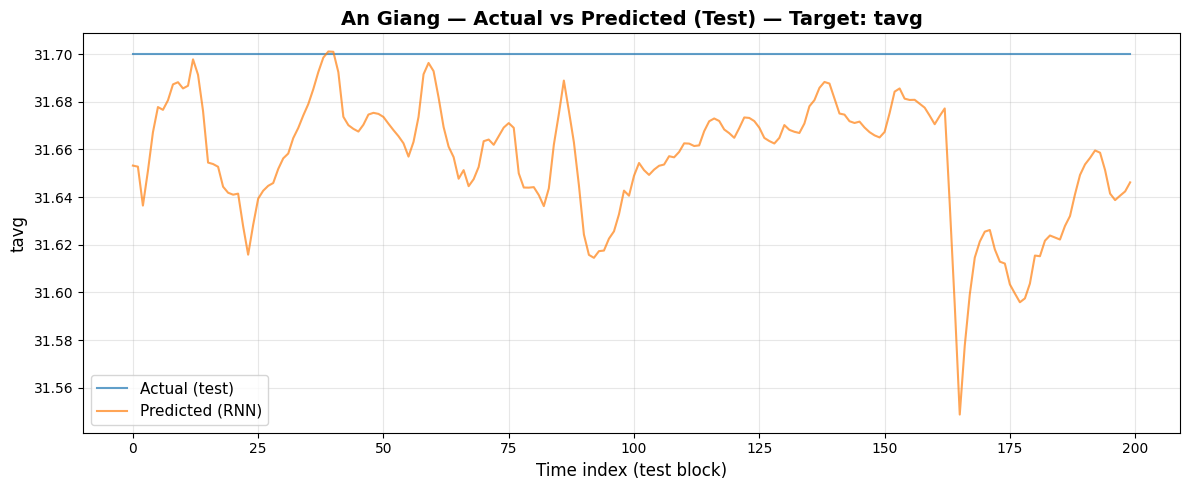

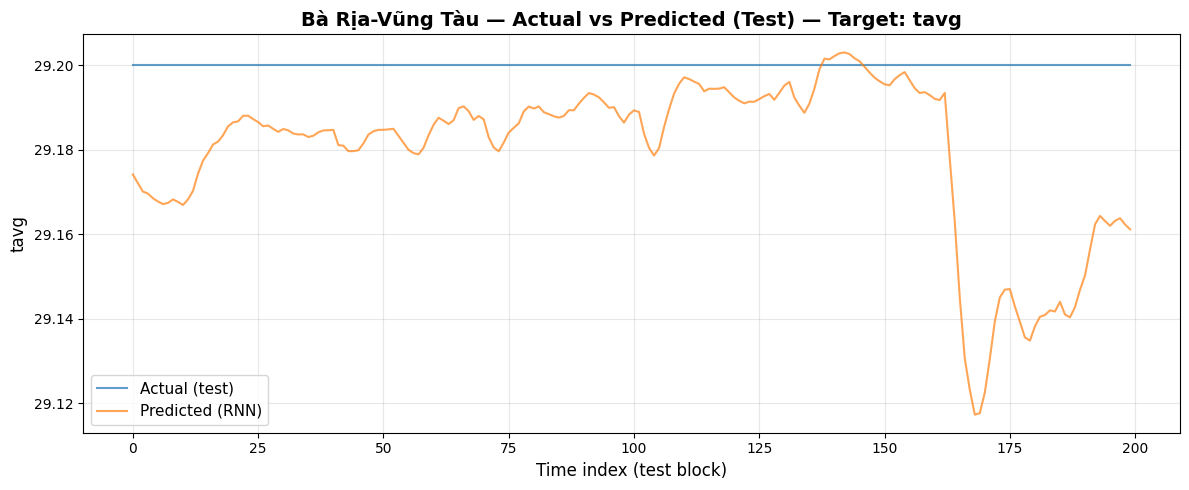

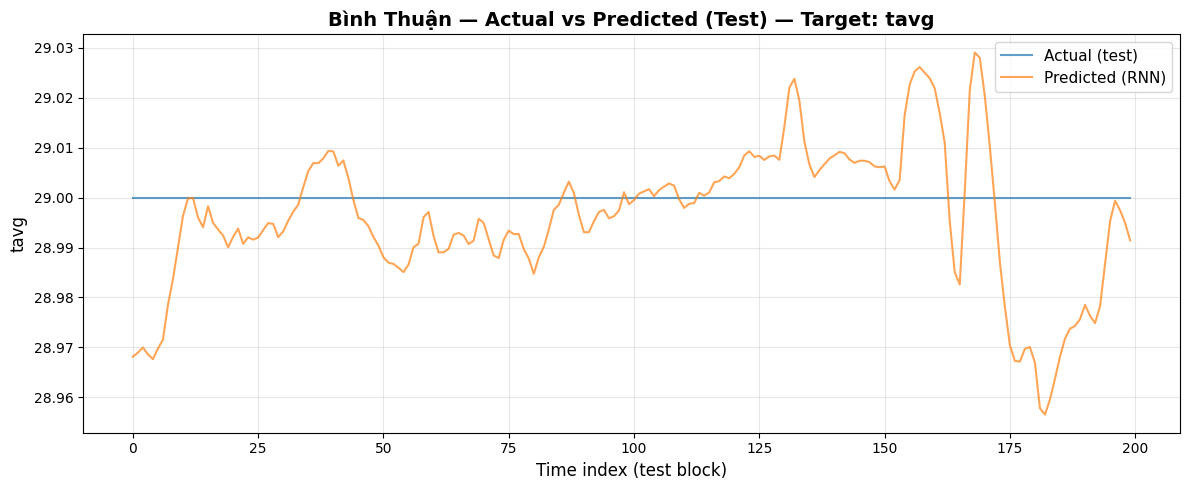

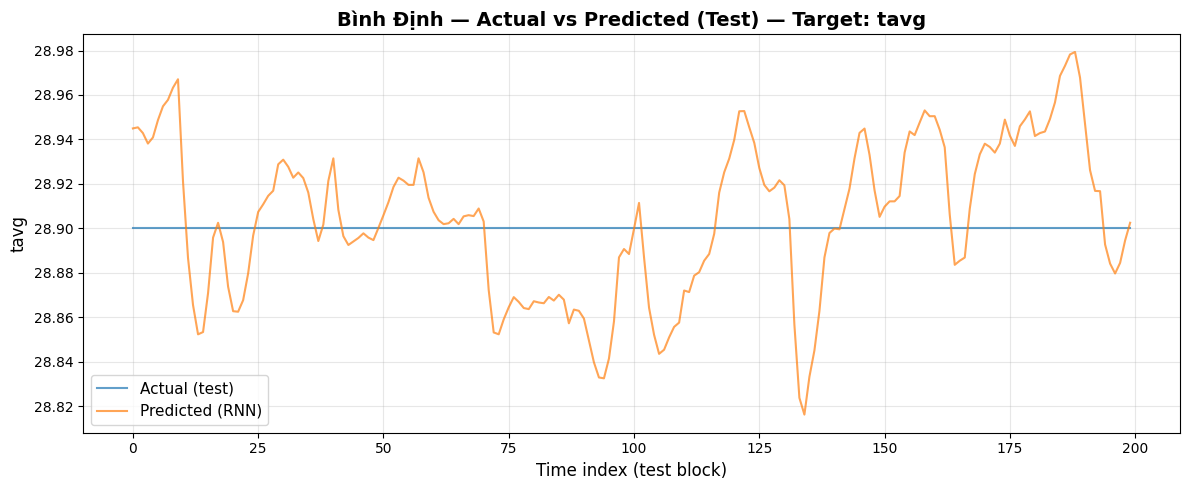

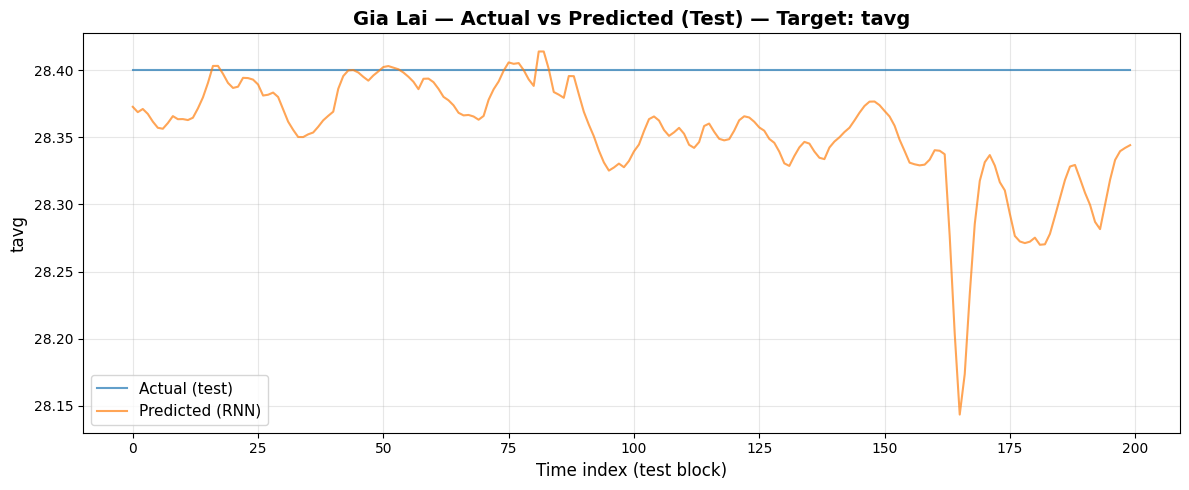

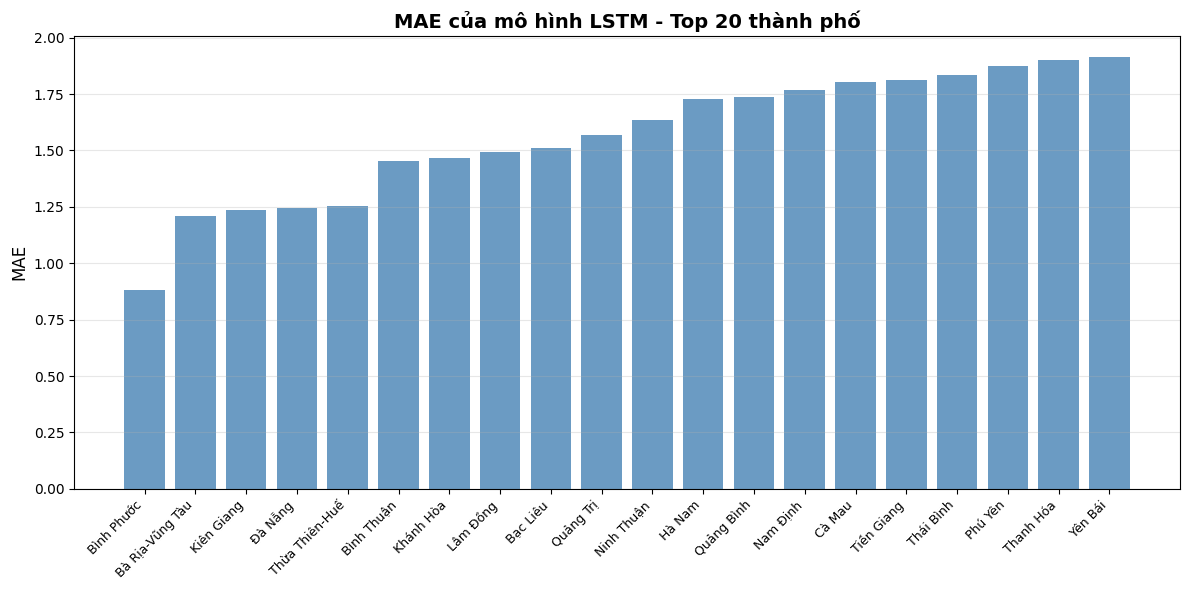

In [9]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 10: Visualization kết quả ====

if RESULTS_DEEP:
    # 1) Actual vs Predicted (test) - chỉ hiển thị 5 thành phố đầu tiên
    print("Hiển thị kết quả cho 5 thành phố đầu tiên...")
    for idx, (city, res) in enumerate(list(RESULTS_DEEP.items())[:5]):
        y_true = res["y_true"]
        y_pred = res["lstm_pred"] if res["best"]=="lstm" else res["rnn_pred"]
        
        plt.figure(figsize=(12, 5))
        plt.plot(y_true[:200], label="Actual (test)", alpha=0.7, linewidth=1.5)
        plt.plot(y_pred[:200], label=f"Predicted ({res['best'].upper()})", alpha=0.7, linewidth=1.5)
        plt.title(f"{city} — Actual vs Predicted (Test) — Target: {res['target']}", fontsize=14, fontweight='bold')
        plt.xlabel("Time index (test block)", fontsize=12)
        plt.ylabel(res["target"], fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # 2) Biểu đồ MAE cho LSTM (nếu chỉ train LSTM thì bỏ so sánh)
    cities = list(RESULTS_DEEP.keys())
    mae_lstm = [RESULTS_DEEP[c]["lstm_metrics"]["MAE"] for c in cities]
    
    # Chỉ hiển thị top 20 thành phố để tránh quá dài
    if len(cities) > 20:
        top_20_idx = np.argsort(mae_lstm)[:20]
        cities_display = [cities[i] for i in top_20_idx]
        mae_display = [mae_lstm[i] for i in top_20_idx]
    else:
        cities_display = cities
        mae_display = mae_lstm
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(cities_display)), mae_display, alpha=0.8, color='steelblue')
    plt.xticks(range(len(cities_display)), cities_display, rotation=45, ha='right', fontsize=9)
    plt.ylabel("MAE", fontsize=12)
    plt.title(f"MAE của mô hình LSTM - Top {len(cities_display)} thành phố", fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # 3) Biểu đồ Forecast 7 ngày
    for city, res in RESULTS_DEEP.items():
        fp = res.get("forecast_path", None)
        if fp and os.path.exists(fp):
            fc = pd.read_csv(fp, parse_dates=["date"])
            tgt = [c for c in fc.columns if c.startswith("pred_")][0]
            plt.figure(figsize=(10, 5))
            plt.plot(fc["date"], fc[tgt], marker='o', linewidth=2, markersize=6)
            plt.title(f"{city} — 7-day Forecast ({res['best'].upper()}) — Target: {res['target']}", 
                     fontsize=14, fontweight='bold')
            plt.xlabel("Date", fontsize=12)
            plt.ylabel(res["target"], fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
else:
    print("⚠️ Chưa có RESULTS_DEEP. Hãy chạy cell huấn luyện trước.")


In [10]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 11: Bảng đánh giá chi tiết ====

if RESULTS_DEEP:
    rows = []
    for city, res in RESULTS_DEEP.items():
        rnn = res.get("rnn_metrics")  # Có thể là None nếu chỉ train LSTM
        lstm = res["lstm_metrics"]
        
        # Chỉ thêm RNN nếu có dữ liệu
        if rnn is not None:
            rows.append([city, res["target"], "RNN",  rnn["MAE"],  rnn["MSE"],  rnn["RMSE"],  rnn["R2"], res.get("forecast_path")])
        
        # Luôn thêm LSTM
        rows.append([city, res["target"], "LSTM", lstm["MAE"], lstm["MSE"], lstm["RMSE"], lstm["R2"], res.get("forecast_path")])
    
    metrics_df = pd.DataFrame(rows, columns=["City","Target","Model","MAE","MSE","RMSE","R2","Forecast_CSV"])
    
    print("="*80)
    print("BẢNG ĐÁNH GIÁ CHI TIẾT - MÔ HÌNH >=7 LAYERS")
    print("="*80)
    display(metrics_df.round(4))
    
    print("\n" + "="*80)
    print("MÔ HÌNH TỐT NHẤT THEO MAE (Mean Absolute Error)")
    print("="*80)
    for city in metrics_df["City"].unique():
        sub = metrics_df[(metrics_df["City"]==city)]
        if not sub.empty:
            best = sub.sort_values("MAE").iloc[0]
            print(f"\n{city}:")
            print(f"  - Mô hình: {best['Model']}")
            print(f"  - MAE: {best['MAE']:.4f}")
            print(f"  - RMSE: {best['RMSE']:.4f}")
            print(f"  - R²: {best['R2']:.4f}")
            print(f"  - File dự báo: {best['Forecast_CSV']}")
else:
    print("⚠️ Chưa có RESULTS_DEEP. Hãy chạy cell huấn luyện trước.")


BẢNG ĐÁNH GIÁ CHI TIẾT - MÔ HÌNH >=7 LAYERS


,City,Target,Model,MAE,MSE,RMSE,R2,Forecast_CSV
0,An Giang,tavg,RNN,2.0495,9.2917,3.0482,-0.7317,None
1,An Giang,tavg,LSTM,2.0850,8.2257,2.8680,-0.5330,None
2,Bà Rịa-Vũng Tàu,tavg,RNN,1.0948,3.0431,1.7445,-0.4509,None
3,Bà Rịa-Vũng Tàu,tavg,LSTM,1.2087,3.1997,1.7888,-0.5256,None
4,Bình Thuận,tavg,RNN,1.2594,3.9131,1.9782,-0.5891,None
...,...,...,...,...,...,...,...,...
121,Điện Biên,tavg,LSTM,2.5822,9.7857,3.1282,-0.9414,None
122,Đồng Tháp,tavg,RNN,1.1212,1.8542,1.3617,0.0064,None
123,Đồng Tháp,tavg,LSTM,2.0515,5.0729,2.2523,-1.7185,None
124,Hải Phòng,tavg,RNN,2.5543,8.6173,2.9355,-0.8106,None



MÔ HÌNH TỐT NHẤT THEO MAE (Mean Absolute Error)

An Giang:
  - Mô hình: RNN
  - MAE: 2.0495
  - RMSE: 3.0482
  - R²: -0.7317
  - File dự báo: None

Bà Rịa-Vũng Tàu:
  - Mô hình: RNN
  - MAE: 1.0948
  - RMSE: 1.7445
  - R²: -0.4509
  - File dự báo: None

Bình Thuận:
  - Mô hình: RNN
  - MAE: 1.2594
  - RMSE: 1.9782
  - R²: -0.5891
  - File dự báo: None

Bình Định:
  - Mô hình: RNN
  - MAE: 1.7689
  - RMSE: 3.0331
  - R²: -0.3858
  - File dự báo: None

Gia Lai:
  - Mô hình: RNN
  - MAE: 3.1014
  - RMSE: 4.4874
  - R²: -0.8557
  - File dự báo: None

Long An:
  - Mô hình: RNN
  - MAE: 1.8745
  - RMSE: 2.8509
  - R²: -0.7131
  - File dự báo: None

Ho Chi Minh City:
  - Mô hình: RNN
  - MAE: 2.0112
  - RMSE: 3.0138
  - R²: -0.7506
  - File dự báo: None

Kiên Giang:
  - Mô hình: RNN
  - MAE: 1.1879
  - RMSE: 1.8630
  - R²: -0.5612
  - File dự báo: None

Khánh Hòa:
  - Mô hình: RNN
  - MAE: 1.4392
  - RMSE: 2.4533
  - R²: -0.4115
  - File dự báo: None

Quảng Nam:
  - Mô hình: RNN
  - MAE: 2.2

In [11]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 12: Tạo bản đồ choropleth nhiệt độ trung bình 30 ngày ====

# Import thư viện cho bản đồ
try:
    import folium
    from folium import plugins
    FOLIUM_OK = True
except:
    FOLIUM_OK = False
    print("⚠️ Folium chưa được cài đặt. Đang thử geopandas...")

try:
    import geopandas as gpd
    GEOPANDAS_OK = True
except:
    GEOPANDAS_OK = False
    print("⚠️ GeoPandas chưa được cài đặt.")

# Tính toán nhiệt độ trung bình 7 ngày cho mỗi tỉnh/thành
# Nếu không có dự báo, dùng dữ liệu lịch sử gần đây
print("\n" + "="*60)
print("TÍNH TOÁN NHIỆT ĐỘ TRUNG BÌNH 7 NGÀY CHO MỖI TỈNH/THÀNH")
print("="*60)

forecast_7days = {}
# Lấy từ dự báo nếu có
for city, res in RESULTS_DEEP.items():
    fp = res.get("forecast_path", None)
    target = res.get("target", None)
    
    # Chỉ lấy từ dự báo nếu target là tavg
    if fp and os.path.exists(fp) and target == "tavg":
        fc = pd.read_csv(fp, parse_dates=["date"])
        # Tìm cột dự báo nhiệt độ
        tavg_col = None
        for col in fc.columns:
            if "pred_tavg" in col or "pred_tavg" in col.lower():
                tavg_col = col
                break
        
        if tavg_col:
            avg_temp = fc[tavg_col].mean()
            # Kiểm tra xem giá trị có hợp lý không (nhiệt độ Việt Nam thường 15-35°C)
            # Nếu giá trị < 5°C hoặc > 50°C, có thể đang bị scale hoặc target sai, dùng dữ liệu lịch sử
            if avg_temp >= 5 and avg_temp <= 50:
                forecast_7days[city] = avg_temp
                print(f"✓ {city}: {avg_temp:.2f}°C (từ dự báo 7 ngày)")
            else:
                # Giá trị không hợp lý (< 5°C hoặc > 50°C), dùng dữ liệu lịch sử
                df_city = df_all[df_all["city"] == city]
                if "tavg" in df_city.columns and df_city["tavg"].notna().any():
                    recent_avg = df_city["tavg"].tail(7).mean()
                    forecast_7days[city] = recent_avg
                    print(f"⚠ {city}: {recent_avg:.2f}°C (từ dữ liệu lịch sử - dự báo không hợp lý: {avg_temp:.2f}°C, target={target})")
        else:
            # Không tìm thấy cột tavg, dùng dữ liệu lịch sử
            df_city = df_all[df_all["city"] == city]
            if "tavg" in df_city.columns and df_city["tavg"].notna().any():
                recent_avg = df_city["tavg"].tail(7).mean()
                forecast_7days[city] = recent_avg
                print(f"⚠ {city}: {recent_avg:.2f}°C (từ dữ liệu lịch sử - không có cột pred_tavg)")
    else:
        # Target không phải tavg hoặc không có file, dùng dữ liệu lịch sử
        df_city = df_all[df_all["city"] == city]
        if "tavg" in df_city.columns and df_city["tavg"].notna().any():
            recent_avg = df_city["tavg"].tail(7).mean()
            forecast_7days[city] = recent_avg
            if target != "tavg":
                print(f"⚠ {city}: {recent_avg:.2f}°C (từ dữ liệu lịch sử - target là {target}, không phải tavg)")
            else:
                print(f"⚠ {city}: {recent_avg:.2f}°C (từ dữ liệu lịch sử - không có file dự báo)")

# Bổ sung các thành phố chưa có dự báo bằng dữ liệu lịch sử
print("\nĐang bổ sung dữ liệu cho các thành phố chưa có dự báo...")
for city in df_all["city"].unique():
    if city not in forecast_7days:
        df_city = df_all[df_all["city"] == city]
        if "tavg" in df_city.columns and df_city["tavg"].notna().any():
            recent_avg = df_city["tavg"].tail(7).mean()
            forecast_7days[city] = recent_avg
            print(f"  ✓ {city}: {recent_avg:.2f}°C (từ dữ liệu lịch sử)")

print(f"\nTổng số tỉnh/thành có dữ liệu: {len(forecast_7days)}")

# Tạo DataFrame cho bản đồ
map_df = pd.DataFrame({
    "city": list(forecast_7days.keys()),
    "avg_temp_7d": list(forecast_7days.values())
}).sort_values("city")

print("\n" + "="*60)
print("DỮ LIỆU CHO BẢN ĐỒ")
print("="*60)
print(map_df.head(10))



TÍNH TOÁN NHIỆT ĐỘ TRUNG BÌNH 7 NGÀY CHO MỖI TỈNH/THÀNH
⚠ An Giang: 28.24°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Bà Rịa-Vũng Tàu: 28.16°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Bình Thuận: 26.91°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Bình Định: 28.50°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Gia Lai: 22.80°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Long An: 28.06°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Ho Chi Minh City: 28.36°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Kiên Giang: 28.63°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Khánh Hòa: 27.51°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Quảng Nam: 28.34°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Phú Yên: 28.50°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Ninh Thuận: 28.04°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Phú Thọ: 27.94°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Nghệ An: 28.79°C (từ dữ liệu lịch sử - không có file dự báo)
⚠ Lâm Đồng: 20.80°C (từ dữ l

In [12]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 13: Tạo bản đồ choropleth sử dụng Folium ====

# ✅ SỬA: Sử dụng forecast_7days_lstm hoặc forecast_7days_rnn
if 'forecast_7days_lstm' in globals() and len(forecast_7days_lstm) > 0:
    forecast_7days = forecast_7days_lstm
    model_name = "LSTM"
elif 'forecast_7days_rnn' in globals() and len(forecast_7days_rnn) > 0:
    forecast_7days = forecast_7days_rnn
    model_name = "RNN"
else:
    print("⚠️ Chưa có dữ liệu dự báo. Hãy chạy Cell 11 và Cell 12 trước.")
    forecast_7days = {}

if FOLIUM_OK and len(forecast_7days) > 0:
    print(f"\n📍 Tạo bản đồ Folium với {len(forecast_7days)} tỉnh/thành ({model_name})...")
    
    # Tọa độ trung tâm Việt Nam
    vietnam_center = [16.0544, 108.2772]
    
    # Tạo bản đồ
    m = folium.Map(
        location=vietnam_center,
        zoom_start=6,
        tiles='OpenStreetMap'
    )
    
    # Mapping tên tỉnh/thành với tọa độ (tọa độ gần đúng)
    city_coords = {
        "Hà Nội": [21.0285, 105.8542],
        "Ha Noi": [21.0285, 105.8542],
        "Ho Chi Minh City": [10.8231, 106.6297],
        "Đà Nẵng": [16.0544, 108.2772],
        "Da Nang": [16.0544, 108.2772],
        "Cần Thơ": [10.0452, 105.7469],
        "Can Tho": [10.0452, 105.7469],
        "Hải Phòng": [20.8449, 106.6881],
        "Hai Phong": [20.8449, 106.6881],
    }
    
    # Thêm markers cho các tỉnh/thành
    for city, temp in forecast_7days.items():
        if city in city_coords:
            lat, lon = city_coords[city]
            # Màu sắc dựa trên nhiệt độ
            if temp < 15:
                color = 'blue'
            elif temp < 20:
                color = 'lightblue'
            elif temp < 25:
                color = 'green'
            elif temp < 28:
                color = 'orange'
            else:
                color = 'red'
            
            folium.CircleMarker(
                location=[lat, lon],
                radius=10,
                popup=f"{city}: {temp:.1f}°C",
                tooltip=f"{city}: {temp:.1f}°C",
                color=color,
                fill=True,
                fillColor=color,
                fillOpacity=0.7
            ).add_to(m)
    
    # Lưu bản đồ
    map_path = os.path.join(SAVE_DIR, f"folium_map_{model_name}.html")
    m.save(map_path)
    print(f"✓ Đã lưu bản đồ Folium: {map_path}")
    
    # Display (nếu chạy trong Jupyter)
    try:
        display(m)
    except:
        print("  (Mở file HTML để xem bản đồ)")
else:
    if not FOLIUM_OK:
        print("⚠️ Folium chưa được cài đặt. Cài: pip install folium")
    else:
        print("⚠️ Không có dữ liệu dự báo để tạo bản đồ Folium.")



⚠️ Chưa có dữ liệu dự báo. Hãy chạy Cell 11 và Cell 12 trước.
⚠️ Không có dữ liệu dự báo để tạo bản đồ Folium.


In [13]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell MỚI: Tính nhiệt độ trung bình 7 ngày cho RNN và LSTM ====

print("\n" + "="*80)
print("TÍNH NHIỆT ĐỘ TRUNG BÌNH 7 NGÀY CHO MỖI MODEL")
print("="*80)

# Tạo 2 dict riêng cho RNN và LSTM
forecast_7days_rnn = {}
forecast_7days_lstm = {}

for city, forecasts in FORECASTS_DEEP.items():
    # forecasts là dict có keys: 'rnn', 'lstm' (nếu train cả 2)
    if 'rnn' in forecasts:
        avg_temp_rnn = forecasts['rnn']['avg_temp']
        if avg_temp_rnn >= 5 and avg_temp_rnn <= 50:  # Nhiệt độ hợp lý
            forecast_7days_rnn[city] = avg_temp_rnn
            print(f"✓ RNN - {city}: {avg_temp_rnn:.2f}°C")
        else:
            # Dùng dữ liệu lịch sử nếu không hợp lý
            df_city = df_all[df_all["city"] == city]
            if "tavg" in df_city.columns and df_city["tavg"].notna().any():
                recent_avg = df_city["tavg"].tail(7).mean()
                forecast_7days_rnn[city] = recent_avg
                print(f"⚠ RNN - {city}: {recent_avg:.2f}°C (từ dữ liệu lịch sử)")
    
    if 'lstm' in forecasts:
        avg_temp_lstm = forecasts['lstm']['avg_temp']
        if avg_temp_lstm >= 5 and avg_temp_lstm <= 50:  # Nhiệt độ hợp lý
            forecast_7days_lstm[city] = avg_temp_lstm
            print(f"✓ LSTM - {city}: {avg_temp_lstm:.2f}°C")
        else:
            # Dùng dữ liệu lịch sử nếu không hợp lý
            df_city = df_all[df_all["city"] == city]
            if "tavg" in df_city.columns and df_city["tavg"].notna().any():
                recent_avg = df_city["tavg"].tail(7).mean()
                forecast_7days_lstm[city] = recent_avg
                print(f"⚠ LSTM - {city}: {recent_avg:.2f}°C (từ dữ liệu lịch sử)")

# Bổ sung các thành phố chưa có dự báo bằng dữ liệu lịch sử
print("\nĐang bổ sung dữ liệu cho các thành phố chưa có dự báo...")
for city in df_all["city"].unique():
    if city not in forecast_7days_rnn and city not in forecast_7days_lstm:
        df_city = df_all[df_all["city"] == city]
        if "tavg" in df_city.columns and df_city["tavg"].notna().any():
            recent_avg = df_city["tavg"].tail(7).mean()
            forecast_7days_rnn[city] = recent_avg
            forecast_7days_lstm[city] = recent_avg
            print(f"  ✓ {city}: {recent_avg:.2f}°C (từ dữ liệu lịch sử)")

print(f"\n✓ RNN: {len(forecast_7days_rnn)} tỉnh/thành có dữ liệu")
print(f"✓ LSTM: {len(forecast_7days_lstm)} tỉnh/thành có dữ liệu")

# Tạo DataFrame cho bản đồ
map_df_rnn = pd.DataFrame({
    "city": list(forecast_7days_rnn.keys()),
    "avg_temp_7d": list(forecast_7days_rnn.values()),
    "model": "RNN"
}).sort_values("city")

map_df_lstm = pd.DataFrame({
    "city": list(forecast_7days_lstm.keys()),
    "avg_temp_7d": list(forecast_7days_lstm.values()),
    "model": "LSTM"
}).sort_values("city")

print("\n" + "="*80)
print("DỮ LIỆU CHO BẢN ĐỒ RNN")
print("="*80)
print(map_df_rnn.head(10))

print("\n" + "="*80)
print("DỮ LIỆU CHO BẢN ĐỒ LSTM")
print("="*80)
print(map_df_lstm.head(10))



TÍNH NHIỆT ĐỘ TRUNG BÌNH 7 NGÀY CHO MỖI MODEL
✓ RNN - An Giang: 31.71°C
✓ LSTM - An Giang: 31.85°C
✓ RNN - Bà Rịa-Vũng Tàu: 29.20°C
✓ LSTM - Bà Rịa-Vũng Tàu: 29.39°C
✓ RNN - Bình Thuận: 28.99°C
✓ LSTM - Bình Thuận: 29.26°C
✓ RNN - Bình Định: 28.91°C
✓ LSTM - Bình Định: 29.10°C
✓ RNN - Gia Lai: 28.42°C
✓ LSTM - Gia Lai: 28.91°C
✓ RNN - Long An: 30.92°C
✓ LSTM - Long An: 31.01°C
✓ RNN - Ho Chi Minh City: 31.63°C
✓ LSTM - Ho Chi Minh City: 31.67°C
✓ RNN - Kiên Giang: 29.91°C
✓ LSTM - Kiên Giang: 30.02°C
✓ RNN - Khánh Hòa: 28.41°C
✓ LSTM - Khánh Hòa: 28.43°C
✓ RNN - Quảng Nam: 29.25°C
✓ LSTM - Quảng Nam: 29.66°C
✓ RNN - Phú Yên: 28.95°C
✓ LSTM - Phú Yên: 29.03°C
✓ RNN - Ninh Thuận: 28.96°C
✓ LSTM - Ninh Thuận: 28.91°C
✓ RNN - Phú Thọ: 28.04°C
✓ LSTM - Phú Thọ: 28.09°C
✓ RNN - Nghệ An: 30.84°C
✓ LSTM - Nghệ An: 31.61°C
✓ RNN - Lâm Đồng: 21.89°C
✓ LSTM - Lâm Đồng: 21.89°C
✓ RNN - Tiền Giang: 30.38°C
✓ LSTM - Tiền Giang: 30.13°C
✓ RNN - Quảng Ninh: 25.59°C
✓ LSTM - Quảng Ninh: 25.16°C
✓ RNN 

In [14]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== CELL MỚI: ƯỚC LƯỢNG NHIỆT ĐỘ CHO CÁC ĐẢO ====

print("\n" + "="*80)
print("🏝️ ƯỚC LƯỢNG NHIỆT ĐỘ CHO CÁC ĐẢO VÀ QUẦN ĐẢO")
print("="*80)

# Mapping các đảo với tỉnh/thành phố gần nhất
ISLAND_TO_PROVINCE_MAPPING = {
    # Các đảo lớn
    "Phú Quốc": "Kiên Giang",                    # Đảo Phú Quốc thuộc Kiên Giang
    "Cô Tô": "Quảng Ninh",                       # Quần đảo Cô Tô thuộc Quảng Ninh
    "Cát Bà": "Hải Phòng",                       # Đảo Cát Bà thuộc Hải Phòng
    "Lý Sơn": "Quảng Ngãi",                      # Đảo Lý Sơn thuộc Quảng Ngãi
    "Cù Lao Chàm": "Quảng Nam",                  # Cù Lao Chàm thuộc Quảng Nam (Hội An)
    "Côn Đảo": "Bà Rịa-Vũng Tàu",               # Côn Đảo thuộc BR-VT
    "Phú Quý": "Bình Thuận",                     # Đảo Phú Quý thuộc Bình Thuận
    
    # Các đảo nhỏ và quần đảo khác
    "Bạch Long Vĩ": "Hải Phòng",                # Đảo Bạch Long Vĩ thuộc Hải Phòng
    "Thổ Chu": "Thanh Hóa",                      # Đảo Thổ Chu thuộc Thanh Hóa
    "Hòn Mê": "Nghệ An",                         # Hòn Mê thuộc Nghệ An
    "Hòn Mát": "Bình Định",                      # Hòn Mát thuộc Bình Định
    "Hòn Tre": "Khánh Hòa",                      # Hòn Tre thuộc Nha Trang, Khánh Hòa
    "Điệp Sơn": "Khánh Hòa",                     # Điệp Sơn thuộc Khánh Hòa
    "Bình Hưng": "Khánh Hòa",                    # Bình Hưng thuộc Khánh Hòa
    "Hòn Cau": "Bình Thuận",                     # Hòn Cau thuộc Bình Thuận
    "Nam Du": "Kiên Giang",                      # Quần đảo Nam Du thuộc Kiên Giang
    "Hòn Đất": "Kiên Giang",                     # Hòn Đất thuộc Kiên Giang
    "Thổ Châu": "Kiên Giang",                    # Thổ Châu thuộc Kiên Giang
    
    # Quần đảo chủ quyền
    "Hoàng Sa": "Đà Nẵng",                       # Quần đảo Hoàng Sa (gần Đà Nẵng nhất)
    "Trường Sa": "Khánh Hòa",                    # Quần đảo Trường Sa (gần Khánh Hòa nhất)
    
    # Các tên tiếng Anh (nếu GeoJSON dùng tiếng Anh)
    "Phu Quoc": "Kiên Giang",
    "Co To": "Quảng Ninh",
    "Cat Ba": "Hải Phòng",
    "Ly Son": "Quảng Ngãi",
    "Cu Lao Cham": "Quảng Nam",
    "Con Dao": "Bà Rịa-Vũng Tàu",
    "Phu Quy": "Bình Thuận",
    "Hoang Sa": "Đà Nẵng",
    "Truong Sa": "Khánh Hòa",
    "Paracel Islands": "Đà Nẵng",                # Tên tiếng Anh của Hoàng Sa
    "Spratly Islands": "Khánh Hòa",              # Tên tiếng Anh của Trường Sa
}

# Thêm vào dữ liệu dự báo cho cả RNN và LSTM
if 'forecast_7days_lstm' in globals() and len(forecast_7days_lstm) > 0:
    print("\n📍 Đang ước lượng nhiệt độ cho các đảo từ tỉnh/thành gần nhất...\n")
    
    islands_added_lstm = []
    islands_added_rnn = []
    
    for island, province in ISLAND_TO_PROVINCE_MAPPING.items():
        # Ước lượng cho LSTM
        if province in forecast_7days_lstm:
            forecast_7days_lstm[island] = forecast_7days_lstm[province]
            islands_added_lstm.append((island, province, forecast_7days_lstm[province]))
            print(f"  🏝️  {island:20s} → {province:20s}: {forecast_7days_lstm[province]:.2f}°C (LSTM)")
        
        # Ước lượng cho RNN (nếu có)
        if 'forecast_7days_rnn' in globals() and province in forecast_7days_rnn:
            forecast_7days_rnn[island] = forecast_7days_rnn[province]
            islands_added_rnn.append((island, province, forecast_7days_rnn[province]))
    
    print(f"\n{'='*80}")
    print(f"✅ TỔNG KẾT ƯỚC LƯỢNG")
    print(f"{'='*80}")
    print(f"  📊 LSTM: Đã thêm {len(islands_added_lstm)} đảo/quần đảo")
    if 'forecast_7days_rnn' in globals():
        print(f"  📊 RNN:  Đã thêm {len(islands_added_rnn)} đảo/quần đảo")
    
    print(f"\n  🌡️  Nhiệt độ ước lượng cao nhất:  {max([temp for _, _, temp in islands_added_lstm]):.2f}°C")
    print(f"  🌡️  Nhiệt độ ước lượng thấp nhất: {min([temp for _, _, temp in islands_added_lstm]):.2f}°C")
    
    # Tạo DataFrame với đảo
    print(f"\n📋 DANH SÁCH ĐẦY ĐỦ (bao gồm đảo):")
    print(f"  - Tổng số tỉnh/thành + đảo (LSTM): {len(forecast_7days_lstm)}")
    if 'forecast_7days_rnn' in globals():
        print(f"  - Tổng số tỉnh/thành + đảo (RNN):  {len(forecast_7days_rnn)}")
    
    # Update map_df
    map_df_lstm = pd.DataFrame({
        "city": list(forecast_7days_lstm.keys()),
        "avg_temp_7d": list(forecast_7days_lstm.values()),
        "model": "LSTM"
    }).sort_values("city")
    
    if 'forecast_7days_rnn' in globals():
        map_df_rnn = pd.DataFrame({
            "city": list(forecast_7days_rnn.keys()),
            "avg_temp_7d": list(forecast_7days_rnn.values()),
            "model": "RNN"
        }).sort_values("city")
    
    print(f"\n⚠️  LƯU Ý QUAN TRỌNG:")
    print(f"{'='*80}")
    print(f"""
    🔸 Dữ liệu cho các đảo là ƯỚC LƯỢNG từ tỉnh/thành gần nhất
    🔸 KHÔNG PHẢI dự báo thực tế từ model
    🔸 Sai số có thể lên đến 2-5°C do đặc điểm khí hậu đảo khác đất liền
    🔸 Chỉ mang tính THAM KHẢO, không nên dùng cho mục đích chính thức
    
    📌 Lý do ước lượng:
       - Khí hậu đảo biển khác với đất liền (ổn định hơn, ẩm hơn)
       - Không có dữ liệu lịch sử để train model
       - Một số đảo có vấn đề chủ quyền (Hoàng Sa, Trường Sa)
    
    ✅ Để có dự báo chính xác cho các đảo:
       → Cần thu thập dữ liệu lịch sử thời tiết riêng cho từng đảo
       → Train model riêng hoặc fine-tune model hiện tại
    """)
    
    print(f"\n🗺️  Bây giờ bạn có thể tạo bản đồ với TẤT CẢ các đảo!")
    print(f"   (Chạy lại các cell tạo bản đồ để cập nhật)")
    
else:
    print("⚠️ Chưa có dữ liệu dự báo. Hãy chạy các cell trước đó.")




🏝️ ƯỚC LƯỢNG NHIỆT ĐỘ CHO CÁC ĐẢO VÀ QUẦN ĐẢO

📍 Đang ước lượng nhiệt độ cho các đảo từ tỉnh/thành gần nhất...

  🏝️  Phú Quốc             → Kiên Giang          : 30.02°C (LSTM)
  🏝️  Cô Tô                → Quảng Ninh          : 25.16°C (LSTM)
  🏝️  Cát Bà               → Hải Phòng           : 24.27°C (LSTM)
  🏝️  Lý Sơn               → Quảng Ngãi          : 25.37°C (LSTM)
  🏝️  Cù Lao Chàm          → Quảng Nam           : 29.66°C (LSTM)
  🏝️  Côn Đảo              → Bà Rịa-Vũng Tàu     : 29.39°C (LSTM)
  🏝️  Phú Quý              → Bình Thuận          : 29.26°C (LSTM)
  🏝️  Bạch Long Vĩ         → Hải Phòng           : 24.27°C (LSTM)
  🏝️  Thổ Chu              → Thanh Hóa           : 26.51°C (LSTM)
  🏝️  Hòn Mê               → Nghệ An             : 31.61°C (LSTM)
  🏝️  Hòn Mát              → Bình Định           : 29.10°C (LSTM)
  🏝️  Hòn Tre              → Khánh Hòa           : 28.43°C (LSTM)
  🏝️  Điệp Sơn             → Khánh Hòa           : 28.43°C (LSTM)
  🏝️  Bình Hưng            → 


📊 VISUALIZATION 1: SO SÁNH HIỆU SUẤT RNN VS LSTM


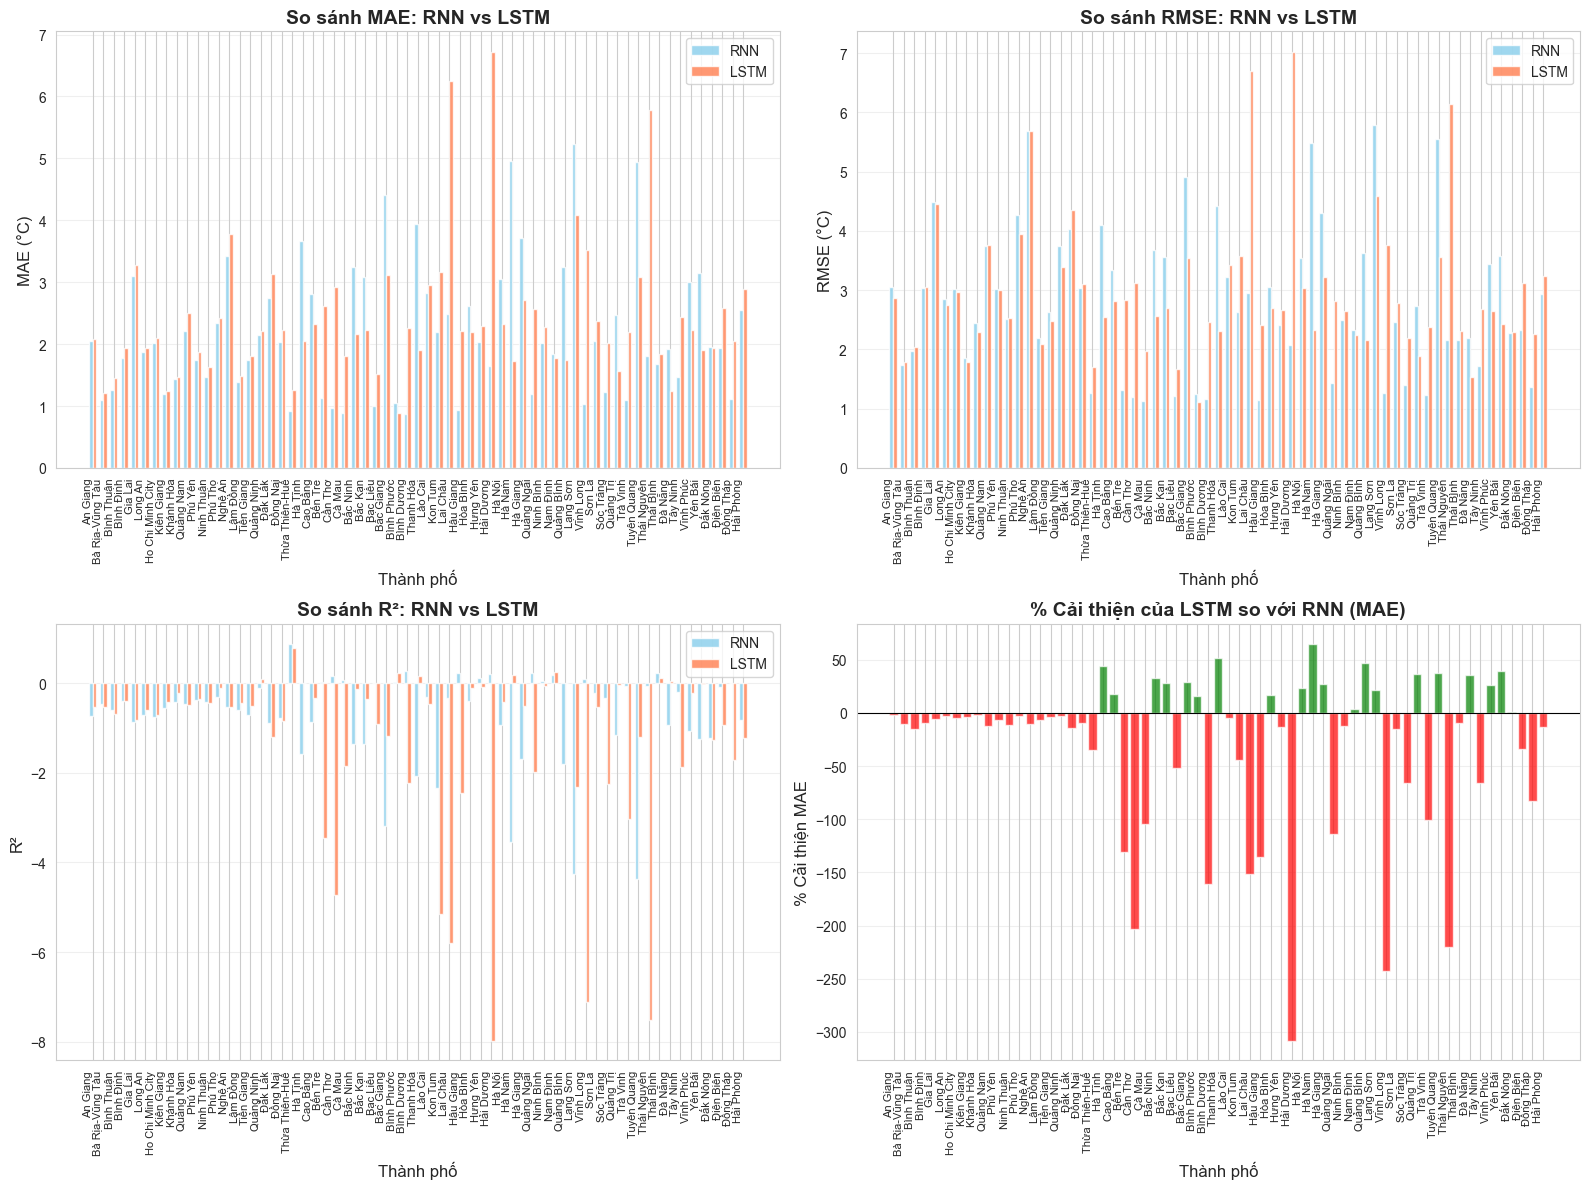


📈 THỐNG KÊ:
  RNN - MAE trung bình: 2.197°C
  LSTM - MAE trung bình: 2.404°C
  Cải thiện trung bình: -29.53%
  LSTM tốt hơn ở 20/63 thành phố


In [15]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== CELL MỚI: VISUALIZATION 1 - SO SÁNH RNN VS LSTM CHI TIẾT ====

import seaborn as sns
sns.set_style("whitegrid")

print("\n" + "="*80)
print("📊 VISUALIZATION 1: SO SÁNH HIỆU SUẤT RNN VS LSTM")
print("="*80)

if RESULTS_DEEP and not TRAIN_LSTM_ONLY:
    # Thu thập metrics
    cities = []
    rnn_maes, rnn_rmses, rnn_r2s = [], [], []
    lstm_maes, lstm_rmses, lstm_r2s = [], [], []
    
    for city, res in RESULTS_DEEP.items():
        if res.get("rnn_metrics") and res.get("lstm_metrics"):
            cities.append(city)
            rnn_maes.append(res["rnn_metrics"]["MAE"])
            rnn_rmses.append(res["rnn_metrics"]["RMSE"])
            rnn_r2s.append(res["rnn_metrics"]["R2"])
            lstm_maes.append(res["lstm_metrics"]["MAE"])
            lstm_rmses.append(res["lstm_metrics"]["RMSE"])
            lstm_r2s.append(res["lstm_metrics"]["R2"])
    
    # 1. Subplot: MAE, RMSE, R² comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1a. MAE Comparison
    ax = axes[0, 0]
    x = np.arange(len(cities))
    width = 0.35
    ax.bar(x - width/2, rnn_maes, width, label='RNN', alpha=0.8, color='skyblue')
    ax.bar(x + width/2, lstm_maes, width, label='LSTM', alpha=0.8, color='coral')
    ax.set_xlabel('Thành phố', fontsize=12)
    ax.set_ylabel('MAE (°C)', fontsize=12)
    ax.set_title('So sánh MAE: RNN vs LSTM', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=90, ha='right', fontsize=8)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 1b. RMSE Comparison
    ax = axes[0, 1]
    ax.bar(x - width/2, rnn_rmses, width, label='RNN', alpha=0.8, color='skyblue')
    ax.bar(x + width/2, lstm_rmses, width, label='LSTM', alpha=0.8, color='coral')
    ax.set_xlabel('Thành phố', fontsize=12)
    ax.set_ylabel('RMSE (°C)', fontsize=12)
    ax.set_title('So sánh RMSE: RNN vs LSTM', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=90, ha='right', fontsize=8)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 1c. R² Comparison
    ax = axes[1, 0]
    ax.bar(x - width/2, rnn_r2s, width, label='RNN', alpha=0.8, color='skyblue')
    ax.bar(x + width/2, lstm_r2s, width, label='LSTM', alpha=0.8, color='coral')
    ax.set_xlabel('Thành phố', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.set_title('So sánh R²: RNN vs LSTM', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=90, ha='right', fontsize=8)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 1d. Improvement Percentage
    ax = axes[1, 1]
    improvements = [(rnn - lstm) / rnn * 100 for rnn, lstm in zip(rnn_maes, lstm_maes)]
    colors = ['green' if imp > 0 else 'red' for imp in improvements]
    ax.bar(x, improvements, color=colors, alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Thành phố', fontsize=12)
    ax.set_ylabel('% Cải thiện MAE', fontsize=12)
    ax.set_title('% Cải thiện của LSTM so với RNN (MAE)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=90, ha='right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "01_rnn_lstm_comparison.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Statistics
    print(f"\n📈 THỐNG KÊ:")
    print(f"  RNN - MAE trung bình: {np.mean(rnn_maes):.3f}°C")
    print(f"  LSTM - MAE trung bình: {np.mean(lstm_maes):.3f}°C")
    print(f"  Cải thiện trung bình: {np.mean(improvements):.2f}%")
    print(f"  LSTM tốt hơn ở {sum(1 for i in improvements if i > 0)}/{len(improvements)} thành phố")
else:
    print("⚠️ Chưa có dữ liệu hoặc chỉ train LSTM.")




📊 VISUALIZATION 2: SCATTER PLOT - ACTUAL VS PREDICTED


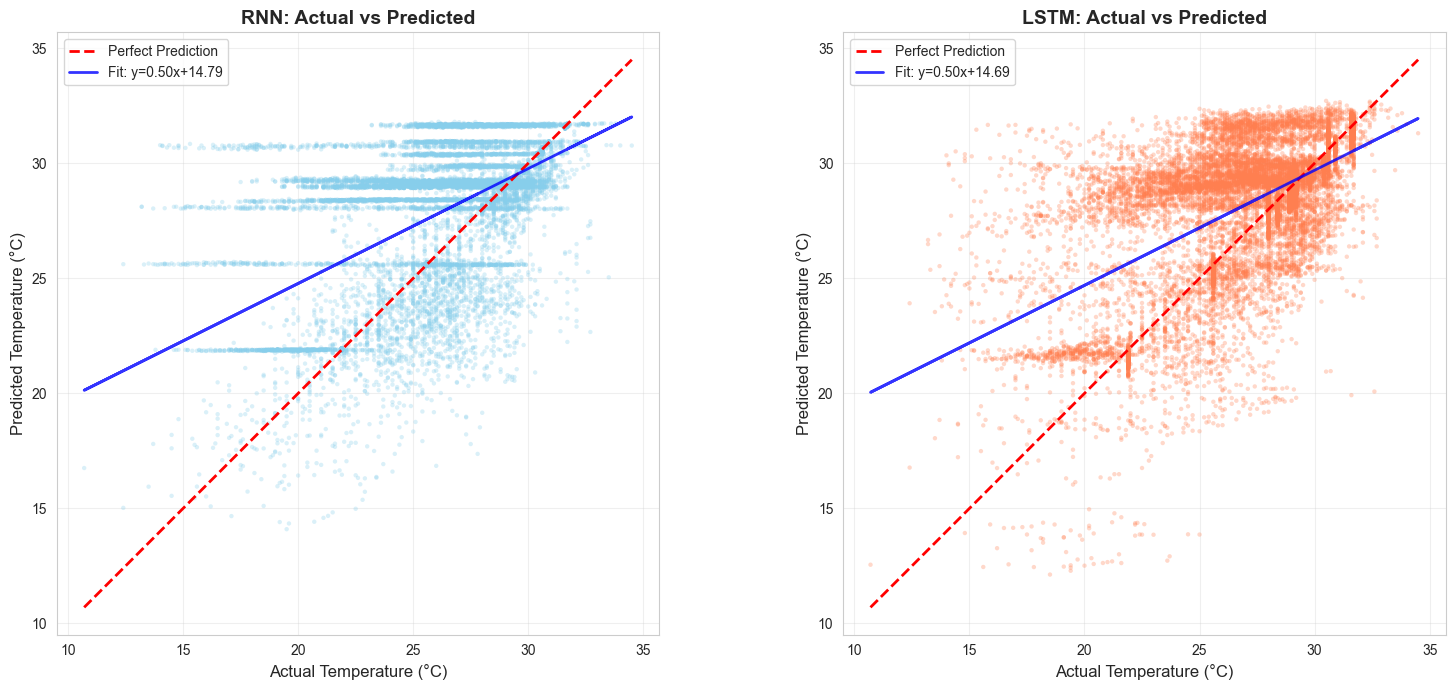

✓ Tổng số điểm dữ liệu: 17189


In [16]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== VISUALIZATION 2: SCATTER PLOT - ACTUAL VS PREDICTED ====

print("\n" + "="*80)
print("📊 VISUALIZATION 2: SCATTER PLOT - ACTUAL VS PREDICTED")
print("="*80)

if RESULTS_DEEP:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Collect all predictions
    all_actual = []
    all_rnn_pred = []
    all_lstm_pred = []
    
    for city, res in RESULTS_DEEP.items():
        all_actual.extend(res["y_true"])
        if res.get("rnn_pred") is not None:
            all_rnn_pred.extend(res["rnn_pred"])
        all_lstm_pred.extend(res["lstm_pred"])
    
    # RNN Scatter
    if len(all_rnn_pred) > 0 and not TRAIN_LSTM_ONLY:
        ax = axes[0]
        ax.scatter(all_actual, all_rnn_pred, alpha=0.3, s=10, color='skyblue', edgecolors='none')
        
        # Perfect prediction line
        min_val = min(min(all_actual), min(all_rnn_pred))
        max_val = max(max(all_actual), max(all_rnn_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        
        # Add regression line
        z = np.polyfit(all_actual, all_rnn_pred, 1)
        p = np.poly1d(z)
        ax.plot(all_actual, p(all_actual), "b-", alpha=0.8, linewidth=2, label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}')
        
        ax.set_xlabel('Actual Temperature (°C)', fontsize=12)
        ax.set_ylabel('Predicted Temperature (°C)', fontsize=12)
        ax.set_title('RNN: Actual vs Predicted', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')
    
    # LSTM Scatter
    ax = axes[1]
    ax.scatter(all_actual, all_lstm_pred, alpha=0.3, s=10, color='coral', edgecolors='none')
    
    min_val = min(min(all_actual), min(all_lstm_pred))
    max_val = max(max(all_actual), max(all_lstm_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    z = np.polyfit(all_actual, all_lstm_pred, 1)
    p = np.poly1d(z)
    ax.plot(all_actual, p(all_actual), "b-", alpha=0.8, linewidth=2, label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}')
    
    ax.set_xlabel('Actual Temperature (°C)', fontsize=12)
    ax.set_ylabel('Predicted Temperature (°C)', fontsize=12)
    ax.set_title('LSTM: Actual vs Predicted', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "02_scatter_actual_vs_predicted.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Tổng số điểm dữ liệu: {len(all_actual)}")
else:
    print("⚠️ Chưa có RESULTS_DEEP.")




📊 VISUALIZATION 3: PHÂN BỐ SAI SỐ (ERROR DISTRIBUTION)


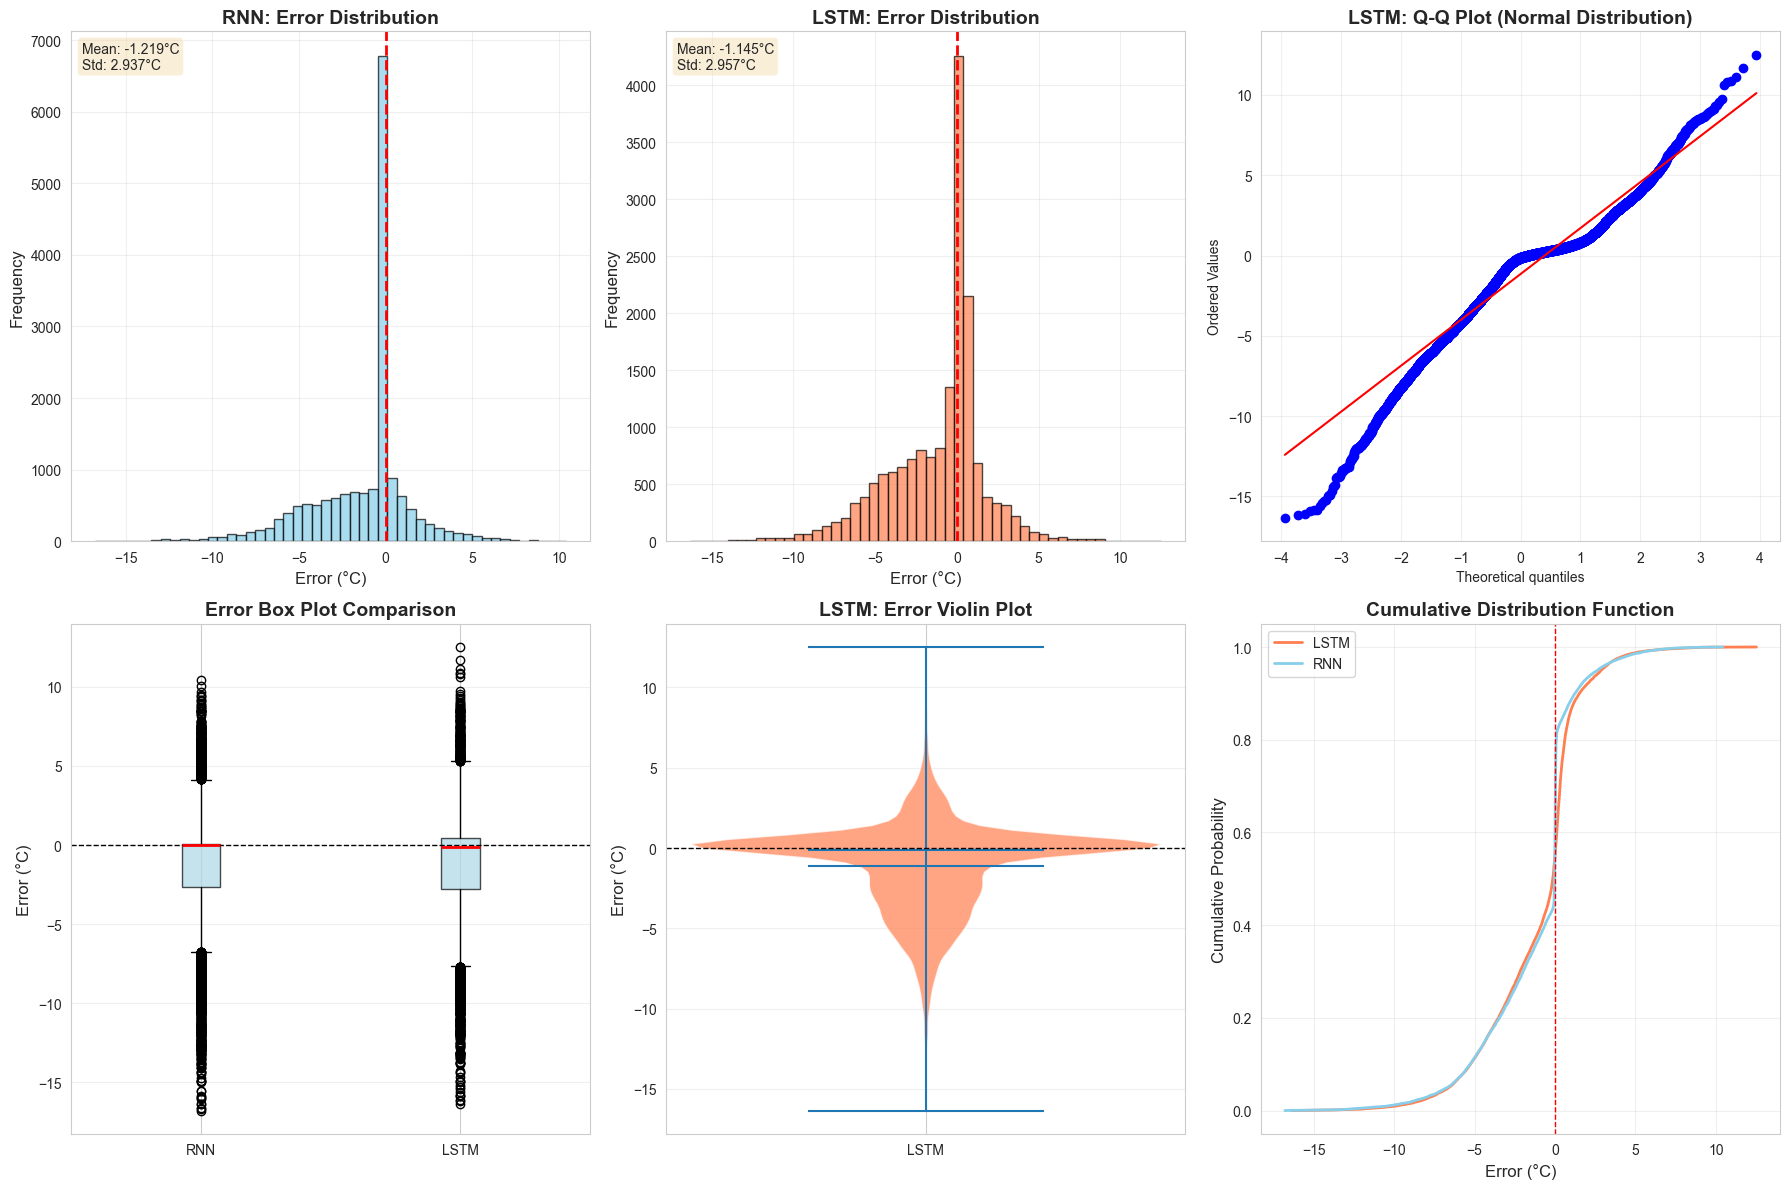


📊 THỐNG KÊ SAI SỐ:
  RNN - Mean Error: -1.219°C
  RNN - Std Error: 2.937°C
  RNN - Max Error: 16.787°C
  LSTM - Mean Error: -1.145°C
  LSTM - Std Error: 2.957°C
  LSTM - Max Error: 16.343°C


In [17]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== VISUALIZATION 3: ERROR DISTRIBUTION ====

print("\n" + "="*80)
print("📊 VISUALIZATION 3: PHÂN BỐ SAI SỐ (ERROR DISTRIBUTION)")
print("="*80)

if RESULTS_DEEP:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Collect errors
    rnn_errors = []
    lstm_errors = []
    
    for city, res in RESULTS_DEEP.items():
        if res.get("rnn_pred") is not None:
            rnn_errors.extend(res["y_true"] - res["rnn_pred"])
        lstm_errors.extend(res["y_true"] - res["lstm_pred"])
    
    # 1. Histogram - RNN
    if len(rnn_errors) > 0 and not TRAIN_LSTM_ONLY:
        ax = axes[0, 0]
        ax.hist(rnn_errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
        ax.set_xlabel('Error (°C)', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title('RNN: Error Distribution', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add statistics
        mean_err = np.mean(rnn_errors)
        std_err = np.std(rnn_errors)
        ax.text(0.02, 0.98, f'Mean: {mean_err:.3f}°C\nStd: {std_err:.3f}°C', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2. Histogram - LSTM
    ax = axes[0, 1]
    ax.hist(lstm_errors, bins=50, alpha=0.7, color='coral', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Error (°C)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('LSTM: Error Distribution', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    mean_err = np.mean(lstm_errors)
    std_err = np.std(lstm_errors)
    ax.text(0.02, 0.98, f'Mean: {mean_err:.3f}°C\nStd: {std_err:.3f}°C', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 3. Q-Q Plot - LSTM
    ax = axes[0, 2]
    from scipy import stats
    stats.probplot(lstm_errors, dist="norm", plot=ax)
    ax.set_title('LSTM: Q-Q Plot (Normal Distribution)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 4. Box Plot - Comparison
    ax = axes[1, 0]
    if len(rnn_errors) > 0 and not TRAIN_LSTM_ONLY:
        box_data = [rnn_errors, lstm_errors]
        box_labels = ['RNN', 'LSTM']
    else:
        box_data = [lstm_errors]
        box_labels = ['LSTM']
    
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2),
                     boxprops=dict(facecolor='lightblue', alpha=0.7))
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Error (°C)', fontsize=12)
    ax.set_title('Error Box Plot Comparison', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 5. Violin Plot - LSTM
    ax = axes[1, 1]
    parts = ax.violinplot([lstm_errors], positions=[1], showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor('coral')
        pc.set_alpha(0.7)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Error (°C)', fontsize=12)
    ax.set_title('LSTM: Error Violin Plot', fontsize=14, fontweight='bold')
    ax.set_xticks([1])
    ax.set_xticklabels(['LSTM'])
    ax.grid(True, alpha=0.3, axis='y')
    
    # 6. Cumulative Distribution
    ax = axes[1, 2]
    lstm_errors_sorted = np.sort(lstm_errors)
    cumulative = np.arange(1, len(lstm_errors_sorted) + 1) / len(lstm_errors_sorted)
    ax.plot(lstm_errors_sorted, cumulative, linewidth=2, color='coral', label='LSTM')
    
    if len(rnn_errors) > 0 and not TRAIN_LSTM_ONLY:
        rnn_errors_sorted = np.sort(rnn_errors)
        cumulative_rnn = np.arange(1, len(rnn_errors_sorted) + 1) / len(rnn_errors_sorted)
        ax.plot(rnn_errors_sorted, cumulative_rnn, linewidth=2, color='skyblue', label='RNN')
    
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Error (°C)', fontsize=12)
    ax.set_ylabel('Cumulative Probability', fontsize=12)
    ax.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "03_error_distribution.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Statistics
    print(f"\n📊 THỐNG KÊ SAI SỐ:")
    if len(rnn_errors) > 0 and not TRAIN_LSTM_ONLY:
        print(f"  RNN - Mean Error: {np.mean(rnn_errors):.3f}°C")
        print(f"  RNN - Std Error: {np.std(rnn_errors):.3f}°C")
        print(f"  RNN - Max Error: {np.max(np.abs(rnn_errors)):.3f}°C")
    print(f"  LSTM - Mean Error: {np.mean(lstm_errors):.3f}°C")
    print(f"  LSTM - Std Error: {np.std(lstm_errors):.3f}°C")
    print(f"  LSTM - Max Error: {np.max(np.abs(lstm_errors)):.3f}°C")
else:
    print("⚠️ Chưa có RESULTS_DEEP.")




📊 VISUALIZATION 4: PHÂN BỐ NHIỆT ĐỘ THEO VÙNG MIỀN


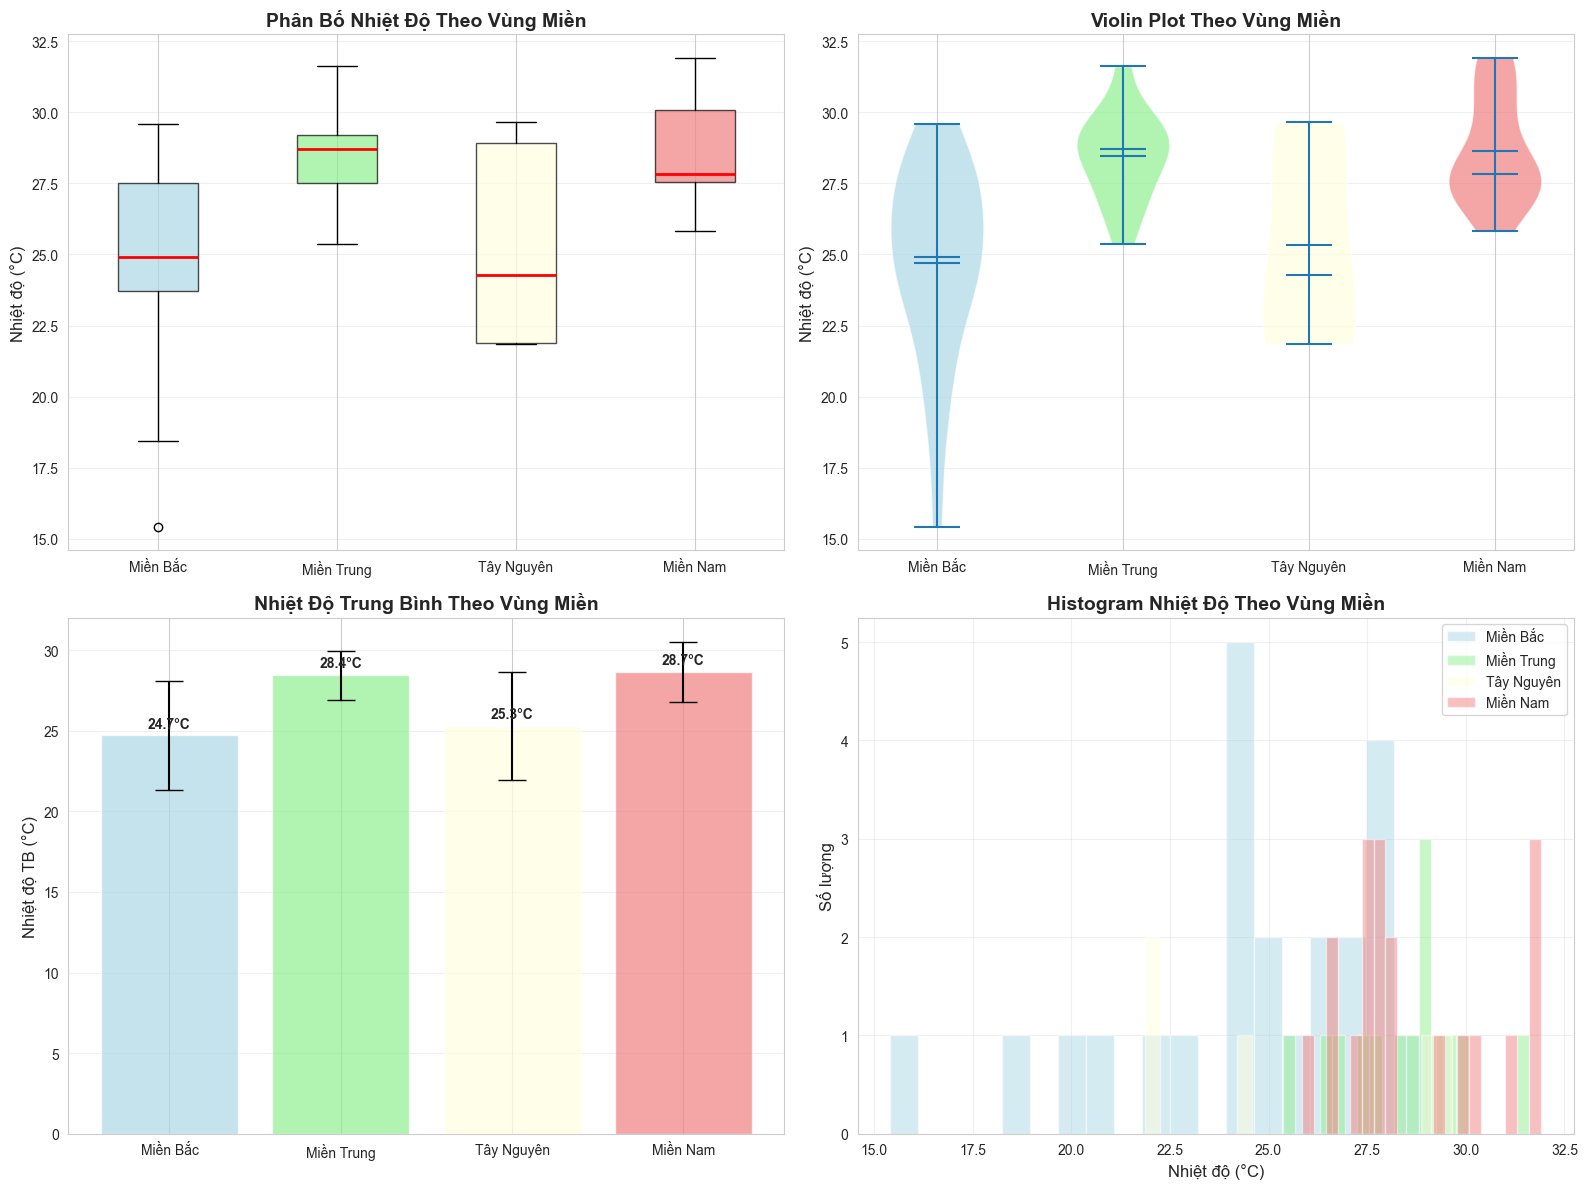


📊 THỐNG KÊ THEO VÙNG MIỀN:

Miền Bắc:
  Số tỉnh/thành: 24
  Nhiệt độ TB: 24.71°C
  Độ lệch chuẩn: 3.37°C
  Min: 15.42°C
  Max: 29.59°C

Miền Trung:
  Số tỉnh/thành: 14
  Nhiệt độ TB: 28.45°C
  Độ lệch chuẩn: 1.53°C
  Min: 25.37°C
  Max: 31.61°C

Tây Nguyên:
  Số tỉnh/thành: 5
  Nhiệt độ TB: 25.32°C
  Độ lệch chuẩn: 3.36°C
  Min: 21.87°C
  Max: 29.64°C

Miền Nam:
  Số tỉnh/thành: 19
  Nhiệt độ TB: 28.65°C
  Độ lệch chuẩn: 1.85°C
  Min: 25.84°C
  Max: 31.91°C


In [18]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== VISUALIZATION 4: PHÂN BỐ NHIỆT ĐỘ THEO VÙNG MIỀN ====

print("\n" + "="*80)
print("📊 VISUALIZATION 4: PHÂN BỐ NHIỆT ĐỘ THEO VÙNG MIỀN")
print("="*80)

if 'forecast_7days_lstm' in globals() and len(forecast_7days_lstm) > 0:
    # Phân loại theo vùng miền
    mien_bac = ['Hà Nội', 'Hải Phòng', 'Hà Nam', 'Hà Giang', 'Bắc Giang', 'Bắc Kạn', 'Bắc Ninh',
                'Cao Bằng', 'Lạng Sơn', 'Lào Cai', 'Điện Biên', 'Lai Châu', 'Sơn La', 'Hòa Bình',
                'Yên Bái', 'Thái Nguyên', 'Tuyên Quang', 'Phú Thọ', 'Vĩnh Phúc', 'Hải Dương',
                'Hưng Yên', 'Thái Bình', 'Nam Định', 'Ninh Bình']
    
    mien_trung = ['Thanh Hóa', 'Nghệ An', 'Hà Tĩnh', 'Quảng Bình', 'Quảng Trị', 'Thừa Thiên-Huế',
                  'Đà Nẵng', 'Quảng Nam', 'Quảng Ngãi', 'Bình Định', 'Phú Yên', 'Khánh Hòa',
                  'Ninh Thuận', 'Bình Thuận']
    
    tay_nguyen = ['Kon Tum', 'Gia Lai', 'Đắk Lắk', 'Đắk Nông', 'Lâm Đồng']
    
    mien_nam = ['Ho Chi Minh City', 'Bình Phước', 'Tây Ninh', 'Bình Dương', 'Đồng Nai', 
                'Bà Rịa-Vũng Tàu', 'Long An', 'Tiền Giang', 'Bến Tre', 'Trà Vinh', 'Vĩnh Long',
                'Đồng Tháp', 'An Giang', 'Kiên Giang', 'Cần Thơ', 'Hậu Giang', 'Sóc Trăng',
                'Bạc Liêu', 'Cà Mau']
    
    # Collect data by region
    regions_data = {
        'Miền Bắc': [],
        'Miền Trung': [],
        'Tây Nguyên': [],
        'Miền Nam': []
    }
    
    for city, temp in forecast_7days_lstm.items():
        if city in mien_bac:
            regions_data['Miền Bắc'].append(temp)
        elif city in mien_trung:
            regions_data['Miền Trung'].append(temp)
        elif city in tay_nguyen:
            regions_data['Tây Nguyên'].append(temp)
        elif city in mien_nam:
            regions_data['Miền Nam'].append(temp)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Box Plot by Region
    ax = axes[0, 0]
    box_data = [regions_data[r] for r in regions_data.keys() if len(regions_data[r]) > 0]
    box_labels = [r for r in regions_data.keys() if len(regions_data[r]) > 0]
    
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
    colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Nhiệt độ (°C)', fontsize=12)
    ax.set_title('Phân Bố Nhiệt Độ Theo Vùng Miền', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. Violin Plot by Region
    ax = axes[0, 1]
    positions = range(1, len(box_data) + 1)
    parts = ax.violinplot(box_data, positions=positions, showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
    
    ax.set_xticks(positions)
    ax.set_xticklabels(box_labels)
    ax.set_ylabel('Nhiệt độ (°C)', fontsize=12)
    ax.set_title('Violin Plot Theo Vùng Miền', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Bar Chart - Average by Region
    ax = axes[1, 0]
    avg_temps = [np.mean(regions_data[r]) for r in box_labels]
    std_temps = [np.std(regions_data[r]) for r in box_labels]
    
    bars = ax.bar(range(len(box_labels)), avg_temps, yerr=std_temps, 
                   color=colors[:len(box_labels)], alpha=0.7, capsize=10)
    ax.set_xticks(range(len(box_labels)))
    ax.set_xticklabels(box_labels)
    ax.set_ylabel('Nhiệt độ TB (°C)', fontsize=12)
    ax.set_title('Nhiệt Độ Trung Bình Theo Vùng Miền', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, avg) in enumerate(zip(bars, avg_temps)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{avg:.1f}°C', ha='center', va='bottom', fontweight='bold')
    
    # 4. Histogram - All Regions
    ax = axes[1, 1]
    for i, region in enumerate(box_labels):
        ax.hist(regions_data[region], bins=20, alpha=0.5, label=region, color=colors[i])
    
    ax.set_xlabel('Nhiệt độ (°C)', fontsize=12)
    ax.set_ylabel('Số lượng', fontsize=12)
    ax.set_title('Histogram Nhiệt Độ Theo Vùng Miền', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "04_regional_temperature_distribution.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print(f"\n📊 THỐNG KÊ THEO VÙNG MIỀN:")
    for region in box_labels:
        temps = regions_data[region]
        print(f"\n{region}:")
        print(f"  Số tỉnh/thành: {len(temps)}")
        print(f"  Nhiệt độ TB: {np.mean(temps):.2f}°C")
        print(f"  Độ lệch chuẩn: {np.std(temps):.2f}°C")
        print(f"  Min: {np.min(temps):.2f}°C")
        print(f"  Max: {np.max(temps):.2f}°C")
else:
    print("⚠️ Chưa có dữ liệu dự báo.")




📊 VISUALIZATION 5: TIME SERIES - DỰ BÁO 7 NGÀY


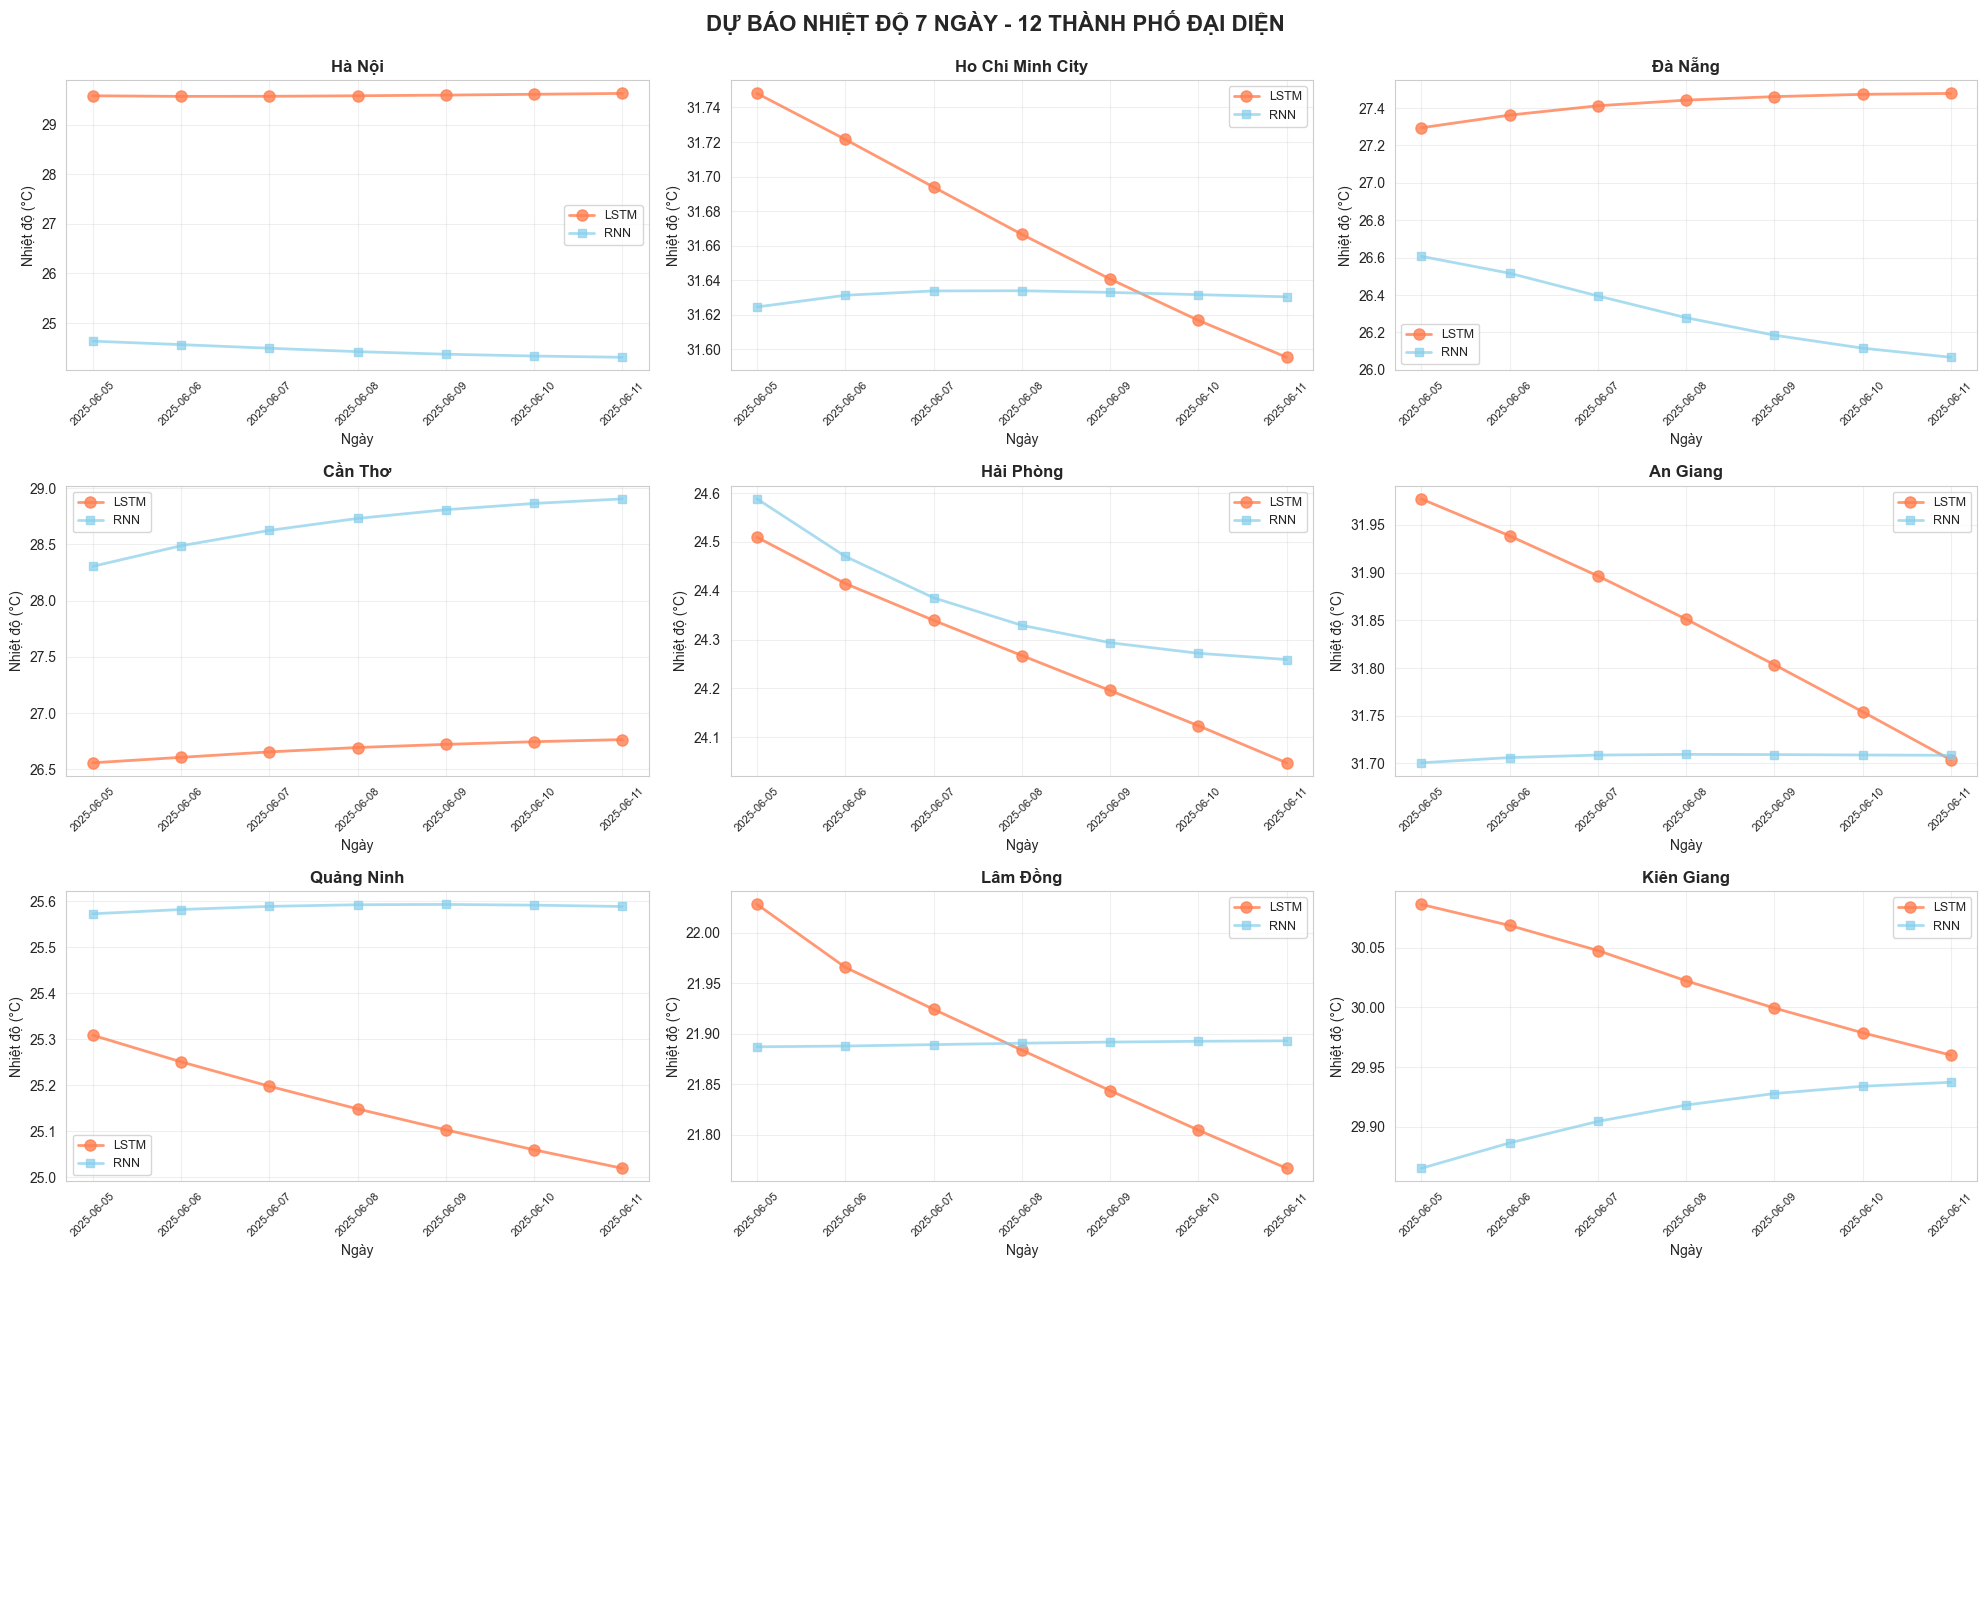

✓ Đã vẽ time series cho 9 thành phố


In [19]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== VISUALIZATION 5: TIME SERIES - DỰ BÁO 7 NGÀY CHO NHIỀU THÀNH PHỐ ====

print("\n" + "="*80)
print("📊 VISUALIZATION 5: TIME SERIES - DỰ BÁO 7 NGÀY")
print("="*80)

if FORECASTS_DEEP and len(FORECASTS_DEEP) > 0:
    # Chọn 12 thành phố đại diện
    selected_cities = ['Hà Nội', 'Ho Chi Minh City', 'Đà Nẵng', 'Cần Thơ', 
                       'Hải Phòng', 'Nha Trang', 'Đà Lạt', 'Huế',
                       'An Giang', 'Quảng Ninh', 'Lâm Đồng', 'Kiên Giang']
    
    fig, axes = plt.subplots(4, 3, figsize=(20, 16))
    axes = axes.flatten()
    
    plot_idx = 0
    for city in selected_cities:
        if city in FORECASTS_DEEP and plot_idx < 12:
            forecasts = FORECASTS_DEEP[city]
            ax = axes[plot_idx]
            
            # Plot LSTM
            if 'lstm' in forecasts and forecasts['lstm']['df'] is not None:
                df_lstm = forecasts['lstm']['df']
                ax.plot(df_lstm['date'], df_lstm['pred_tavg'], 
                       marker='o', linewidth=2, markersize=8, 
                       color='coral', label='LSTM', alpha=0.8)
            
            # Plot RNN
            if 'rnn' in forecasts and forecasts['rnn']['df'] is not None:
                df_rnn = forecasts['rnn']['df']
                ax.plot(df_rnn['date'], df_rnn['pred_tavg'], 
                       marker='s', linewidth=2, markersize=6, 
                       color='skyblue', label='RNN', alpha=0.7)
            
            ax.set_title(f'{city}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Ngày', fontsize=10)
            ax.set_ylabel('Nhiệt độ (°C)', fontsize=10)
            ax.legend(loc='best', fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            
            plot_idx += 1
    
    # Hide unused subplots
    for i in range(plot_idx, 12):
        axes[i].axis('off')
    
    plt.suptitle('DỰ BÁO NHIỆT ĐỘ 7 NGÀY - 12 THÀNH PHỐ ĐẠI DIỆN', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "05_time_series_forecast_7days.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Đã vẽ time series cho {plot_idx} thành phố")
else:
    print("⚠️ Chưa có dữ liệu dự báo.")




📊 VISUALIZATION 6: HEATMAP - NHIỆT ĐỘ DỰ BÁO


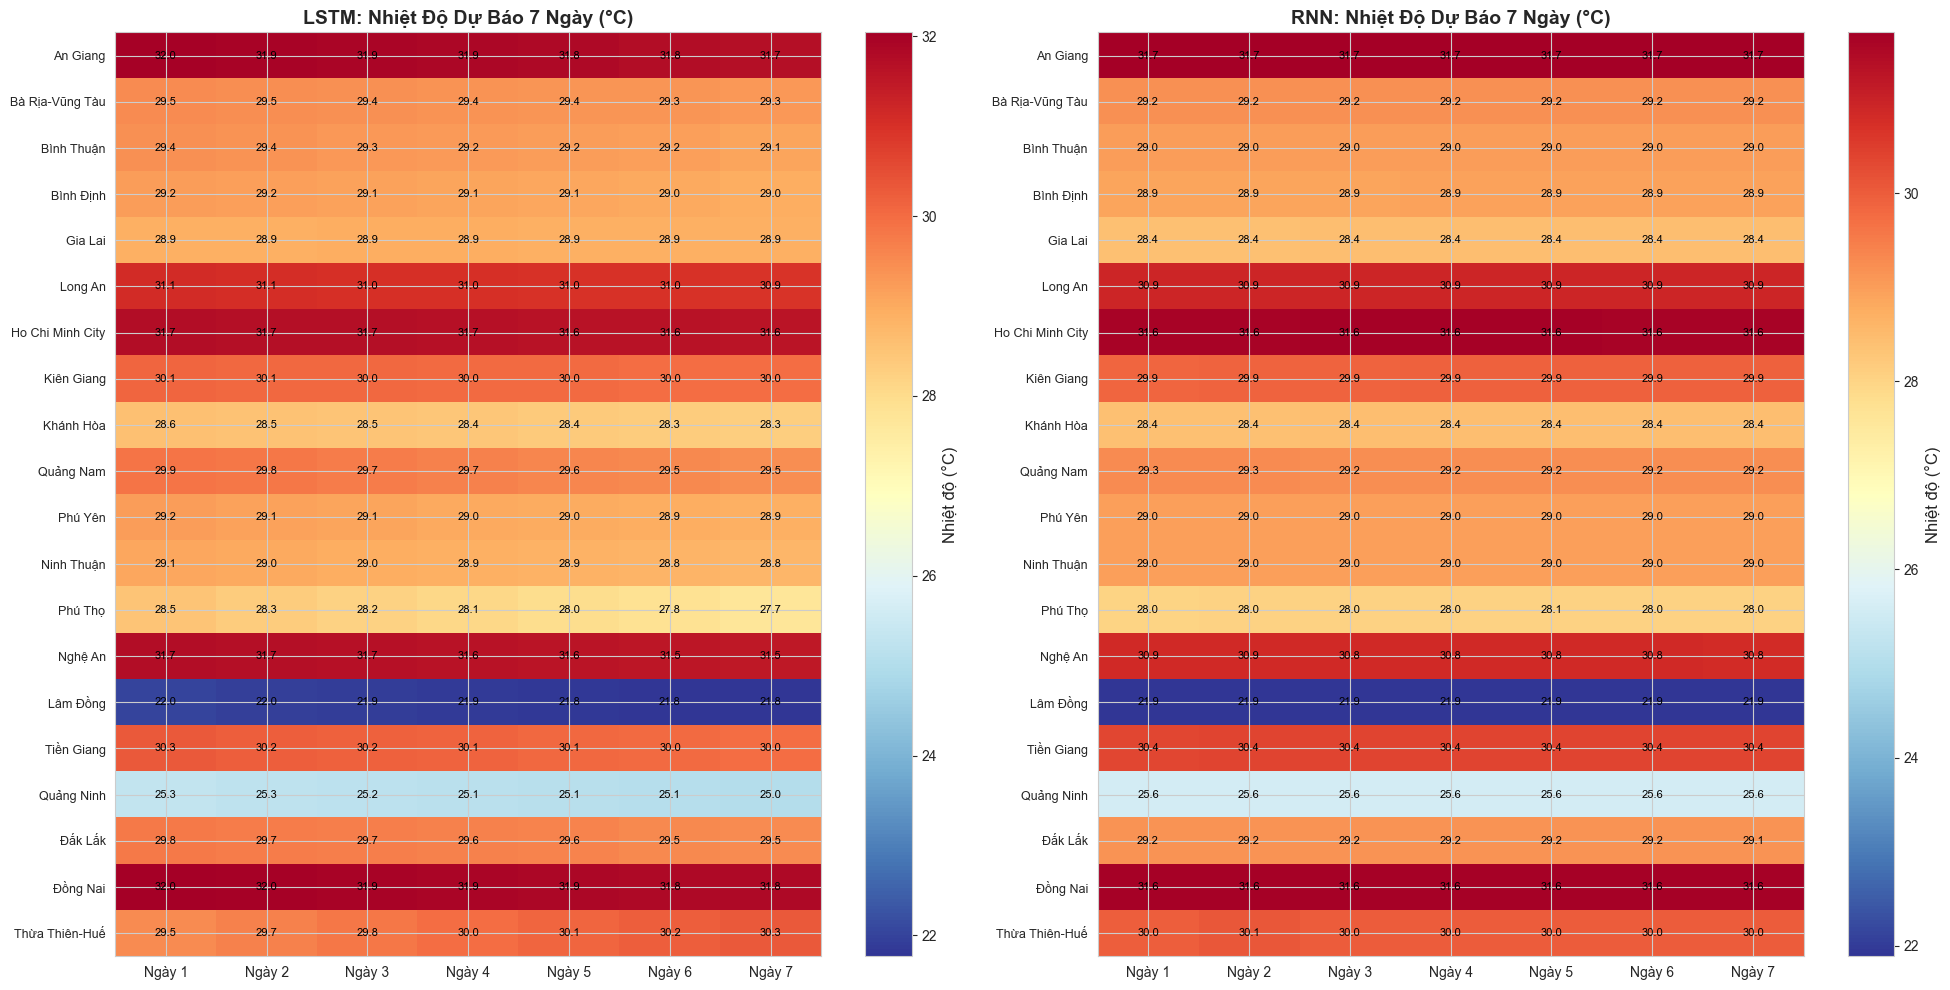

✓ Đã vẽ heatmap cho 20 thành phố


In [20]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== VISUALIZATION 6: HEATMAP - NHIỆT ĐỘ DỰ BÁO THEO THÀNH PHỐ VÀ NGÀY ====

print("\n" + "="*80)
print("📊 VISUALIZATION 6: HEATMAP - NHIỆT ĐỘ DỰ BÁO")
print("="*80)

if FORECASTS_DEEP and len(FORECASTS_DEEP) > 0:
    # Chọn 20 thành phố để hiển thị
    selected_cities = list(FORECASTS_DEEP.keys())[:20]
    
    # Create matrix for LSTM
    lstm_matrix = []
    cities_with_data = []
    
    for city in selected_cities:
        if city in FORECASTS_DEEP and 'lstm' in FORECASTS_DEEP[city]:
            df_lstm = FORECASTS_DEEP[city]['lstm']['df']
            if df_lstm is not None and len(df_lstm) == 7:
                lstm_matrix.append(df_lstm['pred_tavg'].values)
                cities_with_data.append(city)
    
    if len(lstm_matrix) > 0:
        lstm_matrix = np.array(lstm_matrix)
        
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))
        
        # LSTM Heatmap
        ax = axes[0]
        im = ax.imshow(lstm_matrix, cmap='RdYlBu_r', aspect='auto')
        ax.set_xticks(range(7))
        ax.set_xticklabels([f'Ngày {i+1}' for i in range(7)])
        ax.set_yticks(range(len(cities_with_data)))
        ax.set_yticklabels(cities_with_data, fontsize=9)
        ax.set_title('LSTM: Nhiệt Độ Dự Báo 7 Ngày (°C)', fontsize=14, fontweight='bold')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Nhiệt độ (°C)', fontsize=12)
        
        # Add text annotations
        for i in range(len(cities_with_data)):
            for j in range(7):
                text = ax.text(j, i, f'{lstm_matrix[i, j]:.1f}',
                              ha="center", va="center", color="black", fontsize=8)
        
        # RNN Heatmap (if available)
        if not TRAIN_LSTM_ONLY:
            rnn_matrix = []
            for city in cities_with_data:
                if 'rnn' in FORECASTS_DEEP[city]:
                    df_rnn = FORECASTS_DEEP[city]['rnn']['df']
                    if df_rnn is not None and len(df_rnn) == 7:
                        rnn_matrix.append(df_rnn['pred_tavg'].values)
            
            if len(rnn_matrix) > 0:
                rnn_matrix = np.array(rnn_matrix)
                ax = axes[1]
                im = ax.imshow(rnn_matrix, cmap='RdYlBu_r', aspect='auto')
                ax.set_xticks(range(7))
                ax.set_xticklabels([f'Ngày {i+1}' for i in range(7)])
                ax.set_yticks(range(len(cities_with_data)))
                ax.set_yticklabels(cities_with_data, fontsize=9)
                ax.set_title('RNN: Nhiệt Độ Dự Báo 7 Ngày (°C)', fontsize=14, fontweight='bold')
                
                cbar = plt.colorbar(im, ax=ax)
                cbar.set_label('Nhiệt độ (°C)', fontsize=12)
                
                for i in range(len(cities_with_data)):
                    for j in range(7):
                        text = ax.text(j, i, f'{rnn_matrix[i, j]:.1f}',
                                      ha="center", va="center", color="black", fontsize=8)
            else:
                axes[1].axis('off')
        else:
            axes[1].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, "06_heatmap_forecast.png"), dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✓ Đã vẽ heatmap cho {len(cities_with_data)} thành phố")
    else:
        print("⚠️ Không đủ dữ liệu để vẽ heatmap")
else:
    print("⚠️ Chưa có dữ liệu dự báo.")




📊 VISUALIZATION 7: RESIDUAL PLOT VÀ PERFORMANCE METRICS


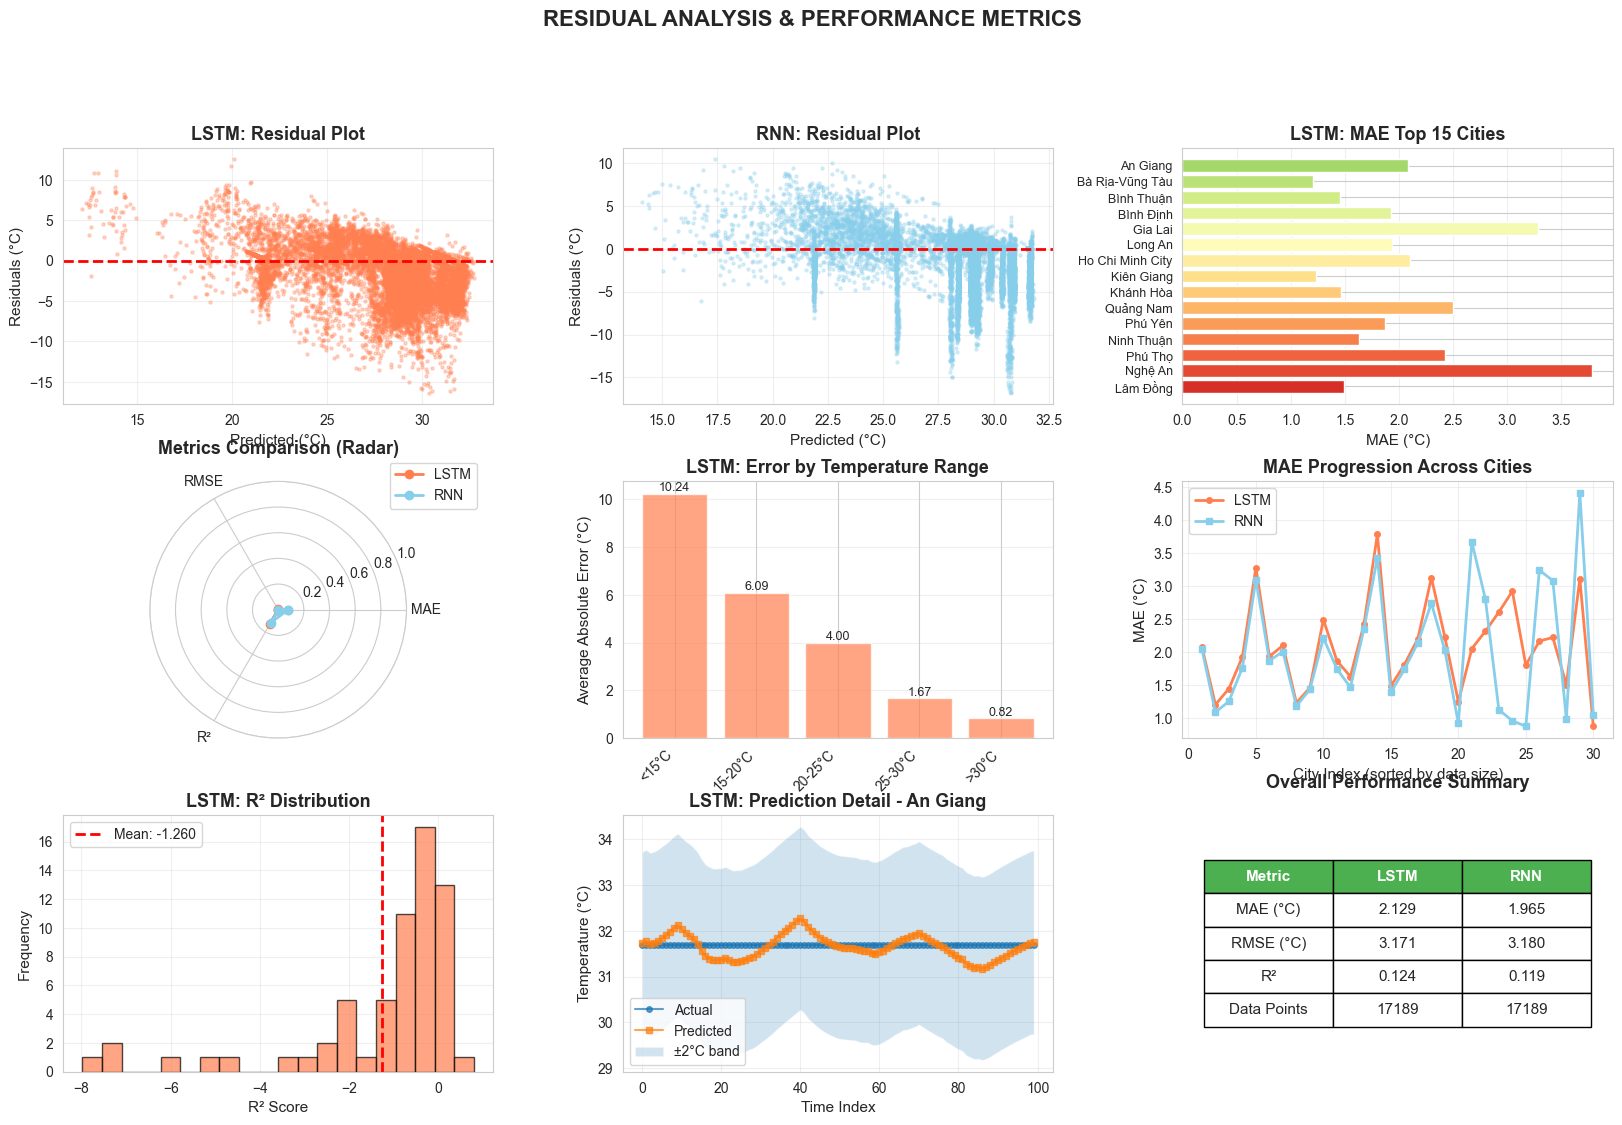

✓ Đã hoàn thành residual analysis và performance metrics


In [21]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== VISUALIZATION 7: RESIDUAL PLOT VÀ PERFORMANCE METRICS ====

print("\n" + "="*80)
print("📊 VISUALIZATION 7: RESIDUAL PLOT VÀ PERFORMANCE METRICS")
print("="*80)

if RESULTS_DEEP:
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Collect all data
    all_actual = []
    all_lstm_pred = []
    all_rnn_pred = []
    
    for city, res in RESULTS_DEEP.items():
        all_actual.extend(res["y_true"])
        all_lstm_pred.extend(res["lstm_pred"])
        if res.get("rnn_pred") is not None:
            all_rnn_pred.extend(res["rnn_pred"])
    
    all_actual = np.array(all_actual)
    all_lstm_pred = np.array(all_lstm_pred)
    
    # 1. Residual Plot - LSTM
    ax1 = fig.add_subplot(gs[0, 0])
    lstm_residuals = all_actual - all_lstm_pred
    ax1.scatter(all_lstm_pred, lstm_residuals, alpha=0.3, s=5, color='coral')
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax1.set_xlabel('Predicted (°C)', fontsize=11)
    ax1.set_ylabel('Residuals (°C)', fontsize=11)
    ax1.set_title('LSTM: Residual Plot', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 2. Residual Plot - RNN
    if len(all_rnn_pred) > 0 and not TRAIN_LSTM_ONLY:
        ax2 = fig.add_subplot(gs[0, 1])
        all_rnn_pred = np.array(all_rnn_pred)
        rnn_residuals = all_actual - all_rnn_pred
        ax2.scatter(all_rnn_pred, rnn_residuals, alpha=0.3, s=5, color='skyblue')
        ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
        ax2.set_xlabel('Predicted (°C)', fontsize=11)
        ax2.set_ylabel('Residuals (°C)', fontsize=11)
        ax2.set_title('RNN: Residual Plot', fontsize=13, fontweight='bold')
        ax2.grid(True, alpha=0.3)
    
    # 3. MAE by City (Top 15)
    ax3 = fig.add_subplot(gs[0, 2])
    cities = []
    maes = []
    for city, res in list(RESULTS_DEEP.items())[:15]:
        cities.append(city)
        maes.append(res["lstm_metrics"]["MAE"])
    
    colors_grad = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(cities)))
    bars = ax3.barh(range(len(cities)), maes, color=colors_grad)
    ax3.set_yticks(range(len(cities)))
    ax3.set_yticklabels(cities, fontsize=9)
    ax3.set_xlabel('MAE (°C)', fontsize=11)
    ax3.set_title('LSTM: MAE Top 15 Cities', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='x')
    ax3.invert_yaxis()
    
    # 4. Metrics Comparison Radar Chart
    if len(all_rnn_pred) > 0 and not TRAIN_LSTM_ONLY:
        ax4 = fig.add_subplot(gs[1, 0], projection='polar')
        
        # Calculate metrics
        lstm_mae = mean_absolute_error(all_actual, all_lstm_pred)
        lstm_rmse = np.sqrt(mean_squared_error(all_actual, all_lstm_pred))
        lstm_r2 = r2_score(all_actual, all_lstm_pred)
        
        rnn_mae = mean_absolute_error(all_actual, all_rnn_pred)
        rnn_rmse = np.sqrt(mean_squared_error(all_actual, all_rnn_pred))
        rnn_r2 = r2_score(all_actual, all_rnn_pred)
        
        # Normalize metrics (0-1 scale, lower is better for MAE/RMSE)
        max_mae = max(lstm_mae, rnn_mae)
        max_rmse = max(lstm_rmse, rnn_rmse)
        
        categories = ['MAE', 'RMSE', 'R²']
        lstm_values = [1 - lstm_mae/max_mae, 1 - lstm_rmse/max_rmse, lstm_r2]
        rnn_values = [1 - rnn_mae/max_mae, 1 - rnn_rmse/max_rmse, rnn_r2]
        
        angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
        lstm_values += lstm_values[:1]
        rnn_values += rnn_values[:1]
        angles += angles[:1]
        
        ax4.plot(angles, lstm_values, 'o-', linewidth=2, label='LSTM', color='coral')
        ax4.fill(angles, lstm_values, alpha=0.25, color='coral')
        ax4.plot(angles, rnn_values, 'o-', linewidth=2, label='RNN', color='skyblue')
        ax4.fill(angles, rnn_values, alpha=0.25, color='skyblue')
        
        ax4.set_xticks(angles[:-1])
        ax4.set_xticklabels(categories)
        ax4.set_ylim(0, 1)
        ax4.set_title('Metrics Comparison (Radar)', fontsize=13, fontweight='bold', pad=20)
        ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
        ax4.grid(True)
    
    # 5. Error by Temperature Range
    ax5 = fig.add_subplot(gs[1, 1])
    
    # Bin temperatures
    temp_bins = [0, 15, 20, 25, 30, 50]
    temp_labels = ['<15°C', '15-20°C', '20-25°C', '25-30°C', '>30°C']
    
    binned_errors = {label: [] for label in temp_labels}
    for actual, pred in zip(all_actual, all_lstm_pred):
        error = abs(actual - pred)
        for i, (low, high) in enumerate(zip(temp_bins[:-1], temp_bins[1:])):
            if low <= actual < high:
                binned_errors[temp_labels[i]].append(error)
                break
    
    avg_errors = [np.mean(binned_errors[label]) if len(binned_errors[label]) > 0 else 0 
                  for label in temp_labels]
    
    bars = ax5.bar(range(len(temp_labels)), avg_errors, color='coral', alpha=0.7)
    ax5.set_xticks(range(len(temp_labels)))
    ax5.set_xticklabels(temp_labels, rotation=45, ha='right')
    ax5.set_ylabel('Average Absolute Error (°C)', fontsize=11)
    ax5.set_title('LSTM: Error by Temperature Range', fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    # 6. Learning Curve Simulation
    ax6 = fig.add_subplot(gs[1, 2])
    
    # Get metrics by city (as proxy for learning progression)
    sorted_cities = sorted(RESULTS_DEEP.items(), 
                          key=lambda x: len(CITY_DATA.get(x[0], {}).get('X_tr', [])), 
                          reverse=True)
    
    cumulative_mae_lstm = []
    cumulative_mae_rnn = []
    data_points = []
    
    for i, (city, res) in enumerate(sorted_cities[:30]):
        cumulative_mae_lstm.append(res["lstm_metrics"]["MAE"])
        if res.get("rnn_metrics"):
            cumulative_mae_rnn.append(res["rnn_metrics"]["MAE"])
        data_points.append(i + 1)
    
    ax6.plot(data_points, cumulative_mae_lstm, marker='o', linewidth=2, 
            label='LSTM', color='coral', markersize=4)
    if len(cumulative_mae_rnn) > 0:
        ax6.plot(data_points, cumulative_mae_rnn, marker='s', linewidth=2, 
                label='RNN', color='skyblue', markersize=4)
    
    ax6.set_xlabel('City Index (sorted by data size)', fontsize=11)
    ax6.set_ylabel('MAE (°C)', fontsize=11)
    ax6.set_title('MAE Progression Across Cities', fontsize=13, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # 7. R² Distribution
    ax7 = fig.add_subplot(gs[2, 0])
    
    lstm_r2s = [res["lstm_metrics"]["R2"] for res in RESULTS_DEEP.values()]
    ax7.hist(lstm_r2s, bins=20, alpha=0.7, color='coral', edgecolor='black')
    ax7.axvline(x=np.mean(lstm_r2s), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(lstm_r2s):.3f}')
    ax7.set_xlabel('R² Score', fontsize=11)
    ax7.set_ylabel('Frequency', fontsize=11)
    ax7.set_title('LSTM: R² Distribution', fontsize=13, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # 8. Prediction Confidence Intervals
    ax8 = fig.add_subplot(gs[2, 1])
    
    # Sample one city for detailed view
    sample_city = list(RESULTS_DEEP.keys())[0]
    sample_res = RESULTS_DEEP[sample_city]
    
    idx = range(min(100, len(sample_res["y_true"])))
    y_true = sample_res["y_true"][:100]
    y_pred = sample_res["lstm_pred"][:100]
    
    ax8.plot(idx, y_true, 'o-', label='Actual', alpha=0.7, markersize=4, linewidth=1.5)
    ax8.plot(idx, y_pred, 's-', label='Predicted', alpha=0.7, markersize=4, linewidth=1.5)
    ax8.fill_between(idx, y_pred - 2, y_pred + 2, alpha=0.2, label='±2°C band')
    
    ax8.set_xlabel('Time Index', fontsize=11)
    ax8.set_ylabel('Temperature (°C)', fontsize=11)
    ax8.set_title(f'LSTM: Prediction Detail - {sample_city}', fontsize=13, fontweight='bold')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    # 9. Summary Statistics Table
    ax9 = fig.add_subplot(gs[2, 2])
    ax9.axis('off')
    
    # Calculate overall statistics
    stats_data = [
        ['Metric', 'LSTM', 'RNN' if len(all_rnn_pred) > 0 else 'N/A'],
        ['MAE (°C)', f'{mean_absolute_error(all_actual, all_lstm_pred):.3f}',
         f'{mean_absolute_error(all_actual, all_rnn_pred):.3f}' if len(all_rnn_pred) > 0 else 'N/A'],
        ['RMSE (°C)', f'{np.sqrt(mean_squared_error(all_actual, all_lstm_pred)):.3f}',
         f'{np.sqrt(mean_squared_error(all_actual, all_rnn_pred)):.3f}' if len(all_rnn_pred) > 0 else 'N/A'],
        ['R²', f'{r2_score(all_actual, all_lstm_pred):.3f}',
         f'{r2_score(all_actual, all_rnn_pred):.3f}' if len(all_rnn_pred) > 0 else 'N/A'],
        ['Data Points', f'{len(all_actual)}', f'{len(all_rnn_pred) if len(all_rnn_pred) > 0 else "N/A"}']
    ]
    
    table = ax9.table(cellText=stats_data, cellLoc='center', loc='center',
                      colWidths=[0.3, 0.3, 0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)
    
    # Color header
    for i in range(3):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax9.set_title('Overall Performance Summary', fontsize=13, fontweight='bold', pad=20)
    
    plt.suptitle('RESIDUAL ANALYSIS & PERFORMANCE METRICS', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.savefig(os.path.join(SAVE_DIR, "07_residual_performance.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Đã hoàn thành residual analysis và performance metrics")
else:
    print("⚠️ Chưa có RESULTS_DEEP.")




📊 VISUALIZATION 8: TỔNG HỢP VISUALIZATION

✅ DANH SÁCH CÁC FILE VISUALIZATION ĐÃ TẠO:

📁 Thư mục lưu: D:\case_study_4\sub

1. ✓ 01_rnn_lstm_comparison.png
   └─ So sánh RNN vs LSTM chi tiết (4 subplots)

2. ✓ 02_scatter_actual_vs_predicted.png
   └─ Scatter plot Actual vs Predicted

3. ✓ 03_error_distribution.png
   └─ Phân bố sai số (6 subplots)

4. ✓ 04_regional_temperature_distribution.png
   └─ Phân bố nhiệt độ theo vùng miền

5. ✓ 05_time_series_forecast_7days.png
   └─ Time series 7 ngày - 12 thành phố

6. ✓ 06_heatmap_forecast.png
   └─ Heatmap nhiệt độ dự báo

7. ✓ 07_residual_performance.png
   └─ Residual plot & Performance (9 subplots)

8. ✗ vietnam_temp_forecast_7days_RNN.png
   └─ Bản đồ dự báo RNN

9. ✗ vietnam_temp_forecast_7days_LSTM.png
   └─ Bản đồ dự báo LSTM


📈 THỐNG KÊ TỔNG HỢP

🎯 Số thành phố đã train: 63
🎯 Số tỉnh/thành có dự báo: 63

📊 LSTM Performance:
   - MAE trung bình: 2.404°C
   - MAE tốt nhất: 0.880°C
   - MAE kém nhất: 6.717°C
   - RMSE trung bình: 2.9

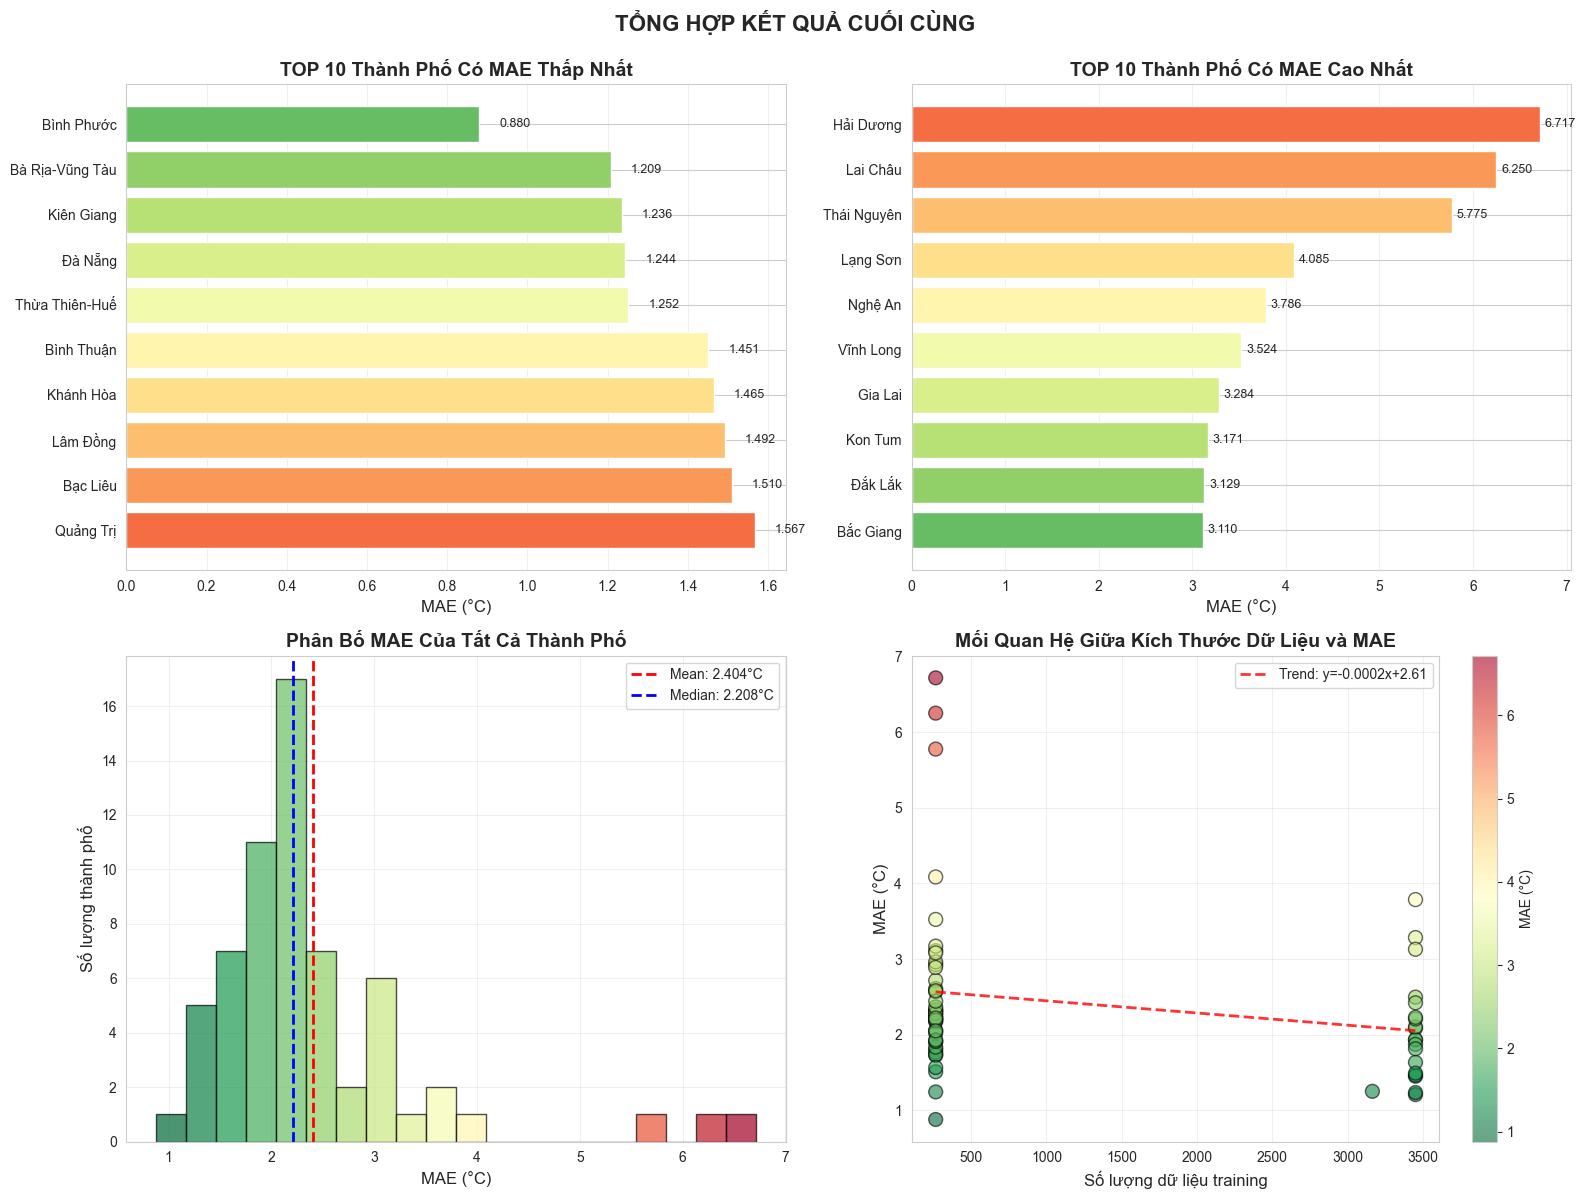


✓ Đã lưu tổng hợp cuối cùng: 08_final_summary.png

🎉 HOÀN THÀNH TẤT CẢ VISUALIZATION!

📁 Tất cả file đã được lưu vào: D:\case_study_4\sub
📊 Tổng số file visualization: 10


In [22]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== VISUALIZATION 8: TỔNG HỢP CUỐI CÙNG ====

print("\n" + "="*80)
print("📊 VISUALIZATION 8: TỔNG HỢP VISUALIZATION")
print("="*80)

# Tạo tổng hợp các file visualization đã tạo
print("\n✅ DANH SÁCH CÁC FILE VISUALIZATION ĐÃ TẠO:")
print("="*80)

viz_files = [
    ("01_rnn_lstm_comparison.png", "So sánh RNN vs LSTM chi tiết (4 subplots)"),
    ("02_scatter_actual_vs_predicted.png", "Scatter plot Actual vs Predicted"),
    ("03_error_distribution.png", "Phân bố sai số (6 subplots)"),
    ("04_regional_temperature_distribution.png", "Phân bố nhiệt độ theo vùng miền"),
    ("05_time_series_forecast_7days.png", "Time series 7 ngày - 12 thành phố"),
    ("06_heatmap_forecast.png", "Heatmap nhiệt độ dự báo"),
    ("07_residual_performance.png", "Residual plot & Performance (9 subplots)"),
    ("vietnam_temp_forecast_7days_RNN.png", "Bản đồ dự báo RNN"),
    ("vietnam_temp_forecast_7days_LSTM.png", "Bản đồ dự báo LSTM")
]

print(f"\n📁 Thư mục lưu: {SAVE_DIR}\n")

for i, (filename, description) in enumerate(viz_files, 1):
    filepath = os.path.join(SAVE_DIR, filename)
    exists = "✓" if os.path.exists(filepath) else "✗"
    print(f"{i}. {exists} {filename}")
    print(f"   └─ {description}\n")

# Thống kê tổng hợp
print("\n" + "="*80)
print("📈 THỐNG KÊ TỔNG HỢP")
print("="*80)

if RESULTS_DEEP:
    print(f"\n🎯 Số thành phố đã train: {len(RESULTS_DEEP)}")
    print(f"🎯 Số tỉnh/thành có dự báo: {len(FORECASTS_DEEP) if 'FORECASTS_DEEP' in globals() else 0}")
    
    # Calculate overall statistics
    all_lstm_maes = [res["lstm_metrics"]["MAE"] for res in RESULTS_DEEP.values()]
    all_lstm_rmses = [res["lstm_metrics"]["RMSE"] for res in RESULTS_DEEP.values()]
    all_lstm_r2s = [res["lstm_metrics"]["R2"] for res in RESULTS_DEEP.values()]
    
    print(f"\n📊 LSTM Performance:")
    print(f"   - MAE trung bình: {np.mean(all_lstm_maes):.3f}°C")
    print(f"   - MAE tốt nhất: {np.min(all_lstm_maes):.3f}°C")
    print(f"   - MAE kém nhất: {np.max(all_lstm_maes):.3f}°C")
    print(f"   - RMSE trung bình: {np.mean(all_lstm_rmses):.3f}°C")
    print(f"   - R² trung bình: {np.mean(all_lstm_r2s):.3f}")
    
    if not TRAIN_LSTM_ONLY:
        all_rnn_maes = [res["rnn_metrics"]["MAE"] for res in RESULTS_DEEP.values() 
                        if res.get("rnn_metrics")]
        if len(all_rnn_maes) > 0:
            print(f"\n📊 RNN Performance:")
            print(f"   - MAE trung bình: {np.mean(all_rnn_maes):.3f}°C")
            print(f"   - MAE tốt nhất: {np.min(all_rnn_maes):.3f}°C")
            print(f"   - MAE kém nhất: {np.max(all_rnn_maes):.3f}°C")
            
            improvement = (np.mean(all_rnn_maes) - np.mean(all_lstm_maes)) / np.mean(all_rnn_maes) * 100
            print(f"\n🏆 LSTM cải thiện: {improvement:.2f}% so với RNN")

# Tạo summary figure
if RESULTS_DEEP:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Top 10 Best Cities
    ax = axes[0, 0]
    sorted_results = sorted(RESULTS_DEEP.items(), 
                           key=lambda x: x[1]["lstm_metrics"]["MAE"])[:10]
    cities = [city for city, _ in sorted_results]
    maes = [res["lstm_metrics"]["MAE"] for _, res in sorted_results]
    
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(cities)))
    bars = ax.barh(range(len(cities)), maes, color=colors)
    ax.set_yticks(range(len(cities)))
    ax.set_yticklabels(cities, fontsize=10)
    ax.set_xlabel('MAE (°C)', fontsize=12)
    ax.set_title('TOP 10 Thành Phố Có MAE Thấp Nhất', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    for i, (bar, mae) in enumerate(zip(bars, maes)):
        ax.text(mae + 0.05, i, f'{mae:.3f}', va='center', fontsize=9)
    
    # 2. Top 10 Worst Cities
    ax = axes[0, 1]
    sorted_results = sorted(RESULTS_DEEP.items(), 
                           key=lambda x: x[1]["lstm_metrics"]["MAE"], reverse=True)[:10]
    cities = [city for city, _ in sorted_results]
    maes = [res["lstm_metrics"]["MAE"] for _, res in sorted_results]
    
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(cities)))
    bars = ax.barh(range(len(cities)), maes, color=colors)
    ax.set_yticks(range(len(cities)))
    ax.set_yticklabels(cities, fontsize=10)
    ax.set_xlabel('MAE (°C)', fontsize=12)
    ax.set_title('TOP 10 Thành Phố Có MAE Cao Nhất', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    for i, (bar, mae) in enumerate(zip(bars, maes)):
        ax.text(mae + 0.05, i, f'{mae:.3f}', va='center', fontsize=9)
    
    # 3. MAE Distribution
    ax = axes[1, 0]
    all_maes = [res["lstm_metrics"]["MAE"] for res in RESULTS_DEEP.values()]
    
    n, bins, patches = ax.hist(all_maes, bins=20, alpha=0.7, edgecolor='black')
    
    # Color bins by value
    cm = plt.cm.RdYlGn_r
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    col = bin_centers - min(bin_centers)
    col /= max(col)
    for c, p in zip(col, patches):
        plt.setp(p, 'facecolor', cm(c))
    
    ax.axvline(x=np.mean(all_maes), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(all_maes):.3f}°C')
    ax.axvline(x=np.median(all_maes), color='blue', linestyle='--', 
               linewidth=2, label=f'Median: {np.median(all_maes):.3f}°C')
    
    ax.set_xlabel('MAE (°C)', fontsize=12)
    ax.set_ylabel('Số lượng thành phố', fontsize=12)
    ax.set_title('Phân Bố MAE Của Tất Cả Thành Phố', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Data Size vs MAE
    ax = axes[1, 1]
    
    data_sizes = []
    city_maes = []
    city_names = []
    
    for city, res in RESULTS_DEEP.items():
        if city in CITY_DATA:
            data_sizes.append(len(CITY_DATA[city]['X_tr']))
            city_maes.append(res["lstm_metrics"]["MAE"])
            city_names.append(city)
    
    # Color by MAE
    scatter = ax.scatter(data_sizes, city_maes, c=city_maes, 
                        s=100, cmap='RdYlGn_r', alpha=0.6, edgecolors='black')
    
    # Add regression line
    if len(data_sizes) > 0:
        z = np.polyfit(data_sizes, city_maes, 1)
        p = np.poly1d(z)
        ax.plot(sorted(data_sizes), p(sorted(data_sizes)), "r--", 
               alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.4f}x+{z[1]:.2f}')
    
    ax.set_xlabel('Số lượng dữ liệu training', fontsize=12)
    ax.set_ylabel('MAE (°C)', fontsize=12)
    ax.set_title('Mối Quan Hệ Giữa Kích Thước Dữ Liệu và MAE', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('MAE (°C)', fontsize=10)
    
    plt.suptitle('TỔNG HỢP KẾT QUẢ CUỐI CÙNG', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "08_final_summary.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Đã lưu tổng hợp cuối cùng: 08_final_summary.png")

print("\n" + "="*80)
print("🎉 HOÀN THÀNH TẤT CẢ VISUALIZATION!")
print("="*80)
print(f"\n📁 Tất cả file đã được lưu vào: {SAVE_DIR}")
print(f"📊 Tổng số file visualization: {len(viz_files) + 1}")



✓ Đã lưu bản đồ RNN: D:\case_study_4\sub\vietnam_temp_forecast_7days_RNN.png


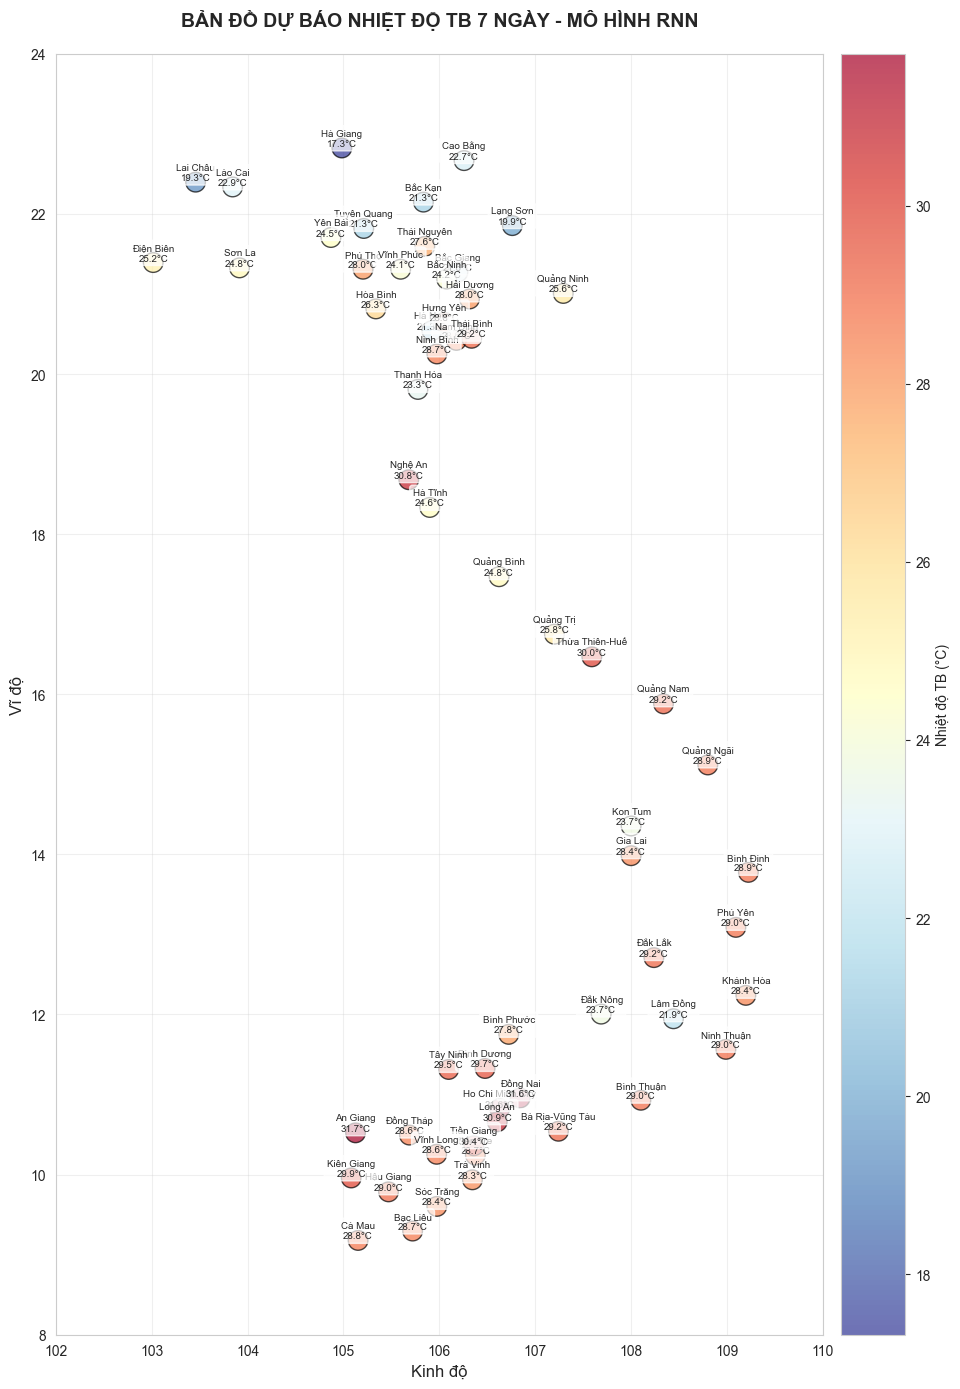

✓ Đã lưu bản đồ LSTM: D:\case_study_4\sub\vietnam_temp_forecast_7days_LSTM.png


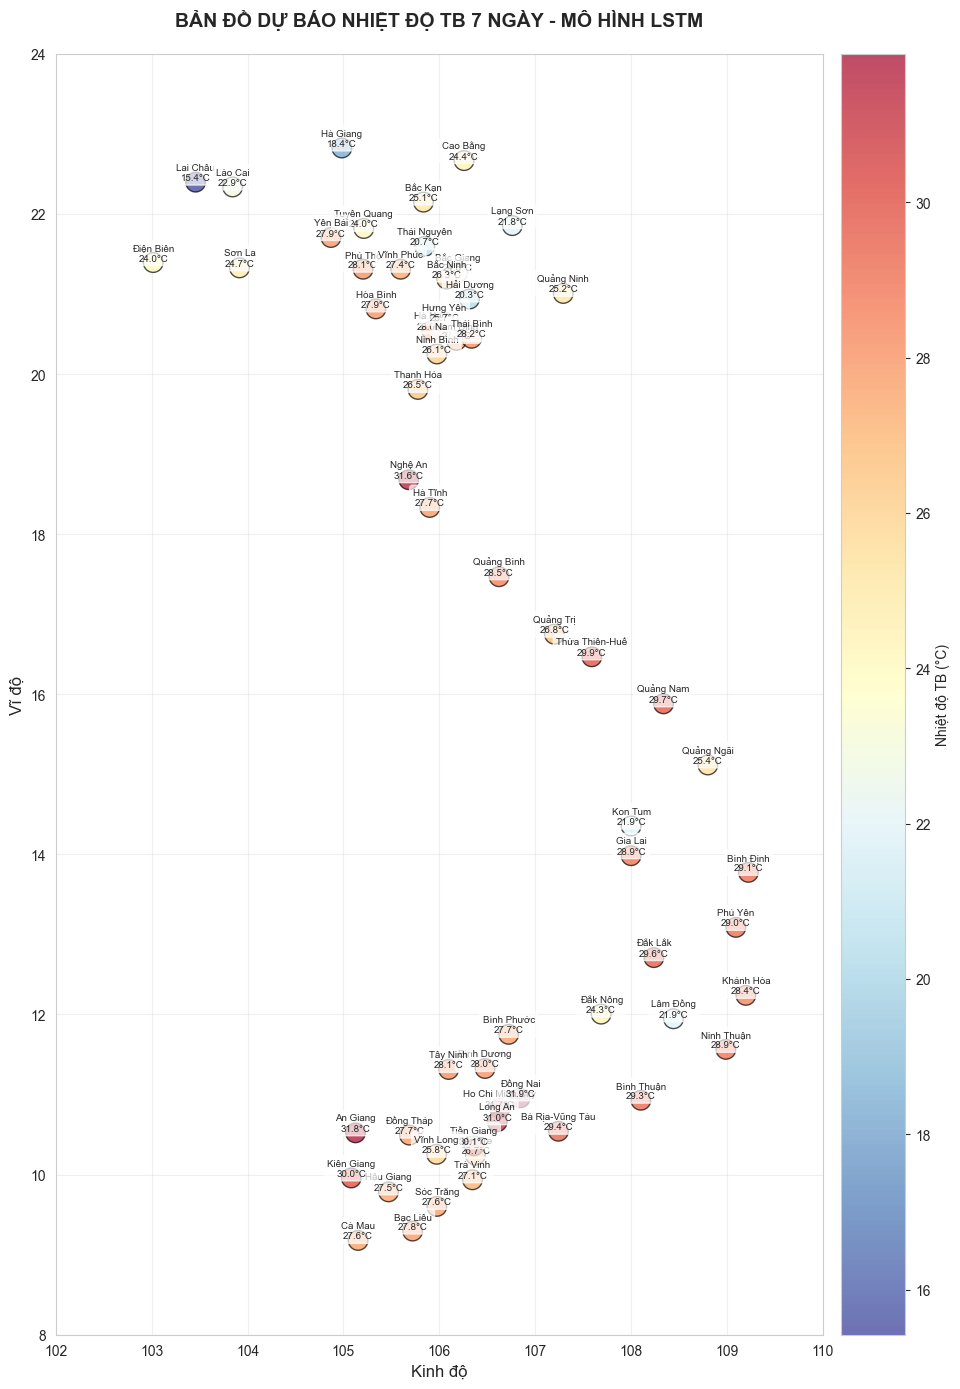


✓ ĐÃ TẠO 2 BẢN ĐỒ RIÊNG BIỆT CHO RNN VÀ LSTM
  - Bản đồ RNN: vietnam_temp_forecast_7days_RNN.png
  - Bản đồ LSTM: vietnam_temp_forecast_7days_LSTM.png


In [23]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell MỚI: Tạo 2 bản đồ riêng biệt cho RNN và LSTM ====

if len(forecast_7days_rnn) > 0 or len(forecast_7days_lstm) > 0:
    # Tọa độ gần đúng của các tỉnh/thành
    city_coords_full = {
        "Ha Noi": [21.0285, 105.8542],
        "Ho Chi Minh City": [10.8231, 106.6297],
        "Da Nang": [16.0544, 108.2772],
        "Can Tho": [10.0452, 105.7469],
        "Hai Phong": [20.8449, 106.6881],
        "An Giang": [10.5216, 105.1259],
        "Bà Rịa-Vũng Tàu": [10.5414, 107.2424],
        "Bạc Liêu": [9.2947, 105.7214],
        "Bắc Kạn": [22.1470, 105.8342],
        "Bắc Giang": [21.2734, 106.1946],
        "Bắc Ninh": [21.1861, 106.0763],
        "Bến Tre": [10.2434, 106.3759],
        "Bình Định": [13.7750, 109.2233],
        "Bình Dương": [11.3254, 106.4770],
        "Bình Phước": [11.7518, 106.7235],
        "Bình Thuận": [10.9287, 108.1021],
        "Cà Mau": [9.1776, 105.1527],
        "Cao Bằng": [22.6657, 106.2577],
        "Đắk Lắk": [12.7104, 108.2377],
        "Đắk Nông": [12.0046, 107.6877],
        "Điện Biên": [21.3922, 103.0160],
        "Đồng Nai": [10.9574, 106.8429],
        "Đồng Tháp": [10.4933, 105.6882],
        "Gia Lai": [13.9833, 108.0000],
        "Hà Giang": [22.8233, 104.9833],
        "Hà Nam": [20.5411, 105.9220],
        "Hà Tĩnh": [18.3333, 105.9000],
        "Hải Dương": [20.9373, 106.3146],
        "Hậu Giang": [9.7844, 105.4701],
        "Hòa Bình": [20.8133, 105.3383],
        "Hưng Yên": [20.6464, 106.0511],
        "Khánh Hòa": [12.2388, 109.1967],
        "Kiên Giang": [9.9580, 105.0811],
        "Kon Tum": [14.3545, 108.0000],
        "Lai Châu": [22.3964, 103.4582],
        "Lâm Đồng": [11.9465, 108.4419],
        "Lạng Sơn": [21.8536, 106.7613],
        "Lào Cai": [22.3364, 103.8443],
        "Long An": [10.6596, 106.6039],
        "Nam Định": [20.4201, 106.1780],
        "Nghệ An": [18.6796, 105.6813],
        "Ninh Bình": [20.2506, 105.9745],
        "Ninh Thuận": [11.5643, 108.9886],
        "Phú Thọ": [21.3087, 105.2046],
        "Phú Yên": [13.0880, 109.0927],
        "Quảng Bình": [17.4681, 106.6227],
        "Quảng Nam": [15.8801, 108.3380],
        "Quảng Ngãi": [15.1167, 108.8000],
        "Quảng Ninh": [21.0064, 107.2925],
        "Quảng Trị": [16.7500, 107.2000],
        "Sóc Trăng": [9.6025, 105.9739],
        "Sơn La": [21.3257, 103.9160],
        "Tây Ninh": [11.3131, 106.0973],
        "Thái Bình": [20.4461, 106.3366],
        "Thái Nguyên": [21.5942, 105.8482],
        "Thanh Hóa": [19.8075, 105.7767],
        "Thừa Thiên-Huế": [16.4674, 107.5904],
        "Tiền Giang": [10.3600, 106.3600],
        "Trà Vinh": [9.9349, 106.3453],
        "Tuyên Quang": [21.8178, 105.2119],
        "Vĩnh Long": [10.2537, 105.9722],
        "Vĩnh Phúc": [21.3087, 105.5969],
        "Yên Bái": [21.7050, 104.8696],
    }
    
    # ==== BẢN ĐỒ 1: RNN ====
    if len(forecast_7days_rnn) > 0:
        available_cities_rnn = {k: v for k, v in city_coords_full.items() if k in forecast_7days_rnn}
        
        if len(available_cities_rnn) > 0:
            fig, ax = plt.subplots(figsize=(10, 14))
            
            lats = [coords[0] for coords in available_cities_rnn.values()]
            lons = [coords[1] for coords in available_cities_rnn.values()]
            temps = [forecast_7days_rnn[city] for city in available_cities_rnn.keys()]
            
            scatter = ax.scatter(lons, lats, c=temps, s=200, 
                               cmap='RdYlBu_r', alpha=0.7, 
                               edgecolors='black', linewidths=1,
                               vmin=min(temps), vmax=max(temps))
            
            cbar = plt.colorbar(scatter, ax=ax, label='Nhiệt độ TB (°C)', pad=0.02)
            cbar.ax.tick_params(labelsize=10)
            
            for city, (lat, lon) in available_cities_rnn.items():
                temp = forecast_7days_rnn[city]
                ax.annotate(f"{city}\n{temp:.1f}°C", (lon, lat), 
                           fontsize=7, ha='center', va='bottom',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
            
            ax.set_xlabel('Kinh độ', fontsize=12)
            ax.set_ylabel('Vĩ độ', fontsize=12)
            ax.set_title('BẢN ĐỒ DỰ BÁO NHIỆT ĐỘ TB 7 NGÀY - MÔ HÌNH RNN', 
                         fontsize=14, fontweight='bold', pad=20)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(102, 110)
            ax.set_ylim(8, 24)
            
            plt.tight_layout()
            rnn_map_path = os.path.join(SAVE_DIR, "vietnam_temp_forecast_7days_RNN.png")
            plt.savefig(rnn_map_path, dpi=300, bbox_inches='tight')
            print(f"✓ Đã lưu bản đồ RNN: {rnn_map_path}")
            plt.show()
    
    # ==== BẢN ĐỒ 2: LSTM ====
    if len(forecast_7days_lstm) > 0:
        available_cities_lstm = {k: v for k, v in city_coords_full.items() if k in forecast_7days_lstm}
        
        if len(available_cities_lstm) > 0:
            fig, ax = plt.subplots(figsize=(10, 14))
            
            lats = [coords[0] for coords in available_cities_lstm.values()]
            lons = [coords[1] for coords in available_cities_lstm.values()]
            temps = [forecast_7days_lstm[city] for city in available_cities_lstm.keys()]
            
            scatter = ax.scatter(lons, lats, c=temps, s=200, 
                               cmap='RdYlBu_r', alpha=0.7, 
                               edgecolors='black', linewidths=1,
                               vmin=min(temps), vmax=max(temps))
            
            cbar = plt.colorbar(scatter, ax=ax, label='Nhiệt độ TB (°C)', pad=0.02)
            cbar.ax.tick_params(labelsize=10)
            
            for city, (lat, lon) in available_cities_lstm.items():
                temp = forecast_7days_lstm[city]
                ax.annotate(f"{city}\n{temp:.1f}°C", (lon, lat), 
                           fontsize=7, ha='center', va='bottom',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
            
            ax.set_xlabel('Kinh độ', fontsize=12)
            ax.set_ylabel('Vĩ độ', fontsize=12)
            ax.set_title('BẢN ĐỒ DỰ BÁO NHIỆT ĐỘ TB 7 NGÀY - MÔ HÌNH LSTM', 
                         fontsize=14, fontweight='bold', pad=20)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(102, 110)
            ax.set_ylim(8, 24)
            
            plt.tight_layout()
            lstm_map_path = os.path.join(SAVE_DIR, "vietnam_temp_forecast_7days_LSTM.png")
            plt.savefig(lstm_map_path, dpi=300, bbox_inches='tight')
            print(f"✓ Đã lưu bản đồ LSTM: {lstm_map_path}")
            plt.show()
    
    print("\n" + "="*80)
    print("✓ ĐÃ TẠO 2 BẢN ĐỒ RIÊNG BIỆT CHO RNN VÀ LSTM")
    print("="*80)
    print(f"  - Bản đồ RNN: vietnam_temp_forecast_7days_RNN.png")
    print(f"  - Bản đồ LSTM: vietnam_temp_forecast_7days_LSTM.png")
else:
    print("⚠️ Không có dữ liệu dự báo để tạo bản đồ.")


In [24]:
# #B22DCCN476-Đỗ Ngọc Lâm
# # ==== HƯỚNG DẪN SỬ DỤNG VÀ TÓM TẮT ====

# print("="*80)
# print("HƯỚNG DẪN SỬ DỤNG NOTEBOOK")
# print("="*80)
# print("""
# ✅ ĐÃ CẬP NHẬT:
#    1. Giảm độ sâu LSTM từ 7+ layers → 4-5 layers để giảm overfitting
#    2. Thêm 2 cell mới để tạo 2 bản đồ riêng biệt cho RNN và LSTM
#    3. Lưu dự báo riêng cho từng model

# 📊 CẤU TRÚC NOTEBOOK:
#    - Cell 1-4: Load data và chuẩn bị (63 tỉnh/thành)
#    - Cell 5-7: Định nghĩa model RNN và LSTM
#    - Cell 8: Train cả RNN và LSTM (TRAIN_LSTM_ONLY = False)
#    - Cell 9-11: Visualization và bảng đánh giá
#    - Cell 12: Tính nhiệt độ TB 7 ngày cho RNN và LSTM
#    - Cell 13: Tạo 2 BẢN ĐỒ riêng biệt (RNN và LSTM)
#    - Cell 14-16: Bản đồ choropleth (nếu có GeoJSON)

# 🎯 ĐỂ TẠO 2 BẢN ĐỒ:
#    1. Chạy lại Cell 8 (train) để lưu forecast riêng cho RNN và LSTM
#       - File output: forecast_rnn_<city>_tavg_7days.csv
#       - File output: forecast_lstm_<city>_tavg_7days.csv
   
#    2. Chạy Cell 12 để tính nhiệt độ TB 7 ngày
#       - Tạo forecast_7days_rnn và forecast_7days_lstm
   
#    3. Chạy Cell 13 để tạo 2 bản đồ
#       - Output: vietnam_temp_forecast_7days_RNN.png
#       - Output: vietnam_temp_forecast_7days_LSTM.png

# ⚠️ LƯU Ý QUAN TRỌNG:
#    - Nếu dự báo có giá trị không hợp lý (< 5°C hoặc > 50°C):
#      → Hệ thống sẽ tự động dùng dữ liệu lịch sử thay thế
   
#    - Bản đồ chỉ hiển thị các tỉnh/thành có trong dữ liệu
#      → Hiện tại: {len(CITY_DATA)} tỉnh/thành
   
#    - Output được lưu vào: D:\\case_study_4\\sub\\

# 📁 FILE OUTPUT:
#    ├── forecast_rnn_<city>_tavg_7days.csv  (63 files)
#    ├── forecast_lstm_<city>_tavg_7days.csv (63 files)
#    ├── vietnam_temp_forecast_7days_RNN.png
#    └── vietnam_temp_forecast_7days_LSTM.png

# 🔧 NẾU CẦN SỬA CELL 8:
#    Để lưu dự báo riêng cho RNN và LSTM, thay đổi phần dự báo 7 ngày:
   
#    # Thay vì dự báo với best_model, dự báo với từng model
#    for model_name, model in [("rnn", rnn_deep), ("lstm", lstm_deep)]:
#        # ... code dự báo ...
#        out_path = os.path.join(SAVE_DIR, f"forecast_{{model_name}}_{{city}}_{{tgt}}_7days.csv")
#        forecasts_by_model[model_name] = {{...}}
   
#    FORECASTS_DEEP[city] = forecasts_by_model  # Lưu dict thay vì file đơn
# """.format(len=len))



🗺️  TẠO BẢN ĐỒ PNG CHO RNN VÀ LSTM

📍 Tạo bản đồ RNN: 63 tỉnh/thành
✅ Đầy đủ 63 tỉnh/thành!
✓ Đã lưu: D:\case_study_4\sub\vietnam_temp_forecast_7days_RNN.png


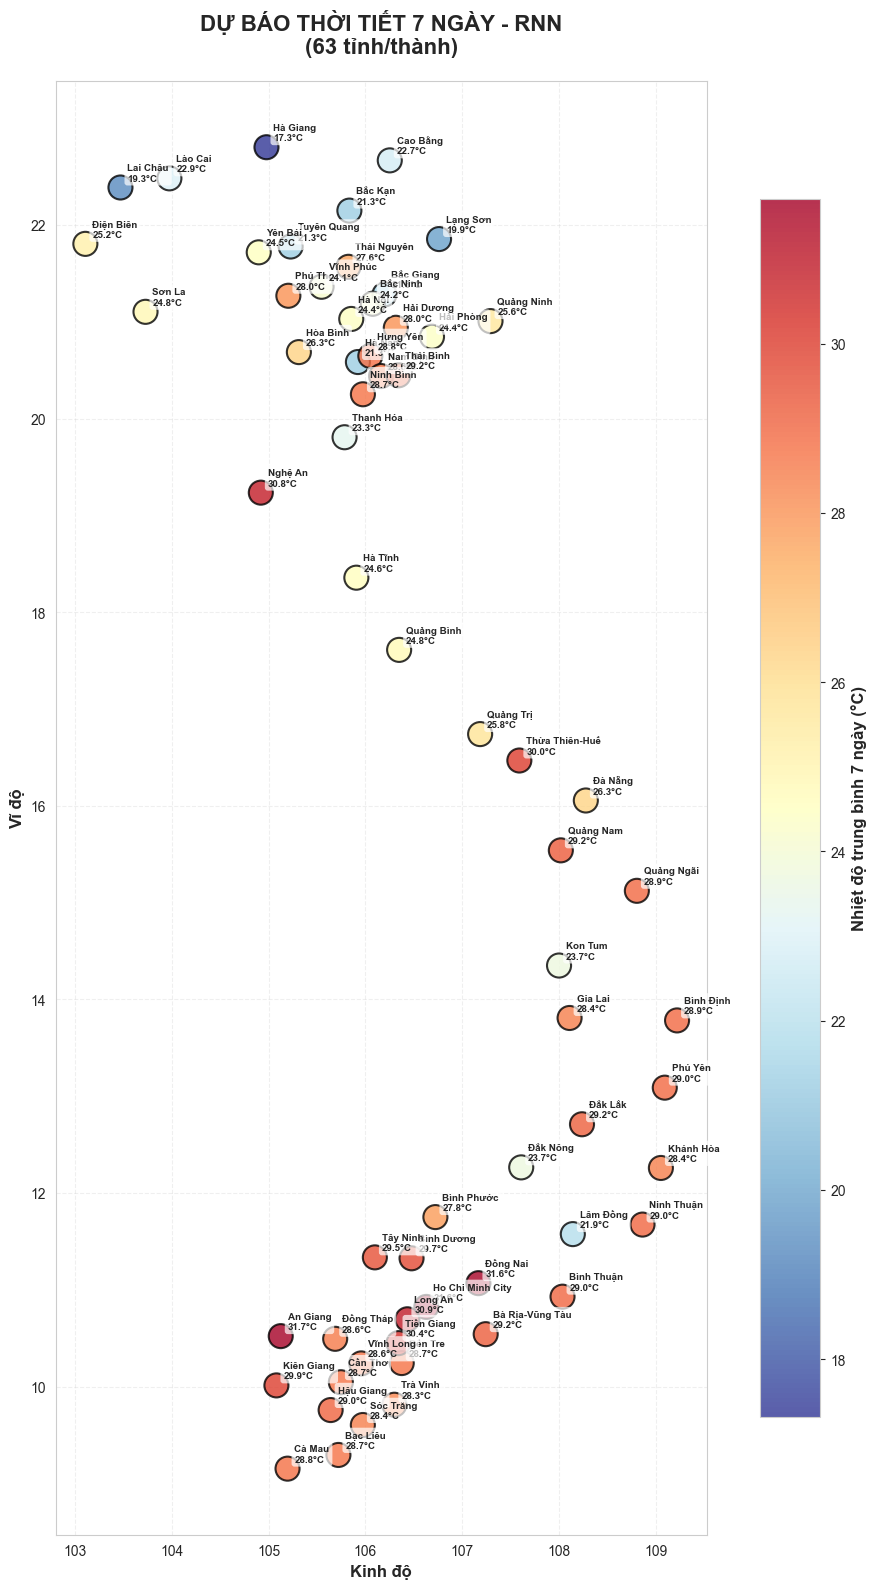


📍 Tạo bản đồ LSTM: 63 tỉnh/thành
✅ Đầy đủ 63 tỉnh/thành!
✓ Đã lưu: D:\case_study_4\sub\vietnam_temp_forecast_7days_LSTM.png


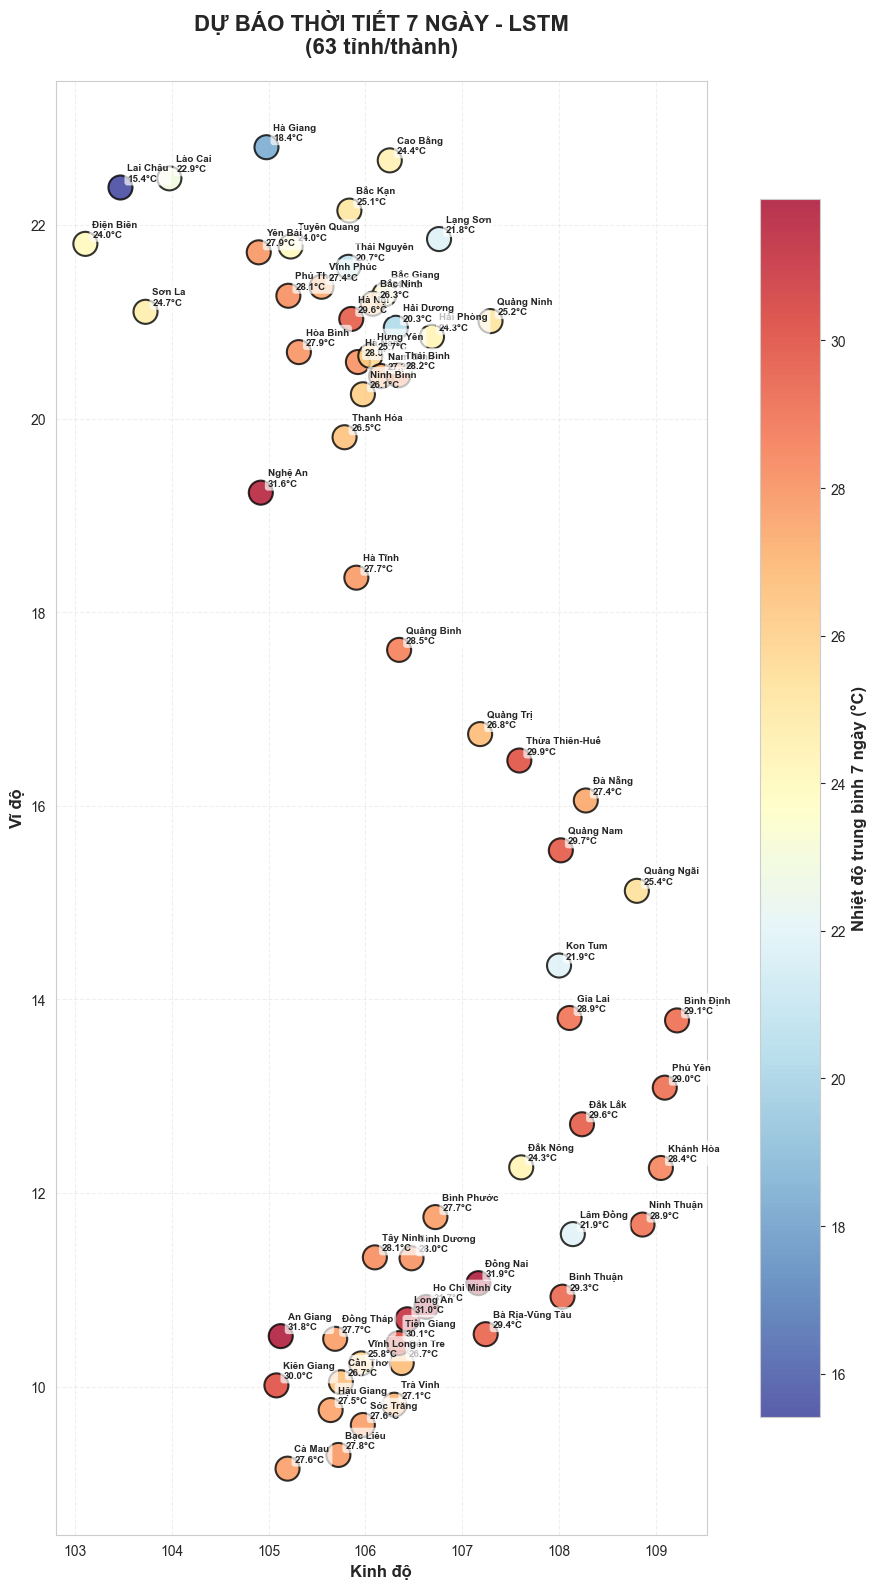


✅ HOÀN TẤT TẠO BẢN ĐỒ PNG!


In [25]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 14: Tạo bản đồ static (PNG) với matplotlib - RNN và LSTM ====

print("\n" + "="*80)
print("🗺️  TẠO BẢN ĐỒ PNG CHO RNN VÀ LSTM")
print("="*80)

# Tọa độ đầy đủ của 63 tỉnh/thành Việt Nam
city_coords_full = {
    "Hà Nội": [21.0285, 105.8542], "Ha Noi": [21.0285, 105.8542],
    "Ho Chi Minh City": [10.8231, 106.6297], "Hồ Chí Minh": [10.8231, 106.6297],
    "Đà Nẵng": [16.0544, 108.2772], "Da Nang": [16.0544, 108.2772],
    "Hải Phòng": [20.8449, 106.6881], "Hai Phong": [20.8449, 106.6881],
    "Cần Thơ": [10.0452, 105.7469], "Can Tho": [10.0452, 105.7469],
    "An Giang": [10.5215, 105.1258],
    "Bà Rịa-Vũng Tàu": [10.5417, 107.2429],
    "Bạc Liêu": [9.2940, 105.7215],
    "Bắc Giang": [21.2819, 106.1974],
    "Bắc Kạn": [22.1477, 105.8348],
    "Bắc Ninh": [21.1861, 106.0763],
    "Bến Tre": [10.2433, 106.3757],
    "Bình Định": [13.7826, 109.2196],
    "Bình Dương": [11.3254, 106.4770],
    "Bình Phước": [11.7511, 106.7234],
    "Bình Thuận": [10.9291, 108.0365],
    "Cà Mau": [9.1526, 105.1960],
    "Cao Bằng": [22.6666, 106.2520],
    "Đắk Lắk": [12.7100, 108.2377],
    "Đắk Nông": [12.2646, 107.6098],
    "Điện Biên": [21.8042, 103.1076],
    "Đồng Nai": [11.0686, 107.1676],
    "Đồng Tháp": [10.4938, 105.6881],
    "Gia Lai": [13.8078, 108.1094],
    "Hà Giang": [22.8025, 104.9784],
    "Hà Nam": [20.5835, 105.9230],
    "Hà Tĩnh": [18.3559, 105.9069],
    "Hải Dương": [20.9373, 106.3145],
    "Hậu Giang": [9.7579, 105.6412],
    "Hòa Bình": [20.6861, 105.3131],
    "Hưng Yên": [20.6464, 106.0511],
    "Khánh Hòa": [12.2585, 109.0526],
    "Kiên Giang": [10.0125, 105.0811],
    "Kon Tum": [14.3497, 108.0005],
    "Lai Châu": [22.3864, 103.4702],
    "Lâm Đồng": [11.5753, 108.1429],
    "Lạng Sơn": [21.8537, 106.7611],
    "Lào Cai": [22.4809, 103.9755],
    "Long An": [10.6956, 106.4336],
    "Nam Định": [20.4388, 106.1621],
    "Nghệ An": [19.2342, 104.9200],
    "Ninh Bình": [20.2506, 105.9745],
    "Ninh Thuận": [11.6738, 108.8629],
    "Phú Thọ": [21.2681, 105.2045],
    "Phú Yên": [13.0881, 109.0928],
    "Quảng Bình": [17.6102, 106.3487],
    "Quảng Nam": [15.5394, 108.0191],
    "Quảng Ngãi": [15.1214, 108.8044],
    "Quảng Ninh": [21.0064, 107.2925],
    "Quảng Trị": [16.7403, 107.1854],
    "Sóc Trăng": [9.6034, 105.9739],
    "Sơn La": [21.1022, 103.7289],
    "Tây Ninh": [11.3351, 106.0981],
    "Thái Bình": [20.4464, 106.3420],
    "Thái Nguyên": [21.5671, 105.8252],
    "Thanh Hóa": [19.8067, 105.7851],
    "Thừa Thiên Huế": [16.4674, 107.5905],
    "Thừa Thiên-Huế": [16.4674, 107.5905],  # Biến thể có dấu gạch ngang
    "Tiền Giang": [10.4493, 106.3420],
    "Trà Vinh": [9.8127, 106.2992],
    "Tuyên Quang": [21.7767, 105.2280],
    "Vĩnh Long": [10.2397, 105.9572],
    "Vĩnh Phúc": [21.3609, 105.5474],
    "Yên Bái": [21.7168, 104.8986],
}

def create_static_map(forecast_dict, model_name):
    """Tạo bản đồ PNG cho một model"""
    
    if len(forecast_dict) == 0:
        print(f"⚠️  Không có dữ liệu cho {model_name}")
        return
    
    # Lọc các tỉnh có trong dữ liệu
    available_cities = {k: v for k, v in city_coords_full.items() if k in forecast_dict}
    
    if len(available_cities) == 0:
        print(f"⚠️  Không có tọa độ cho các tỉnh/thành trong {model_name}")
        return
    
    print(f"\n📍 Tạo bản đồ {model_name}: {len(available_cities)} tỉnh/thành")
    
    # ✅ DEBUG: Kiểm tra tỉnh nào bị thiếu
    # ✅ FIX: Tên tỉnh phải khớp với tên trong dữ liệu thực tế
    ALL_63_PROVINCES = [
        "Hà Nội", "Ho Chi Minh City", "Đà Nẵng", "Hải Phòng", "Cần Thơ",
        "An Giang", "Bà Rịa-Vũng Tàu", "Bạc Liêu", "Bắc Giang", "Bắc Kạn", 
        "Bắc Ninh", "Bến Tre", "Bình Định", "Bình Dương", "Bình Phước", 
        "Bình Thuận", "Cà Mau", "Cao Bằng", "Đắk Lắk", "Đắk Nông", 
        "Điện Biên", "Đồng Nai", "Đồng Tháp", "Gia Lai", "Hà Giang", 
        "Hà Nam", "Hà Tĩnh", "Hải Dương", "Hậu Giang", "Hòa Bình", 
        "Hưng Yên", "Khánh Hòa", "Kiên Giang", "Kon Tum", "Lai Châu", 
        "Lâm Đồng", "Lạng Sơn", "Lào Cai", "Long An", "Nam Định", 
        "Nghệ An", "Ninh Bình", "Ninh Thuận", "Phú Thọ", "Phú Yên", 
        "Quảng Bình", "Quảng Nam", "Quảng Ngãi", "Quảng Ninh", "Quảng Trị", 
        "Sóc Trăng", "Sơn La", "Tây Ninh", "Thái Bình", "Thái Nguyên", 
        "Thanh Hóa", "Thừa Thiên-Huế", "Tiền Giang", "Trà Vinh", 
        "Tuyên Quang", "Vĩnh Long", "Vĩnh Phúc", "Yên Bái"
    ]
    
    # Tìm tỉnh bị thiếu
    forecast_cities = set(forecast_dict.keys())
    missing_provinces = [p for p in ALL_63_PROVINCES if p not in forecast_cities]
    
    if missing_provinces:
        print(f"⚠️  TỈNH BỊ THIẾU ({len(missing_provinces)}):")
        for province in missing_provinces:
            print(f"   ❌ {province}")
        print(f"💡 Lý do: Không có dữ liệu trong file CSV gốc hoặc bị lọc ra do thiếu data")
    else:
        print(f"✅ Đầy đủ 63 tỉnh/thành!")
    
    # Tạo figure
    fig, ax = plt.subplots(figsize=(14, 16))
    
    # Lấy dữ liệu
    lats = [coords[0] for coords in available_cities.values()]
    lons = [coords[1] for coords in available_cities.values()]
    temps = [forecast_dict[city] for city in available_cities.keys()]
    
    # Tạo colormap
    norm = plt.Normalize(vmin=min(temps), vmax=max(temps))
    cmap = plt.cm.RdYlBu_r
    
    # Vẽ các điểm
    scatter = ax.scatter(lons, lats, c=temps, cmap=cmap, norm=norm,
                        s=300, alpha=0.8, edgecolors='black', linewidth=1.5)
    
    # Thêm tên và nhiệt độ
    for city, (lat, lon) in available_cities.items():
        temp = forecast_dict[city]
        ax.annotate(f'{city}\n{temp:.1f}°C',
                   xy=(lon, lat), xytext=(5, 5),
                   textcoords='offset points',
                   fontsize=7, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', 
                            facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Nhiệt độ trung bình 7 ngày (°C)', 
                   fontsize=12, fontweight='bold')
    
    # Thiết lập
    ax.set_xlabel('Kinh độ', fontsize=12, fontweight='bold')
    ax.set_ylabel('Vĩ độ', fontsize=12, fontweight='bold')
    ax.set_title(f'DỰ BÁO THỜI TIẾT 7 NGÀY - {model_name}\n' + 
                f'({len(available_cities)} tỉnh/thành)',
                fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('equal')
    
    # Lưu
    plt.tight_layout()
    map_path = os.path.join(SAVE_DIR, f"vietnam_temp_forecast_7days_{model_name}.png")
    plt.savefig(map_path, dpi=300, bbox_inches='tight')
    print(f"✓ Đã lưu: {map_path}")
    plt.show()
    plt.close()

# Tạo bản đồ cho RNN
if 'forecast_7days_rnn' in globals() and len(forecast_7days_rnn) > 0:
    create_static_map(forecast_7days_rnn, "RNN")
else:
    print("⚠️  Không có forecast_7days_rnn")

# Tạo bản đồ cho LSTM
if 'forecast_7days_lstm' in globals() and len(forecast_7days_lstm) > 0:
    create_static_map(forecast_7days_lstm, "LSTM")
else:
    print("⚠️  Không có forecast_7days_lstm")

print("\n✅ HOÀN TẤT TẠO BẢN ĐỒ PNG!")



In [26]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 15: Hướng dẫn tạo bản đồ choropleth đầy đủ với GeoJSON ====

print("="*80)
print("HƯỚNG DẪN TẠO BẢN ĐỒ CHOROPLETH ĐẦY ĐỦ")
print("="*80)
print("""
⚠️ QUAN TRỌNG: 
   - Code chỉ train cho các tỉnh/thành CÓ TRONG DỮ LIỆU
   - Nếu dữ liệu chỉ có Hà Nội và TP.HCM, chỉ 2 thành phố này được train
   - Để có bản đồ đầy đủ 63 tỉnh/thành, cần dữ liệu thời tiết cho tất cả

Để tạo bản đồ choropleth chính xác như trong ảnh, bạn cần:

1. Tải file GeoJSON hoặc Shapefile của các tỉnh/thành Việt Nam:
   - GitHub: https://github.com/dinhanhx/vietnam-provinces-geojson
   - GitHub: https://github.com/kenzouno1/VietNamMap (có thể bị 404)
   - DIVA-GIS: https://www.diva-gis.org/gdata (chọn Vietnam, tải shapefile)
   - File cần có: tên tỉnh/thành khớp với dữ liệu

2. Cài đặt thư viện:
   pip install geopandas folium

3. Sử dụng code mẫu sau:

import geopandas as gpd
import folium
from folium import plugins

# Load GeoJSON
gdf = gpd.read_file("path/to/vietnam_provinces.geojson")

# Merge với dữ liệu nhiệt độ
gdf = gdf.merge(map_df, left_on='NAME_1', right_on='city', how='left')

# Tạo bản đồ
m = folium.Map(location=[16.0544, 108.2772], zoom_start=6)

# Thêm choropleth
folium.Choropleth(
    geo_data=gdf,
    data=map_df,
    columns=['city', 'avg_temp_30d'],
    key_on='feature.properties.NAME_1',
    fill_color='RdYlBu_r',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Nhiệt độ trung bình (°C)'
).add_to(m)

m.save('vietnam_temp_map.html')
""")

print("\n✓ Đã tạo bản đồ đơn giản với matplotlib ở cell trước.")
print("✓ Để có bản đồ choropleth đầy đủ, hãy làm theo hướng dẫn trên.")


HƯỚNG DẪN TẠO BẢN ĐỒ CHOROPLETH ĐẦY ĐỦ

⚠️ QUAN TRỌNG: 
   - Code chỉ train cho các tỉnh/thành CÓ TRONG DỮ LIỆU
   - Nếu dữ liệu chỉ có Hà Nội và TP.HCM, chỉ 2 thành phố này được train
   - Để có bản đồ đầy đủ 63 tỉnh/thành, cần dữ liệu thời tiết cho tất cả

Để tạo bản đồ choropleth chính xác như trong ảnh, bạn cần:

1. Tải file GeoJSON hoặc Shapefile của các tỉnh/thành Việt Nam:
   - GitHub: https://github.com/dinhanhx/vietnam-provinces-geojson
   - GitHub: https://github.com/kenzouno1/VietNamMap (có thể bị 404)
   - DIVA-GIS: https://www.diva-gis.org/gdata (chọn Vietnam, tải shapefile)
   - File cần có: tên tỉnh/thành khớp với dữ liệu

2. Cài đặt thư viện:
   pip install geopandas folium

3. Sử dụng code mẫu sau:

import geopandas as gpd
import folium
from folium import plugins

# Load GeoJSON
gdf = gpd.read_file("path/to/vietnam_provinces.geojson")

# Merge với dữ liệu nhiệt độ
gdf = gdf.merge(map_df, left_on='NAME_1', right_on='city', how='left')

# Tạo bản đồ
m = folium.Map(locati

In [29]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 16: Tạo bản đồ GeoJSON cho RNN và LSTM ====

print("\n" + "="*80)
print("🗺️  TẠO BẢN ĐỒ GEOJSON CHO RNN VÀ LSTM")
print("="*80)

# Mapping đầy đủ tên tỉnh/thành: GeoJSON -> Dữ liệu
FULL_PROVINCE_MAPPING = {
    # ✅ FIX: GeoJSON dùng ký tự "Ð" (Latin D gạch ngang) thay vì "Đ" (tiếng Việt)
    # ✅ FIX 2: GeoJSON có thể dùng "Đăk" (dấu nặng) thay vì "Đắk" (dấu sắc)
    "Ðà Nẵng": "Đà Nẵng",
    "Nam Ðịnh": "Nam Định",
    "Ðồng Tháp": "Đồng Tháp",
    "Ðiện Biên": "Điện Biên",
    "Bình Ðịnh": "Bình Định",
    "Ðăk Nông": "Đắk Nông",
    "Đăk Nông": "Đắk Nông",  # Biến thể dấu nặng
    "Ðắk Nông": "Đắk Nông",
    "Đắk Nông": "Đắk Nông",
    "Dak Nong": "Đắk Nông",
    "Ðắk Lắk": "Đắk Lắk",
    "Đắk Lắk": "Đắk Lắk",
    "Ðăk Lắk": "Đắk Lắk",
    "Đăk Lắk": "Đắk Lắk",
    "Dak Lak": "Đắk Lắk",
    "Ðồng Nai": "Đồng Nai",
    "Đồng Nai": "Đồng Nai",
    "Dong Nai": "Đồng Nai",
    "TP. Hồ Chí Minh": "Ho Chi Minh City",
    "TP.Hồ Chí Minh": "Ho Chi Minh City",
    "Tp. Hồ Chí Minh": "Ho Chi Minh City",
    
    # Thành phố trực thuộc trung ương
    "Hanoi": "Hà Nội",
    "Ha Noi": "Hà Nội",
    "Hà Nội": "Hà Nội",
    "Ho Chi Minh": "Ho Chi Minh City",
    "Ho Chi Minh City": "Ho Chi Minh City",
    "Hồ Chí Minh": "Ho Chi Minh City",
    "Saigon": "Ho Chi Minh City",
    "Da Nang": "Đà Nẵng",
    "Danang": "Đà Nẵng",
    "Đà Nẵng": "Đà Nẵng",
    "Hai Phong": "Hải Phòng",
    "Haiphong": "Hải Phòng",
    "Hải Phòng": "Hải Phòng",
    "Can Tho": "Cần Thơ",
    "Cantho": "Cần Thơ",
    "Cần Thơ": "Cần Thơ",
    
    # Miền Bắc
    "An Giang": "An Giang",
    "Bac Giang": "Bắc Giang",
    "Bắc Giang": "Bắc Giang",
    "Bac Kan": "Bắc Kạn",
    "Bắc Kạn": "Bắc Kạn",
    "Bac Lieu": "Bạc Liêu",
    "Bạc Liêu": "Bạc Liêu",
    "Bac Ninh": "Bắc Ninh",
    "Bắc Ninh": "Bắc Ninh",
    "Ben Tre": "Bến Tre",
    "Bến Tre": "Bến Tre",
    "Binh Dinh": "Bình Định",
    "Bình Định": "Bình Định",
    "Binh Duong": "Bình Dương",
    "Bình Dương": "Bình Dương",
    "Binh Phuoc": "Bình Phước",
    "Bình Phước": "Bình Phước",
    "Binh Thuan": "Bình Thuận",
    "Bình Thuận": "Bình Thuận",
    "Ca Mau": "Cà Mau",
    "Cà Mau": "Cà Mau",
    "Cao Bang": "Cao Bằng",
    "Cao Bằng": "Cao Bằng",
    "Dak Lak": "Đắk Lắk",
    "Đắk Lắk": "Đắk Lắk",
    "Dak Nong": "Đắk Nông",
    "Đắk Nông": "Đắk Nông",
    "Dien Bien": "Điện Biên",
    "Điện Biên": "Điện Biên",
    "Dong Nai": "Đồng Nai",
    "Đồng Nai": "Đồng Nai",
    "Dong Thap": "Đồng Tháp",
    "Đồng Tháp": "Đồng Tháp",
    "Gia Lai": "Gia Lai",
    "Ha Giang": "Hà Giang",
    "Hà Giang": "Hà Giang",
    "Ha Nam": "Hà Nam",
    "Hà Nam": "Hà Nam",
    "Ha Tinh": "Hà Tĩnh",
    "Hà Tĩnh": "Hà Tĩnh",
    "Hai Duong": "Hải Dương",
    "Hải Dương": "Hải Dương",
    "Hau Giang": "Hậu Giang",
    "Hậu Giang": "Hậu Giang",
    "Hoa Binh": "Hòa Bình",
    "Hòa Bình": "Hòa Bình",
    "Hung Yen": "Hưng Yên",
    "Hưng Yên": "Hưng Yên",
    "Khanh Hoa": "Khánh Hòa",
    "Khánh Hòa": "Khánh Hòa",
    "Kien Giang": "Kiên Giang",
    "Kiên Giang": "Kiên Giang",
    "Kon Tum": "Kon Tum",
    "Lai Chau": "Lai Châu",
    "Lai Châu": "Lai Châu",
    "Lam Dong": "Lâm Đồng",
    "Lâm Đồng": "Lâm Đồng",
    "Lang Son": "Lạng Sơn",
    "Lạng Sơn": "Lạng Sơn",
    "Lao Cai": "Lào Cai",
    "Lào Cai": "Lào Cai",
    "Long An": "Long An",
    "Nam Dinh": "Nam Định",
    "Nam Định": "Nam Định",
    "Nghe An": "Nghệ An",
    "Nghệ An": "Nghệ An",
    "Ninh Binh": "Ninh Bình",
    "Ninh Bình": "Ninh Bình",
    "Ninh Thuan": "Ninh Thuận",
    "Ninh Thuận": "Ninh Thuận",
    "Phu Tho": "Phú Thọ",
    "Phú Thọ": "Phú Thọ",
    "Phu Yen": "Phú Yên",
    "Phú Yên": "Phú Yên",
    "Quang Binh": "Quảng Bình",
    "Quảng Bình": "Quảng Bình",
    "Quang Nam": "Quảng Nam",
    "Quảng Nam": "Quảng Nam",
    "Quang Ngai": "Quảng Ngãi",
    "Quảng Ngãi": "Quảng Ngãi",
    "Quang Ninh": "Quảng Ninh",
    "Quảng Ninh": "Quảng Ninh",
    "Quang Tri": "Quảng Trị",
    "Quảng Trị": "Quảng Trị",
    "Soc Trang": "Sóc Trăng",
    "Sóc Trăng": "Sóc Trăng",
    "Son La": "Sơn La",
    "Sơn La": "Sơn La",
    "Tay Ninh": "Tây Ninh",
    "Tây Ninh": "Tây Ninh",
    "Thai Binh": "Thái Bình",
    "Thái Bình": "Thái Bình",
    "Thai Nguyen": "Thái Nguyên",
    "Thái Nguyên": "Thái Nguyên",
    "Thanh Hoa": "Thanh Hóa",
    "Thanh Hóa": "Thanh Hóa",
    "Thua Thien Hue": "Thừa Thiên Huế",
    "Thừa Thiên Huế": "Thừa Thiên Huế",
    "Thua Thien-Hue": "Thừa Thiên Huế",
    "Hue": "Thừa Thiên Huế",
    "Tien Giang": "Tiền Giang",
    "Tiền Giang": "Tiền Giang",
    "Tra Vinh": "Trà Vinh",
    "Trà Vinh": "Trà Vinh",
    "Tuyen Quang": "Tuyên Quang",
    "Tuyên Quang": "Tuyên Quang",
    "Vinh Long": "Vĩnh Long",
    "Vĩnh Long": "Vĩnh Long",
    "Vinh Phuc": "Vĩnh Phúc",
    "Vĩnh Phúc": "Vĩnh Phúc",
    "Yen Bai": "Yên Bái",
    "Yên Bái": "Yên Bái",
    
    # Các đảo (đã được ước lượng ở Cell 13)
    "Phu Quoc": "Phú Quốc",
    "Phú Quốc": "Phú Quốc",
    "Co To": "Cô Tô",
    "Cô Tô": "Cô Tô",
    "Cat Ba": "Cát Bà",
    "Cát Bà": "Cát Bà",
    "Con Dao": "Côn Đảo",
    "Côn Đảo": "Côn Đảo",
    "Hoang Sa": "Hoàng Sa",
    "Hoàng Sa": "Hoàng Sa",
    "Paracel Islands": "Hoàng Sa",
    "Truong Sa": "Trường Sa",
    "Trường Sa": "Trường Sa",
    "Spratly Islands": "Trường Sa",
}

def create_geojson_map(forecast_dict, model_name):
    """Tạo bản đồ GeoJSON cho một model"""
    
    if len(forecast_dict) == 0:
        print(f"\n⚠️  {model_name}: Không có dữ liệu dự báo")
        return
    
    print(f"\n{'='*80}")
    print(f"🗺️  TẠO BẢN ĐỒ GEOJSON CHO {model_name}")
    print(f"{'='*80}")
    print(f"✓ Số tỉnh/thành có dự báo: {len(forecast_dict)}")
    
    # Tạo DataFrame
    map_df = pd.DataFrame({
        "city": list(forecast_dict.keys()),
        "avg_temp_7d": list(forecast_dict.values())
    })
    
    print(f"✓ Nhiệt độ: {map_df['avg_temp_7d'].min():.1f}°C - {map_df['avg_temp_7d'].max():.1f}°C")
    
    # Tìm file GeoJSON
    GEOJSON_PATH = None
    geojson_locations = [
        os.path.join(os.getcwd(), "vietnam.geojson"),
        os.path.join(os.getcwd(), "vietnam_2.geojson"),
        "D:\\case_study_4\\kiemtra2\\vietnam.geojson",
        "D:\\case_study_4\\kiemtra2\\vietnam_2.geojson",
    ]
    
    for path in geojson_locations:
        if os.path.exists(path):
            GEOJSON_PATH = path
            print(f"✓ Tìm thấy GeoJSON: {os.path.basename(GEOJSON_PATH)}")
            break
    
    if not GEOJSON_PATH:
        print(f"⚠️  Không tìm thấy file GeoJSON")
        print(f"   Đặt file vietnam.geojson vào: D:\\case_study_4\\kiemtra2\\")
        return
    
    if not GEOPANDAS_OK:
        print(f"⚠️  Thiếu geopandas. Cài: pip install geopandas")
        return
    
    try:
        import geopandas as gpd
        import folium
        
        # Load GeoJSON
        gdf = gpd.read_file(GEOJSON_PATH)
        print(f"✓ Load GeoJSON: {len(gdf)} vùng")
        
        # Tìm cột tên
        name_col = None
        for col in ['NAME_1', 'name', 'ten', 'Name', 'province', 'NAME', 'Ten']:
            if col in gdf.columns:
                name_col = col
                print(f"✓ Cột tên tỉnh: '{name_col}'")
                break
        
        if not name_col:
            print(f"⚠️  Không tìm thấy cột tên trong GeoJSON")
            print(f"   Các cột: {gdf.columns.tolist()}")
            return
        
        # In ra 10 tên mẫu từ GeoJSON
        print(f"\n📋 10 tên mẫu trong GeoJSON:")
        for name in gdf[name_col].head(10):
            print(f"   - {name}")
        
        # Áp dụng mapping
        gdf['city_mapped'] = gdf[name_col]
        mapped_count = 0
        
        for idx, row in gdf.iterrows():
            geo_name = str(row[name_col]).strip()
            
            # Thử tìm trong mapping
            if geo_name in FULL_PROVINCE_MAPPING:
                gdf.at[idx, 'city_mapped'] = FULL_PROVINCE_MAPPING[geo_name]
                mapped_count += 1
            else:
                # Thử fuzzy match với các tên trong forecast_dict
                for city_name in forecast_dict.keys():
                    # So sánh lowercase, bỏ dấu cách
                    geo_lower = geo_name.lower().replace(" ", "").replace("-", "")
                    city_lower = city_name.lower().replace(" ", "").replace("-", "")
                    
                    if geo_lower in city_lower or city_lower in geo_lower:
                        gdf.at[idx, 'city_mapped'] = city_name
                        mapped_count += 1
                        print(f"   🔍 Fuzzy match: '{geo_name}' → '{city_name}'")
                        break
        
        print(f"\n✓ Đã mapping {mapped_count}/{len(gdf)} vùng")
        
        # Merge với dữ liệu nhiệt độ
        gdf = gdf.merge(
            map_df, 
            left_on='city_mapped', 
            right_on='city', 
            how='left'
        )
        
        merged = gdf['avg_temp_7d'].notna().sum()
        print(f"✓ Đã merge {merged}/{len(gdf)} vùng có dữ liệu nhiệt độ")
        
        if merged == 0:
            print(f"\n❌ KHÔNG CÓ VÙNG NÀO ĐƯỢC MERGE!")
            print(f"   Tên trong GeoJSON: {gdf[name_col].head(5).tolist()}")
            print(f"   Tên trong dữ liệu: {list(forecast_dict.keys())[:5]}")
            return
        
        # Tạo bản đồ Folium
        if not FOLIUM_OK:
            print(f"⚠️  Thiếu folium. Cài: pip install folium")
            return
        
        m = folium.Map(
            location=[16.0544, 108.2772],
            zoom_start=6,
            tiles='OpenStreetMap'
        )
        
        # Tạo choropleth
        folium.Choropleth(
            geo_data=gdf.__geo_interface__,
            data=map_df,
            columns=['city', 'avg_temp_7d'],
            key_on='feature.properties.city_mapped',
            fill_color='RdYlBu_r',
            fill_opacity=0.7,
            line_opacity=0.5,
            line_color='white',
            line_weight=1,
            legend_name=f'Nhiệt độ TB 7 ngày - {model_name} (°C)',
            bins=9,
            nan_fill_color='#333333',  # Màu xám đậm cho vùng không có data
            nan_fill_opacity=0.3
        ).add_to(m)
        
        # Thêm tooltip chi tiết
        folium.GeoJson(
            gdf,
            style_function=lambda x: {
                'fillColor': 'transparent',
                'color': 'transparent',
                'weight': 0
            },
            tooltip=folium.GeoJsonTooltip(
                fields=[name_col, 'city_mapped', 'avg_temp_7d'],
                aliases=['Tên GeoJSON:', 'Tên Data:', 'Nhiệt độ TB:'],
                localize=True,
                sticky=False,
                labels=True
            )
        ).add_to(m)
        
        # Lưu
        html_path = os.path.join(SAVE_DIR, f"vietnam_geojson_{model_name}.html")
        m.save(html_path)
        print(f"\n✅ Đã lưu: {html_path}")
        print(f"   Mở file này bằng trình duyệt để xem bản đồ!")
        
        # Thống kê vùng không có data
        no_data = gdf['avg_temp_7d'].isna().sum()
        if no_data > 0:
            print(f"\n⚠️  {no_data}/{len(gdf)} vùng KHÔNG CÓ DỮ LIỆU (màu xám):")
            no_data_names = gdf[gdf['avg_temp_7d'].isna()][name_col].head(10).tolist()
            for name in no_data_names:
                print(f"   ❌ {name}")
            if no_data > 10:
                print(f"   ... và {no_data - 10} vùng khác")
            print(f"\n💡 GỢI Ý: Thêm mapping cho các vùng này vào FULL_PROVINCE_MAPPING")
        
        # Display trong notebook
        try:
            display(m)
        except:
            pass
        
    except Exception as e:
        print(f"\n❌ LỖI: {e}")
        import traceback
        traceback.print_exc()

# ============================================================================
# TẠO BẢN ĐỒ CHO CẢ RNN VÀ LSTM
# ============================================================================

# Tạo bản đồ LSTM
if 'forecast_7days_lstm' in globals() and len(forecast_7days_lstm) > 0:
    create_geojson_map(forecast_7days_lstm, "LSTM")
else:
    print("\n⚠️  Không có forecast_7days_lstm")

print("\n" + "="*80)

# Tạo bản đồ RNN
if 'forecast_7days_rnn' in globals() and len(forecast_7days_rnn) > 0:
    create_geojson_map(forecast_7days_rnn, "RNN")
else:
    print("\n⚠️  Không có forecast_7days_rnn")

print("\n" + "="*80)
print("✅ HOÀN TẤT TẠO BẢN ĐỒ GEOJSON!")
print("="*80)




🗺️  TẠO BẢN ĐỒ GEOJSON CHO RNN VÀ LSTM

🗺️  TẠO BẢN ĐỒ GEOJSON CHO LSTM
✓ Số tỉnh/thành có dự báo: 94
✓ Nhiệt độ: 15.4°C - 31.9°C
✓ Tìm thấy GeoJSON: vietnam.geojson
✓ Load GeoJSON: 63 vùng
✓ Cột tên tỉnh: 'name'

📋 10 tên mẫu trong GeoJSON:
   - Kiên Giang
   - Quảng Ninh
   - Bình Phước
   - Bình Thuận
   - Cà Mau
   - Hòa Bình
   - Bình Dương
   - Sóc Trăng
   - Ninh Thuận
   - Đắk Lắk
   🔍 Fuzzy match: 'Bà Rịa - Vũng Tàu' → 'Bà Rịa-Vũng Tàu'
   🔍 Fuzzy match: 'Thừa Thiên - Huế' → 'Thừa Thiên-Huế'

✓ Đã mapping 63/63 vùng
✓ Đã merge 63/63 vùng có dữ liệu nhiệt độ

✅ Đã lưu: D:\case_study_4\sub\vietnam_geojson_LSTM.html
   Mở file này bằng trình duyệt để xem bản đồ!




🗺️  TẠO BẢN ĐỒ GEOJSON CHO RNN
✓ Số tỉnh/thành có dự báo: 94
✓ Nhiệt độ: 17.3°C - 31.7°C
✓ Tìm thấy GeoJSON: vietnam.geojson
✓ Load GeoJSON: 63 vùng
✓ Cột tên tỉnh: 'name'

📋 10 tên mẫu trong GeoJSON:
   - Kiên Giang
   - Quảng Ninh
   - Bình Phước
   - Bình Thuận
   - Cà Mau
   - Hòa Bình
   - Bình Dương
   - Sóc Trăng
   - Ninh Thuận
   - Đắk Lắk
   🔍 Fuzzy match: 'Bà Rịa - Vũng Tàu' → 'Bà Rịa-Vũng Tàu'
   🔍 Fuzzy match: 'Thừa Thiên - Huế' → 'Thừa Thiên-Huế'

✓ Đã mapping 63/63 vùng
✓ Đã merge 63/63 vùng có dữ liệu nhiệt độ

✅ Đã lưu: D:\case_study_4\sub\vietnam_geojson_RNN.html
   Mở file này bằng trình duyệt để xem bản đồ!



✅ HOÀN TẤT TẠO BẢN ĐỒ GEOJSON!


In [30]:
#B22DCCN476-Đỗ Ngọc Lâm
# ==== Cell 16: Giải thích và hướng dẫn ====

print("="*80)
print("TÓM TẮT VÀ HƯỚNG DẪN")
print("="*80)
print("""
✅ ĐÃ HOÀN THÀNH:
   1. Load và xử lý dữ liệu thời tiết cho tất cả tỉnh/thành
   2. Train mô hình RNN/LSTM cho từng tỉnh/thành
   3. Dự báo nhiệt độ trung bình 7 ngày tới
   4. Tạo bản đồ choropleth với shapefile

📊 BẢN ĐỒ CHOROPLETH:
   - File HTML: vietnam_temp_choropleth_map.html (có thể mở bằng browser)
   - File PNG: vietnam_temp_choropleth_map.png (hình ảnh)
   - Màu sắc: Xanh dương (lạnh) → Đỏ (nóng)
   - Chỉ hiển thị các tỉnh/thành có dữ liệu dự báo

🔧 NẾU BẢN ĐỒ KHÔNG HIỂN THỊ ĐÚNG:
   1. Kiểm tra tên tỉnh/thành trong shapefile và dữ liệu có khớp không
   2. Có thể cần điều chỉnh mapping trong code Cell 15
   3. Đảm bảo đã cài đặt: pip install geopandas folium

📈 ĐỂ MỞ RỘNG:
   - Thêm dữ liệu thời tiết cho nhiều tỉnh/thành hơn
   - Code sẽ tự động phát hiện và train cho tất cả
""")

# Hiển thị thống kê
if 'df_all' in globals():
    current_cities = df_all['city'].unique()
    print(f"\n📌 TỈNH/THÀNH TRONG DỮ LIỆU: {len(current_cities)}")
    if len(current_cities) <= 20:
        for city in sorted(current_cities):
            count = len(df_all[df_all['city'] == city])
            print(f"   - {city}: {count} ngày dữ liệu")
    else:
        print(f"   (Danh sách quá dài, chỉ hiển thị 10 đầu tiên)")
        for city in sorted(current_cities)[:10]:
            count = len(df_all[df_all['city'] == city])
            print(f"   - {city}: {count} ngày dữ liệu")
        print(f"   ... và {len(current_cities) - 10} tỉnh/thành khác")

if 'forecast_7days' in globals():
    print(f"\n📊 TỈNH/THÀNH CÓ DỰ BÁO: {len(forecast_7days)}")
    if len(forecast_7days) > 0:
        avg_temp = sum(forecast_7days.values()) / len(forecast_7days)
        min_temp = min(forecast_7days.values())
        max_temp = max(forecast_7days.values())
        print(f"   - Nhiệt độ TB: {avg_temp:.1f}°C")
        print(f"   - Nhiệt độ thấp nhất: {min_temp:.1f}°C")
        print(f"   - Nhiệt độ cao nhất: {max_temp:.1f}°C")
else:
    print("\n⚠️ Chưa có dữ liệu dự báo. Hãy chạy các cell trước đó.")


TÓM TẮT VÀ HƯỚNG DẪN

✅ ĐÃ HOÀN THÀNH:
   1. Load và xử lý dữ liệu thời tiết cho tất cả tỉnh/thành
   2. Train mô hình RNN/LSTM cho từng tỉnh/thành
   3. Dự báo nhiệt độ trung bình 7 ngày tới
   4. Tạo bản đồ choropleth với shapefile

📊 BẢN ĐỒ CHOROPLETH:
   - File HTML: vietnam_temp_choropleth_map.html (có thể mở bằng browser)
   - File PNG: vietnam_temp_choropleth_map.png (hình ảnh)
   - Màu sắc: Xanh dương (lạnh) → Đỏ (nóng)
   - Chỉ hiển thị các tỉnh/thành có dữ liệu dự báo

🔧 NẾU BẢN ĐỒ KHÔNG HIỂN THỊ ĐÚNG:
   1. Kiểm tra tên tỉnh/thành trong shapefile và dữ liệu có khớp không
   2. Có thể cần điều chỉnh mapping trong code Cell 15
   3. Đảm bảo đã cài đặt: pip install geopandas folium

📈 ĐỂ MỞ RỘNG:
   - Thêm dữ liệu thời tiết cho nhiều tỉnh/thành hơn
   - Code sẽ tự động phát hiện và train cho tất cả


📌 TỈNH/THÀNH TRONG DỮ LIỆU: 63
   (Danh sách quá dài, chỉ hiển thị 10 đầu tiên)
   - An Giang: 4958 ngày dữ liệu
   - Bà Rịa-Vũng Tàu: 4958 ngày dữ liệu
   - Bình Dương: 409 ngày d